# What this notebook is doing (Playground 1)

This notebook is another working notebook, but this one is mostly centered on AR-event precipitation comparisons for Skagit.
I used it to test dataset availability, compare event windows across sources, and keep building up the event-comparison workflow before splitting cleaner versions into other notebooks.

A lot of the cells are different versions of the same idea: compare cumulative event precipitation across datasets like PRISM, ORNL/Daymet, UCLA WRF, PNNL, HRRR, CONUS404, and sometimes SNOTEL.
Some cells are just quick checks for whether the needed files exist for each event, while later cells add verification steps, plotting, and MAE against PRISM.

So this is not really a single final notebook from top to bottom.
It is more like a development notebook for the AR-event comparison workflow, with older and newer versions kept together.


In [ ]:
from pathlib import Path
import re
import xarray as xr
import pandas as pd

# ---- Event windows  ----
events = {
    1990: ("1990-11-03", "1990-11-17"),
    1995: ("1995-11-25", "1995-12-10"),
    2003: ("2003-10-17", "2003-10-31"),
    2006: ("2006-11-02", "2006-11-11"),
    2011: ("2011-01-01", "2011-02-01"),
}

# ---- Base paths (update PRISM to prism_nc, add optional event_zarr folder) ----
BASE = Path("/data0/balaji24/data")
P_ORNL_DIR   = BASE / "ornl_nc"

#  Downloaded PRISM event-window Zarrs here:
P_PRISM_DIR  = BASE / "prism_nc"

# (Optional but recommended) if you later consolidate all event-window zarrs:
P_EVENT_DIR  = BASE / "atmospheric_rivers"   # safe even if it doesn't exist

P_HRRR_DIR   = BASE / "weather_data"          # monthly zarrs YYYY-MM_HRRR_data.zarr
P_WRF_DIR    = BASE / "ucla_wrf_outputs"      # yearly zarrs
PNNL_HIST    = BASE / "PNNL" / "historical"   # hourly netcdfs per year
P_CONUS_DERIVED = BASE / "derived" / "conus404_skagit_precip_daily.zarr"

def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def ds_time_range_ok(ds: xr.Dataset, start: str, end: str) -> bool:
    if "time" not in ds.coords and "time" not in ds.dims:
        return False
    t = pd.to_datetime(ds["time"].values)
    # robust to unsorted time
    t0 = t.min()
    t1 = t.max()
    return (t0 <= pd.to_datetime(start)) and (t1 >= pd.to_datetime(end))

def any_zarr_covers(folder: Path, pattern: str, start: str, end: str):
    """
    Looks for zarr stores under `folder` matching `pattern` and checks
    if any one covers [start, end] in time.
    """
    if not folder.exists():
        return False, "folder missing"
    paths = sorted(folder.glob(pattern))
    if not paths:
        return False, "no files"
    for p in paths:
        try:
            ds = safe_open_zarr(p)
            ok = ds_time_range_ok(ds, start, end)
            ds.close()
            if ok:
                return True, p.name
        except Exception:
            continue
    return False, "no matching time coverage"

def event_zarr_exists(folder: Path, start: str, end: str, product: str, frequency=None, resolution=None):
    """
    Checks the exact expected event-window zarr naming convention:
      {start}_{end}_{frequency}_{resolution}_{product}_data.zarr
    where frequency/resolution are optional.
    """
    if not folder.exists():
        return False, "folder missing"
    parts = [start, end]
    if frequency:
        parts.append(frequency)
    if resolution:
        parts.append(resolution)
    parts.append(f"{product}_data.zarr")
    name = "_".join(parts)
    p = folder / name
    return p.exists(), name if p.exists() else "missing"

def hrrr_months_cover(folder: Path, year: int, start: str, end: str):
    # HRRR stored as YYYY-MM_HRRR_data.zarr; need months that intersect start/end
    if not folder.exists():
        return False, "folder missing"
    start_dt = pd.to_datetime(start); end_dt = pd.to_datetime(end)
    months = pd.period_range(start=start_dt.to_period("M"), end=end_dt.to_period("M"), freq="M")
    needed = [f"{year}-{m.month:02d}_HRRR_data.zarr" for m in months]
    existing = {p.name for p in folder.glob("*_HRRR_data.zarr")}
    missing = [n for n in needed if n not in existing]
    if missing:
        return False, f"missing {len(missing)} month(s): {missing[:3]}{'...' if len(missing)>3 else ''}"
    return True, f"{len(needed)} month(s) present"

def pnnl_year_has_files(folder: Path, year: int):
    p = folder / str(year)
    if not p.exists():
        return False, "year folder missing"
    files = list(p.glob("*PREC_ACC_NC*.nc"))
    return (len(files) > 0), f"{len(files)} nc file(s)" if files else "no nc files"

def wrf_year_exists(folder: Path, year: int):
    if not folder.exists():
        return False, "folder missing"
    zarrs = list(folder.glob("*.zarr"))
    hits = [p.name for p in zarrs if re.search(rf"{year}", p.name)]
    return (len(hits) > 0), hits[0] if hits else "no year match"

def derived_conus_exists(p: Path):
    return (p.exists()), p.name if p.exists() else "missing"

rows = []
for yr, (start, end) in events.items():
    # ORNL check
    ornl_ok, ornl_note = any_zarr_covers(P_ORNL_DIR, "*_ORNL_data.zarr", start, end)

    # PRISM checks:
    # 1) event-window exact-name check in prism_nc (fast, accurate)
    prism_ok, prism_note = event_zarr_exists(P_PRISM_DIR, start, end, "PRISM", frequency="daily", resolution="4km")
    prism800_ok, prism800_note = event_zarr_exists(P_PRISM_DIR, start, end, "PRISM", frequency="daily", resolution="800m")

    prism_event_ok, prism_event_note = event_zarr_exists(P_EVENT_DIR, start, end, "PRISM", frequency="daily", resolution="4km")

    hrrr_ok, hrrr_note = hrrr_months_cover(P_HRRR_DIR, yr, start, end)
    wrf_ok, wrf_note = wrf_year_exists(P_WRF_DIR, yr)
    pnnl_ok, pnnl_note = pnnl_year_has_files(PNNL_HIST, yr)
    conus_ok, conus_note = derived_conus_exists(P_CONUS_DERIVED)

    rows.append({
        "year": yr,
        "ORNL": ornl_ok, "ORNL_note": ornl_note,

        # PRISM (downloaded event zarrs)
        "PRISM_4km": prism_ok, "PRISM_4km_note": prism_note,
        "PRISM_800m": prism800_ok, "PRISM_800m_note": prism800_note,

        "PRISM_4km_in_event_dir": prism_event_ok, "PRISM_4km_in_event_dir_note": prism_event_note,

        "UCLA_WRF": wrf_ok, "UCLA_WRF_note": wrf_note,
        "PNNL_hist": pnnl_ok, "PNNL_hist_note": pnnl_note,
        "HRRR": hrrr_ok, "HRRR_note": hrrr_note,
        "CONUS404_derived": conus_ok, "CONUS404_note": conus_note,
    })

df = pd.DataFrame(rows)
display(df)


,year,ORNL,ORNL_note,PRISM_4km,PRISM_4km_note,PRISM_800m,PRISM_800m_note,PRISM_4km_in_event_dir,PRISM_4km_in_event_dir_note,UCLA_WRF,UCLA_WRF_note,PNNL_hist,PNNL_hist_note,HRRR,HRRR_note,CONUS404_derived,CONUS404_note
0,1990,True,1990_1990_ref_DaymetV4_ORNL_data.zarr,True,1990-11-03_1990-11-17_daily_4km_PRISM_data.zarr,True,1990-11-03_1990-11-17_daily_800m_PRISM_data.zarr,False,folder missing,False,no year match,True,1 nc file(s),False,missing 1 month(s): ['1990-11_HRRR_data.zarr'],True,conus404_skagit_precip_daily.zarr
1,1995,True,1995_1995_ref_DaymetV4_ORNL_data.zarr,True,1995-11-25_1995-12-10_daily_4km_PRISM_data.zarr,True,1995-11-25_1995-12-10_daily_800m_PRISM_data.zarr,False,folder missing,False,no year match,True,1 nc file(s),False,"missing 2 month(s): ['1995-11_HRRR_data.zarr',...",True,conus404_skagit_precip_daily.zarr
2,2003,True,2003_2003_ref_DaymetV4_ORNL_data.zarr,True,2003-10-17_2003-10-31_daily_4km_PRISM_data.zarr,True,2003-10-17_2003-10-31_daily_800m_PRISM_data.zarr,False,folder missing,False,no year match,True,1 nc file(s),False,missing 1 month(s): ['2003-10_HRRR_data.zarr'],True,conus404_skagit_precip_daily.zarr
3,2006,True,2006_2006_ref_DaymetV4_ORNL_data.zarr,True,2006-11-02_2006-11-11_daily_4km_PRISM_data.zarr,True,2006-11-02_2006-11-11_daily_800m_PRISM_data.zarr,False,folder missing,False,no year match,True,1 nc file(s),False,missing 1 month(s): ['2006-11_HRRR_data.zarr'],True,conus404_skagit_precip_daily.zarr
4,2011,True,2011_2011_ref_DaymetV4_ORNL_data.zarr,True,2011-01-01_2011-02-01_daily_4km_PRISM_data.zarr,True,2011-01-01_2011-02-01_daily_800m_PRISM_data.zarr,False,folder missing,False,no year match,True,1 nc file(s),False,"missing 2 month(s): ['2011-01_HRRR_data.zarr',...",True,conus404_skagit_precip_daily.zarr


[PRISM] No data_vars found in 1990-11-03_1990-11-17_daily_4km_PRISM_data.zarr. Dataset summary:
<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*


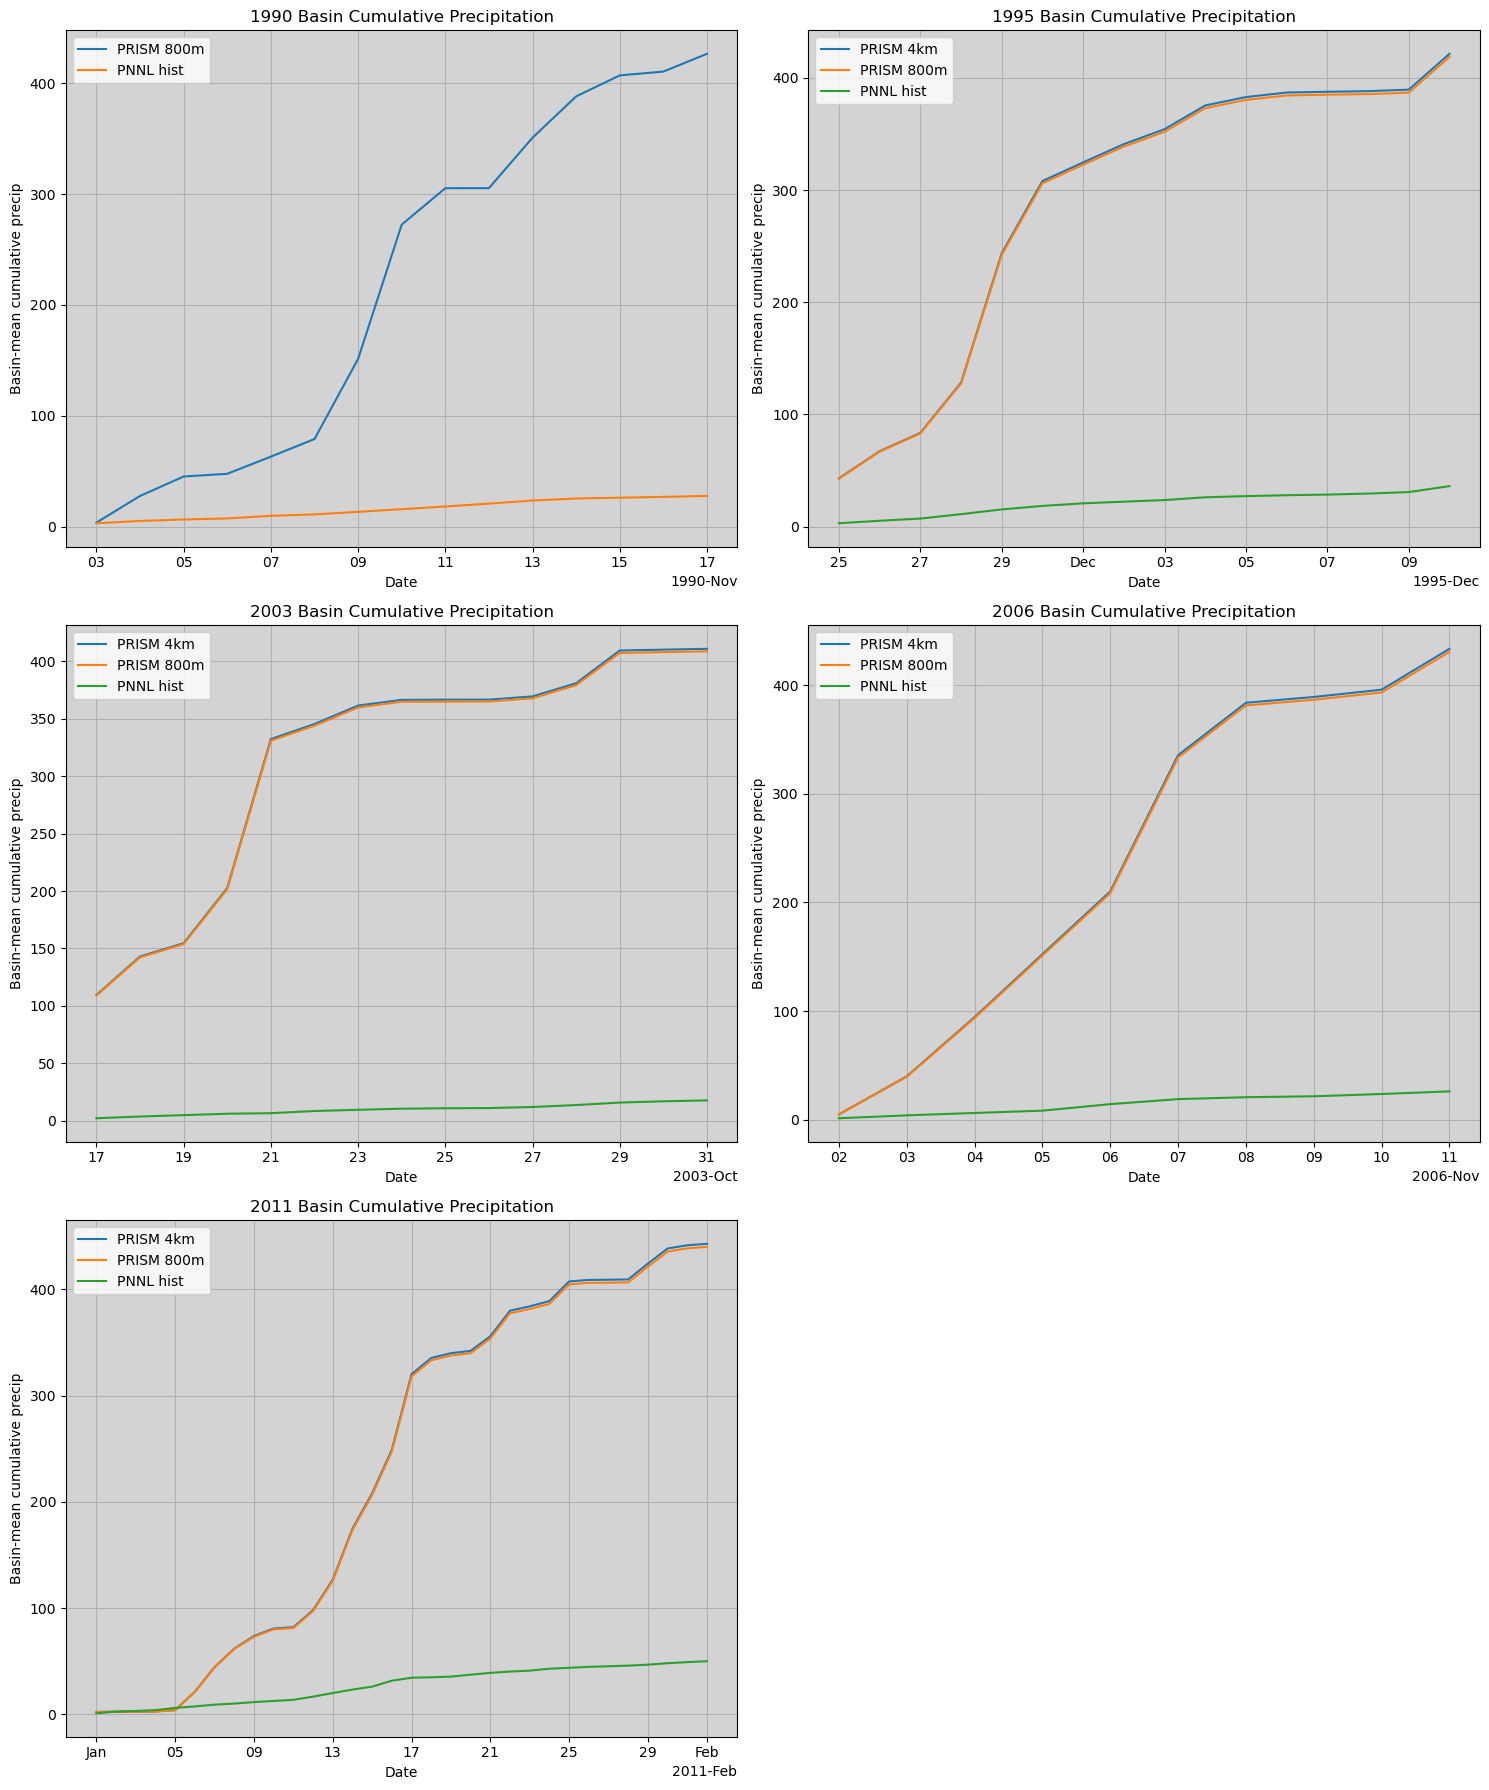

In [ ]:
from pathlib import Path
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import zarr

events = {
    1990: ("1990-11-03", "1990-11-17"),
    1995: ("1995-11-25", "1995-12-10"),
    2003: ("2003-10-17", "2003-10-31"),
    2006: ("2006-11-02", "2006-11-11"),
    2011: ("2011-01-01", "2011-02-01"),
}

BASE = Path("/data0/balaji24/data")
P_PRISM_DIR = BASE / "prism_nc"
P_PNNL_DIR  = BASE / "PNNL" / "historical"
P_CONUS404  = BASE / "derived" / "conus404_skagit_precip_daily.zarr"

def safe_open_zarr(path: Path, group=None):
    try:
        return xr.open_zarr(path, group=group, consolidated=True)
    except Exception:
        return xr.open_zarr(path, group=group, consolidated=False)

def pick_var(ds, candidates):
    dvs = list(ds.data_vars)
    if not dvs:
        return None
    for c in candidates:
        if c in ds.data_vars:
            return c
    return dvs[0]

def basin_mean_cumsum(ds, var, start, end, spatial_dims):
    if var is None:
        return None
    if "time" not in ds[var].coords and "time" not in ds[var].dims:
        return None
    da = ds[var].sel(time=slice(start, end)).sortby("time")
    da = da.mean(dim=list(spatial_dims), skipna=True)
    return da.cumsum()

def hourly_to_daily_cummax(da):
    return da.resample(time="1D").max()

def find_prism_zarr(start, end, resolution_tag):
    pat = f"{start}_{end}_daily_{resolution_tag}_PRISM_data.zarr"
    hits = sorted(P_PRISM_DIR.glob(pat))
    return hits[0] if hits else None

def open_prism_anygroup(zarr_path: Path):
    """Try root first; if no data_vars, try common subgroups discovered via zarr."""
    ds = safe_open_zarr(zarr_path, group=None)
    if list(ds.data_vars):
        return ds

    # If root empty, inspect zarr tree for groups and try them
    root = zarr.open(str(zarr_path), mode="r")
    subgroup_names = []
    for k, v in root.groups():
        subgroup_names.append(k)

    # Try some likely group names first, then whatever is there
    preferred = ["data", "dataset", "prism", "PRISM"]
    for g in preferred + subgroup_names:
        try:
            ds2 = safe_open_zarr(zarr_path, group=g)
            if list(ds2.data_vars):
                ds.close()
                return ds2
            ds2.close()
        except Exception:
            continue

    return ds  # root empty; caller will handle

def load_prism_series(start, end, resolution_tag):
    p = find_prism_zarr(start, end, resolution_tag)
    if p is None:
        return None

    ds = open_prism_anygroup(p)
    var = pick_var(ds, ["ppt", "precip", "prcp", "precipitation"])

    if var is None:
        print(f"[PRISM] No data_vars found in {p.name}. Dataset summary:\n{ds}")
        ds.close()
        return None

    s = basin_mean_cumsum(ds, var, start, end, spatial_dims=("lat", "lon"))
    ds.close()
    return s

def load_pnnl_series(year, start, end):
    yr_dir = P_PNNL_DIR / str(year)
    if not yr_dir.exists():
        return None
    files = sorted(yr_dir.glob("*PREC_ACC_NC*.nc"))
    if not files:
        return None

    ds = xr.open_mfdataset(files, combine="by_coords")
    var = pick_var(ds, ["PREC_ACC_NC", "precip", "prcp", "ppt"])
    if var is None:
        ds.close()
        return None

    spatial_dims = [d for d in ds[var].dims if d != "time"]
    s_hr = basin_mean_cumsum(ds, var, start, end, spatial_dims=spatial_dims)
    ds.close()
    return hourly_to_daily_cummax(s_hr) if s_hr is not None else None

def load_conus404_series(start, end):
    if not P_CONUS404.exists():
        return None
    ds = safe_open_zarr(P_CONUS404)
    var = pick_var(ds, ["prcp", "precip", "ppt", "precipitation", "APCP"])
    if var is None:
        ds.close()
        return None

    spatial_dims = [d for d in ds[var].dims if d != "time"]
    s = basin_mean_cumsum(ds, var, start, end, spatial_dims=spatial_dims)
    ds.close()
    return s

# ----------------------------
# Plot (5 panels; each panel has multiple dataset lines)
# ----------------------------
fig, axs = plt.subplots(3, 2, figsize=(15, 18))
axs = axs.flatten()

for i, (yr, (start, end)) in enumerate(events.items()):
    ax = axs[i]
    series = []

    prism4 = load_prism_series(start, end, "4km")
    if prism4 is not None:
        series.append((prism4, "PRISM 4km"))

    prism800 = load_prism_series(start, end, "800m")
    if prism800 is not None:
        series.append((prism800, "PRISM 800m"))

    pnnl = load_pnnl_series(yr, start, end)
    if pnnl is not None:
        series.append((pnnl, "PNNL hist"))

    conus = load_conus404_series(start, end)
    if conus is not None:
        series.append((conus, "CONUS404-derived"))

    if not series:
        ax.set_title(f"{yr} (no datasets found)")
        ax.axis("off")
        continue

    for da, label in series:
        da.plot(ax=ax, label=label)

    ax.set_title(f"{yr} Basin Cumulative Precipitation")
    ax.set_xlabel("Date")
    ax.set_ylabel("Basin-mean cumulative precip")
    ax.legend()
    ax.grid(True)
    ax.set_facecolor("lightgray")

axs[-1].remove()
plt.tight_layout()
plt.savefig("cumulative_precip_no_hrrr_no_ucla.png", dpi=300)
plt.show()


In [3]:
import xarray as xr
import pandas as pd

p = "/data0/balaji24/data/derived/conus404_skagit_precip_daily.zarr"
ds = xr.open_zarr(p, consolidated=False)

print(ds)
print("data_vars:", list(ds.data_vars))
print("dims:", ds.dims)
print("coords:", list(ds.coords))

# Find any datetime-like coord/dim
for name in list(ds.coords) + list(ds.dims):
    if name in ds:
        v = ds[name]
        if hasattr(v, "dtype") and "datetime64" in str(v.dtype):
            print("datetime coord:", name, v.values[0], "→", v.values[-1])

<xarray.Dataset> Size: 14GB
Dimensions:             (y: 1015, x: 1367, time: 2557)
Coordinates:
  * time                (time) datetime64[ns] 20kB 2014-01-01 ... 2020-12-31
    lat                 (y, x) float32 6MB dask.array<chunksize=(256, 256), meta=np.ndarray>
  * y                   (y) float64 8kB -2.028e+06 -2.024e+06 ... 2.028e+06
  * x                   (x) float64 11kB -2.732e+06 -2.728e+06 ... 2.732e+06
    lon                 (y, x) float32 6MB dask.array<chunksize=(256, 256), meta=np.ndarray>
Data variables:
    basin_mask          (y, x) float32 6MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    precip_daily        (time, y, x) float32 14GB dask.array<chunksize=(90, 256, 256), meta=np.ndarray>
    precip_basin_daily  (time) float32 10kB dask.array<chunksize=(180,), meta=np.ndarray>
Attributes:
    source:      intake:conus404-catalog:conus404-hourly-osn
    precip_var:  PREC_ACC_NC
    years:       2014-2020
    note:        precip_daily: daily sum on native grid 


================ 1990 (1990-11-03 → 1990-11-17) ================
[PRISM] No data_vars found in 1990-11-03_1990-11-17_daily_4km_PRISM_data.zarr. Dataset summary:
<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
  - PRISM 800m: var='ppt', units='(units missing)'
  - PNNL hist: var='PREC_ACC_NC', units='mm'
  - ORNL DaymetV4: var='prcp', units='mm/day'

================ 1995 (1995-11-25 → 1995-12-10) ================
  - PRISM 4km: var='ppt', units='(units missing)'
  - PRISM 800m: var='ppt', units='(units missing)'
  - PNNL hist: var='PREC_ACC_NC', units='mm'
  - ORNL DaymetV4: var='prcp', units='mm/day'

================ 2003 (2003-10-17 → 2003-10-31) ================
  - PRISM 4km: var='ppt', units='(units missing)'
  - PRISM 800m: var='ppt', units='(units missing)'
  - PNNL hist: var='PREC_ACC_NC', units='mm'
  - ORNL DaymetV4: var='prcp', units='mm/day'

================ 2006 (2006-11-02 → 2006-11-11) ================
  - PRISM 4km: var='ppt', units='(units miss

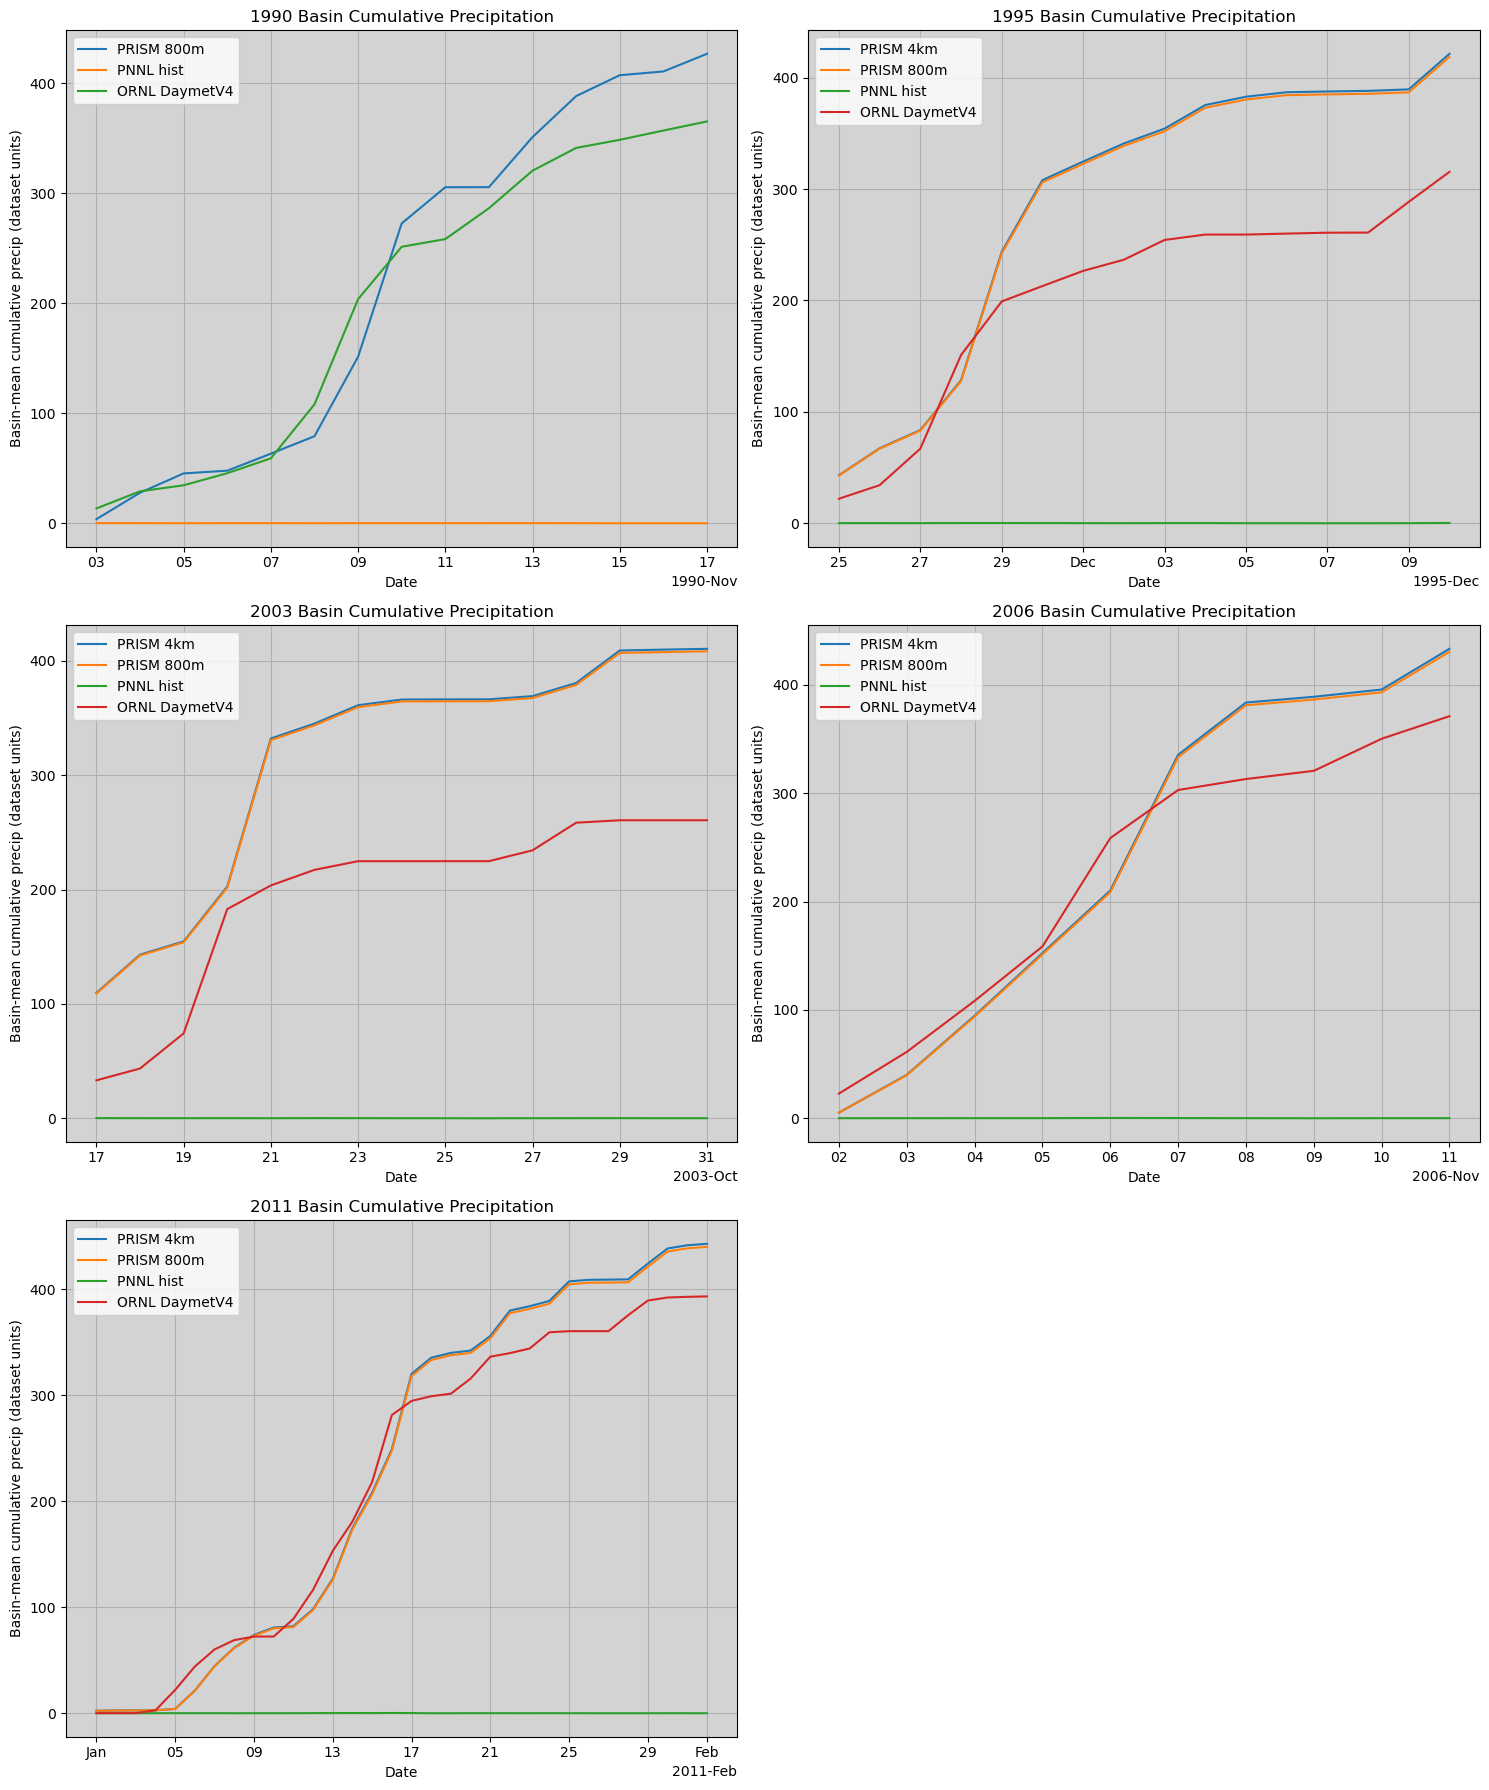

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import zarr

# -----------------------------
# Events 
# -----------------------------
events = {
    1990: ("1990-11-03", "1990-11-17"),
    1995: ("1995-11-25", "1995-12-10"),
    2003: ("2003-10-17", "2003-10-31"),
    2006: ("2006-11-02", "2006-11-11"),
    2011: ("2011-01-01", "2011-02-01"),
}

# -----------------------------
# Paths (your exact locations)
# -----------------------------
BASE = Path("/data0/balaji24/data")
P_PRISM_DIR = BASE / "prism_nc"
P_PNNL_DIR  = BASE / "PNNL" / "historical"
P_PNNL_GEO  = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"
P_ORNL_DIR  = BASE / "ornl_nc"

# -----------------------------
# Helpers
# -----------------------------
def safe_open_zarr(path: Path, group=None):
    try:
        return xr.open_zarr(path, group=group, consolidated=True)
    except Exception:
        return xr.open_zarr(path, group=group, consolidated=False)

def pick_var(ds, candidates):
    dvs = list(ds.data_vars)
    if not dvs:
        return None
    for c in candidates:
        if c in ds.data_vars:
            return c
    return dvs[0]

def print_var_units(ds, var, label):
    if var is None:
        print(f"  - {label}: var=None")
        return
    units = ds[var].attrs.get("units", "(units missing)")
    print(f"  - {label}: var='{var}', units='{units}'")

def find_prism_zarr(start, end, resolution_tag):
    pat = f"{start}_{end}_daily_{resolution_tag}_PRISM_data.zarr"
    hits = sorted(P_PRISM_DIR.glob(pat))
    return hits[0] if hits else None

def open_prism_anygroup(zarr_path: Path):
    """
    Try root first; if empty, inspect zarr tree for groups and open the first one that has data_vars.
    """
    ds = safe_open_zarr(zarr_path, group=None)
    if list(ds.data_vars):
        return ds

    root = zarr.open(str(zarr_path), mode="r")
    subgroup_names = [k for k, _ in root.groups()]

    preferred = ["data", "dataset", "prism", "PRISM"]
    for g in preferred + subgroup_names:
        try:
            ds2 = safe_open_zarr(zarr_path, group=g)
            if list(ds2.data_vars):
                ds.close()
                return ds2
            ds2.close()
        except Exception:
            continue

    return ds  # root empty; caller will handle

def reduce_to_1d_time(da: xr.DataArray) -> xr.DataArray:
    """
    Ensure output is 1D over time by averaging over all non-time dims.
    """
    other_dims = [d for d in da.dims if d != "time"]
    if other_dims:
        da = da.mean(dim=other_dims, skipna=True)
    return da

def basin_mean_cumsum(ds, var, start, end):
    if var is None:
        return None
    if "time" not in ds[var].coords and "time" not in ds[var].dims:
        return None
    da = ds[var].sel(time=slice(start, end)).sortby("time")
    da = reduce_to_1d_time(da)
    # cumulative over time
    return da.cumsum("time")

def hourly_to_daily_cummax(da):
    """
    If data is hourly cumulative, daily max gives end-of-day cumulative.
    """
    return da.resample(time="1D").max()

# -----------------------------
# PRISM loaders (event zarrs)
# -----------------------------
def load_prism_series(start, end, resolution_tag):
    p = find_prism_zarr(start, end, resolution_tag)
    if p is None:
        return None

    ds = open_prism_anygroup(p)
    var = pick_var(ds, ["ppt", "precip", "prcp", "precipitation"])
    if var is None:
        print(f"[PRISM] No data_vars found in {p.name}. Dataset summary:\n{ds}")
        ds.close()
        return None

    print_var_units(ds, var, f"PRISM {resolution_tag}")
    s = basin_mean_cumsum(ds, var, start, end)
    ds.close()
    return s

# -----------------------------
# PNNL loader (year folders)
# -----------------------------
def load_pnnl_series(year, start, end):
    yr_dir = P_PNNL_DIR / str(year)
    if not yr_dir.exists():
        return None

    files = sorted(yr_dir.rglob("*.nc"))
    if not files:
        return None

    ds = xr.open_mfdataset(files, combine="by_coords")
    var = pick_var(ds, ["PREC_ACC_NC", "PREC_ACC", "apcp", "tp", "precip", "prcp", "ppt"])
    if var is None:
        ds.close()
        return None

    print_var_units(ds, var, "PNNL hist")

    # Reduce to 1D time series (mean over all non-time dims)
    da = ds[var].sel(time=slice(start, end)).sortby("time")
    da = reduce_to_1d_time(da)

    # PNNL PREC_ACC_NC is often accumulated/cumulative at sub-daily step
    # Using daily max gives daily end-of-day cumulative, then we rebase to 0 at start.
    daily_cum = hourly_to_daily_cummax(da)

    # Rebase to start at 0 so it’s comparable across datasets
    daily_cum = daily_cum - daily_cum.isel(time=0)

    ds.close()
    return daily_cum

# -----------------------------
# ORNL DaymetV4 loader (yearly zarr)
# -----------------------------
def load_ornl_series(year, start, end):
    z = P_ORNL_DIR / f"{year}_{year}_ref_DaymetV4_ORNL_data.zarr"
    if not z.exists():
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["prcp", "precip", "precipitation", "ppt"])
    if var is None:
        ds.close()
        return None

    print_var_units(ds, var, "ORNL DaymetV4")

    # Daymet prcp is typically daily already; cumulative directly
    s = basin_mean_cumsum(ds, var, start, end)
    ds.close()
    return s

# -----------------------------
# Plot
# -----------------------------
fig, axs = plt.subplots(3, 2, figsize=(15, 18))
axs = axs.flatten()

for i, (yr, (start, end)) in enumerate(events.items()):
    ax = axs[i]
    series = []

    print(f"\n================ {yr} ({start} → {end}) ================")

    prism4 = load_prism_series(start, end, "4km")
    if prism4 is not None:
        series.append((prism4, "PRISM 4km"))

    prism800 = load_prism_series(start, end, "800m")
    if prism800 is not None:
        series.append((prism800, "PRISM 800m"))

    pnnl = load_pnnl_series(yr, start, end)
    if pnnl is not None:
        series.append((pnnl, "PNNL hist"))

    ornl = load_ornl_series(yr, start, end)
    if ornl is not None:
        series.append((ornl, "ORNL DaymetV4"))

    if not series:
        ax.set_title(f"{yr} (no datasets found)")
        ax.axis("off")
        continue

    # Plot safely (each is 1D over time)
    for da, label in series:
        da.plot(ax=ax, label=label)

    ax.set_title(f"{yr} Basin Cumulative Precipitation")
    ax.set_xlabel("Date")
    ax.set_ylabel("Basin-mean cumulative precip (dataset units)")
    ax.legend()
    ax.grid(True)
    ax.set_facecolor("lightgray")

# remove extra subplot
axs[-1].remove()

plt.tight_layout()
plt.savefig("cumulative_precip_prism_pnnl_ornl.png", dpi=300)
plt.show()



================ 1990 (1990-11-03 → 1990-11-17) ================


  - PRISM 4km: (no precip var found)
  - PRISM 800m [1990-11-03_1990-11-17_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'
  - ORNL Daymet [1990_1990_ref_DaymetV4_ORNL_data.zarr]: var='prcp', units='mm/day'
  - PNNL hist: var='PREC_ACC_NC', units='mm'
  - CONUS404: var='PREC_ACC_NC', units='mm'
  - SNOTEL: triplet field not found in GeoJSON

================ 1995 (1995-11-25 → 1995-12-10) ================
  - PRISM 4km [1995-11-25_1995-12-10_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'
  - PRISM 800m [1995-11-25_1995-12-10_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'
  - ORNL Daymet [1995_1995_ref_DaymetV4_ORNL_data.zarr]: var='prcp', units='mm/day'
  - PNNL hist: var='PREC_ACC_NC', units='mm'
  - CONUS404: var='PREC_ACC_NC', units='mm'
  - SNOTEL: triplet field not found in GeoJSON

================ 2003 (2003-10-17 → 2003-10-31) ================
  - PRISM 4km [2003-10-17_2003-10-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'
  - PRISM 8

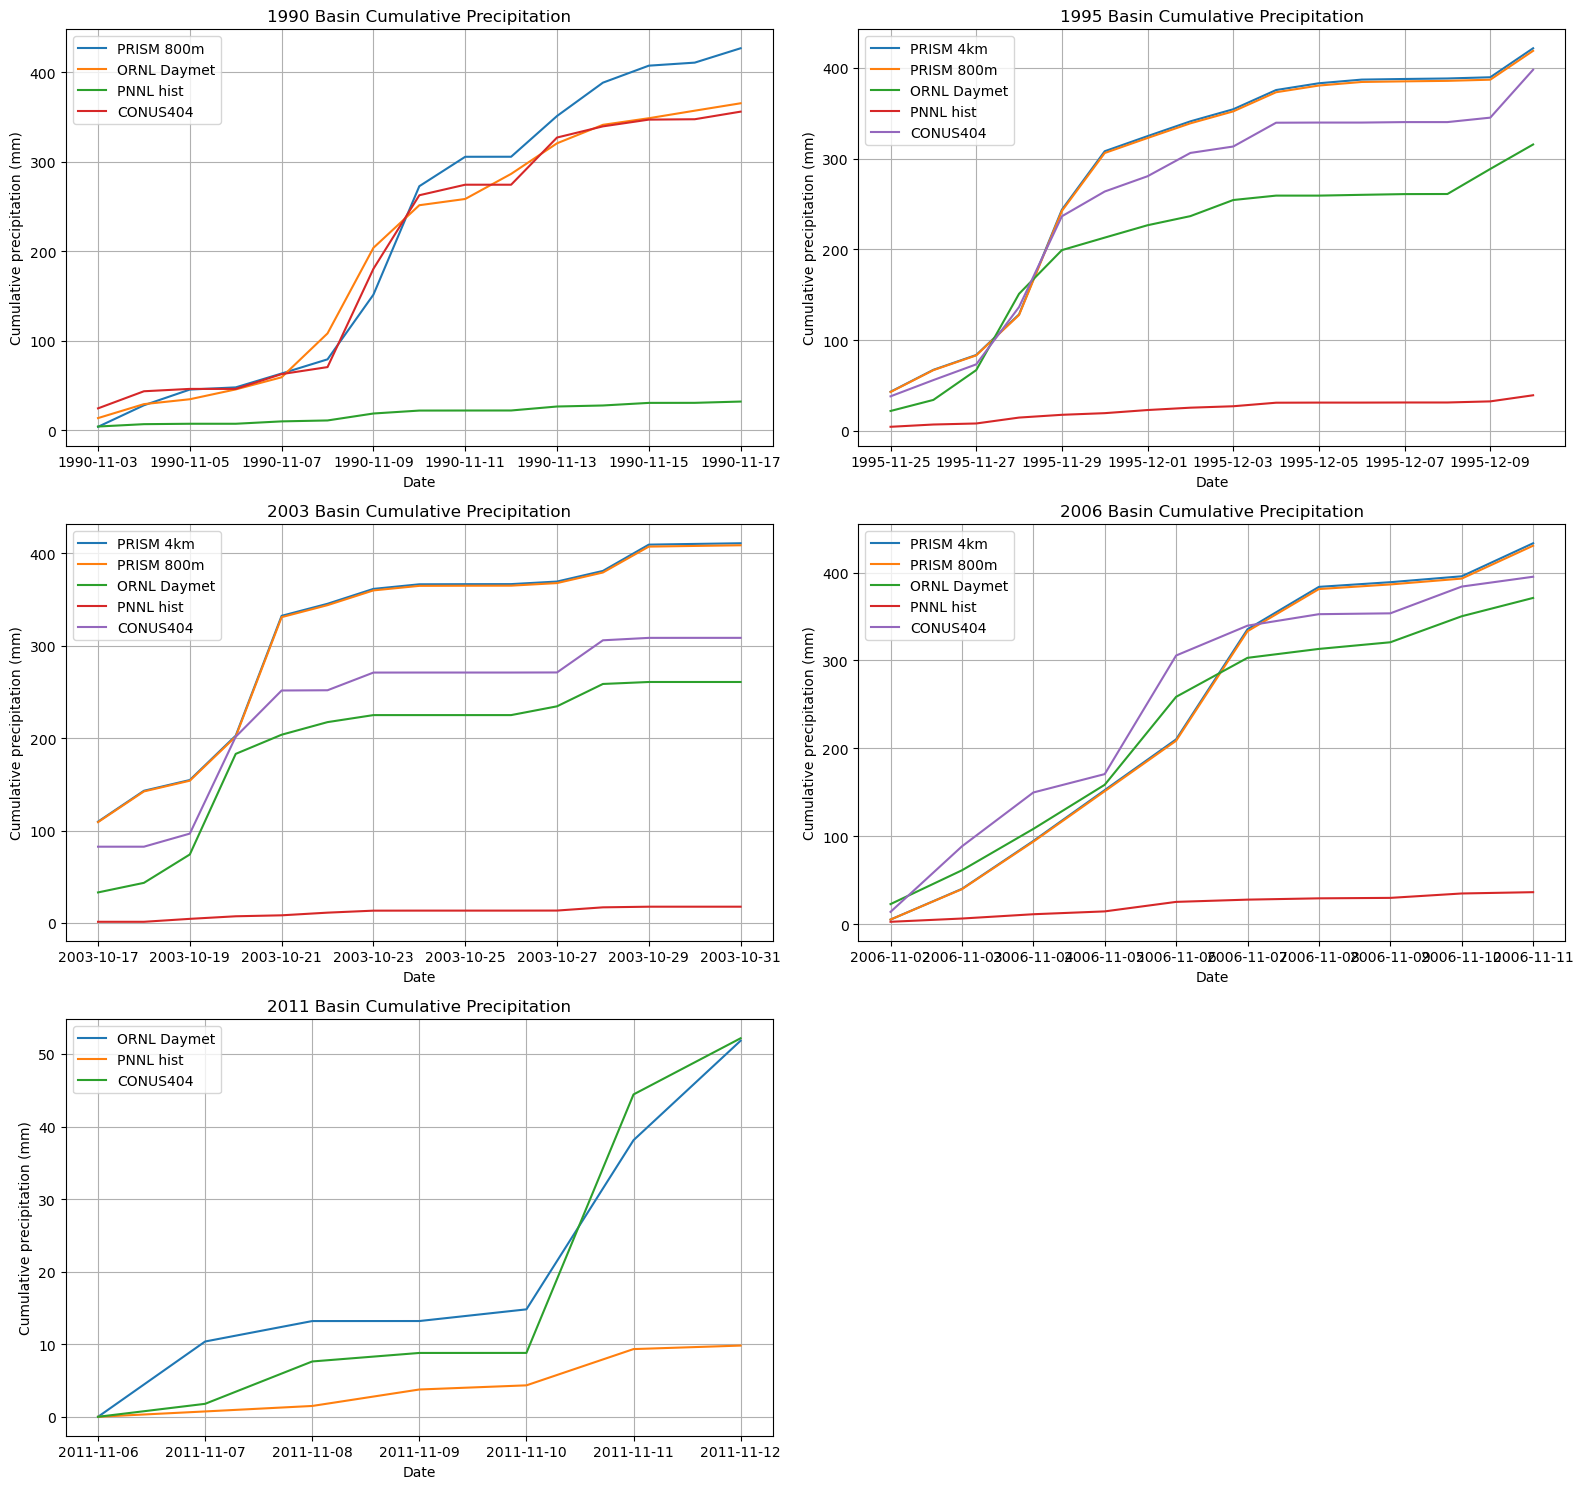

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import shapely.geometry as sgeom
import regionmask
import intake
import requests

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")
P_ORNL_DIR  = BASE / "ornl_nc"
P_PNNL_DIR  = BASE / "PNNL" / "historical"
P_PNNL_GEO  = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"
BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

# External
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

SNOTEL_STATIONS_GEOJSON = (
    "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
)

events = {
    1990: ("1990-11-03", "1990-11-17"),
    1995: ("1995-11-25", "1995-12-10"),
    2003: ("2003-10-17", "2003-10-31"),
    2006: ("2006-11-02", "2006-11-11"),
    2011: ("2011-11-06", "2011-11-12"),
}

# ----------------------------
# HELPERS
# ----------------------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO)
    gdf = gdf.to_crs("EPSG:4326")  # ensure lon/lat
    return gdf.geometry.union_all()

def ensure_daily(da):
    dt = pd.to_datetime(da["time"].values)
    if len(dt) < 2:
        return da
    med = pd.Series(dt).diff().dt.total_seconds().median()
    if med is not None and med < 23 * 3600:
        return da.resample(time="1D").sum()
    return da

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1:
        return False
    if da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def hourly_cum_to_daily_mm(da_cum):
    inc = da_cum.diff("time").clip(min=0)
    return inc.resample(time="1D").sum()

# ----------------------------
# MASKING
# ----------------------------
def mask_curvilinear_bool(ds, geom, lon_name="lon", lat_name="lat"):
    # regionmask older versions: positional args only
    region = regionmask.Regions([geom])
    m = region.mask(ds[lon_name], ds[lat_name])  # dims like (y,x)
    return ~xr.ufuncs.isnan(m)

def basin_mean_over_dims(da, mask_bool, dims):
    return da.where(mask_bool).mean(dim=dims, skipna=True)

# ----------------------------
# PRISM (exact match only)
# ----------------------------
def find_prism_zarr_exact(start, end, tag):
    # Naming pattern: {start}_{end}_daily_{tag}_PRISM_data.zarr
    s0 = pd.to_datetime(start).strftime("%Y-%m-%d")
    s1 = pd.to_datetime(end).strftime("%Y-%m-%d")
    patt = f"{s0}_{s1}_daily_{tag}_PRISM_data.zarr"
    hits = list(BASE.glob(f"**/{patt}"))
    return hits[0] if hits else None

def load_prism(start, end, tag, geom):
    z = find_prism_zarr_exact(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag}: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    da = ensure_daily(da)

    # Most of PRISM zarrs are already basin-clipped/aggregated by your pipeline,
    # but if not, this spatial mean keeps it safe.
    spatial = [d for d in da.dims if d != "time"]
    bm = da.mean(dim=spatial, skipna=True)

    ds.close()
    return bm.cumsum("time")

# ----------------------------
# ORNL Daymet
# ----------------------------
def load_ornl(year, start, end, geom):
    z = next(P_ORNL_DIR.glob(f"{year}_{year}_ref_*ORNL_data.zarr"), None)
    if z is None:
        print("  - ORNL Daymet: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["prcp"])
    if var is None:
        print("  - ORNL Daymet: (no prcp var)")
        ds.close()
        return None

    print_units(ds, var, f"ORNL Daymet [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    da = ensure_daily(da)
    spatial = [d for d in da.dims if d != "time"]
    bm = da.mean(dim=spatial, skipna=True)

    ds.close()
    return bm.cumsum("time")

# ----------------------------
# PNNL WRF
# ----------------------------
_PNNL_MASK_NP = None

def build_pnnl_mask_np(geom):
    geo = xr.open_dataset(P_PNNL_GEO)
    lat = geo["XLAT_M"].isel(Time=0)
    lon = geo["XLONG_M"].isel(Time=0)
    geo.close()

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    return np.asarray(~np.isnan(m))

def load_pnnl(year, start, end, geom):
    global _PNNL_MASK_NP

    f = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", "PNNL hist")

    if _PNNL_MASK_NP is None:
        _PNNL_MASK_NP = build_pnnl_mask_np(geom)

    da = ds["PREC_ACC_NC"].sel(time=slice(start, end)).sortby("time")

    # Basin mean (WRF dims)
    spatial = [d for d in da.dims if d != "time"]
    m = xr.DataArray(_PNNL_MASK_NP.astype("bool"), dims=spatial)
    bm_hourly_cum = da.where(m).mean(dim=spatial, skipna=True)

    daily = hourly_cum_to_daily_mm(bm_hourly_cum)
    out = daily.cumsum("time")

    ds.close()
    return out

# ----------------------------
# CONUS404 (curvilinear y/x)
# ----------------------------
_conus_ds = None
def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus(start, end, geom):
    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()
    var = pick_var(ds, ["PREC_ACC_NC", "prcp"])
    if var is None:
        print("  - CONUS404: (no precip var)")
        return None

    print_units(ds, var, "CONUS404")

    # CONUS404 has dims (time, y, x) and coords lat(y,x), lon(y,x)
    mask2d = mask_curvilinear_bool(ds, geom, lon_name="lon", lat_name="lat")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    da = ensure_daily(da)

    bm = basin_mean_over_dims(da, mask2d, dims=("y", "x"))
    return bm.cumsum("time")

# ----------------------------
# SNOTEL (external) — robust station selection using GeoPandas
# ----------------------------
def load_snotel(start, end, geom):
    # Read stations into GeoDataFrame
    stations = gpd.read_file(SNOTEL_STATIONS_GEOJSON).to_crs("EPSG:4326")
    basin = gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")

    # Use intersects (safer than within)
    sel = gpd.sjoin(stations, basin, predicate="intersects", how="inner")

    # Some files store as 'triplet', some as 'stationTriplet'
    if "triplet" in sel.columns:
        triplets = sel["triplet"].dropna().unique().tolist()
    elif "stationTriplet" in sel.columns:
        triplets = sel["stationTriplet"].dropna().unique().tolist()
    else:
        print("  - SNOTEL: triplet field not found in GeoJSON")
        return None

    triplets = sorted(set(triplets))
    if not triplets:
        print("  - SNOTEL: no stations intersect basin")
        return None

    # AWDB daily precip
    url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data/getDaily"
    params = {
        "stationTriplets": ",".join(triplets),
        "elements": "PRCPSA",
        "beginDate": start,
        "endDate": end,
        "format": "json",
    }
    rr = requests.get(url, params=params, timeout=120)
    rr.raise_for_status()
    js = rr.json()

    data = {}
    for st in js:
        trip = st.get("stationTriplet")
        vals = st.get("values", [])
        if not trip or not vals:
            continue
        s = {pd.to_datetime(v["date"]): (np.nan if v["value"] is None else float(v["value"])) for v in vals}
        data[trip] = pd.Series(s)

    if not data:
        print("  - SNOTEL: AWDB returned no data")
        return None

    df_in = pd.DataFrame(data).sort_index()

    print("  - SNOTEL: var='PRCPSA', units='inches → mm'")
    df_mm = df_in * 25.4

    daily_mean = df_mm.mean(axis=1, skipna=True).loc[pd.to_datetime(start):pd.to_datetime(end)]
    daily_mean = daily_mean.asfreq("D")

    da = xr.DataArray(
        daily_mean.cumsum().values,
        coords={"time": daily_mean.index},
        dims=("time",),
        name="SNOTEL"
    )
    return da

# ----------------------------
# MAIN PLOT
# ----------------------------
def main():
    geom = load_basin_geom()

    n = len(events)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axs = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axs = np.array(axs).reshape(-1)

    for i, (yr, (start, end)) in enumerate(events.items()):
        ax = axs[i]
        print(f"\n================ {yr} ({start} → {end}) ================")

        series = [
            ("PRISM 4km",    load_prism(start, end, "4km", geom)),
            ("PRISM 800m",   load_prism(start, end, "800m", geom)),
            ("ORNL Daymet",  load_ornl(yr, start, end, geom)),
            ("PNNL hist",    load_pnnl(yr, start, end, geom)),
            ("CONUS404",     load_conus(start, end, geom)),
            ("SNOTEL",       load_snotel(start, end, geom)),
        ]

        for label, da in series:
            if is_plottable_1d(da):
                ax.plot(pd.to_datetime(da["time"].values), da.values, label=label)

        ax.set_title(f"{yr} Basin Cumulative Precipitation")
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative precipitation (mm)")
        ax.grid(True)
        ax.legend()

    # remove unused axes
    for j in range(len(events), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()



================ 1990 (1990-11-03 → 1990-11-17) ================
  - PRISM 4km: (no precip var found)
  - PRISM 800m [1990-11-03_1990-11-17_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'
  - ORNL Daymet [1990_1990_ref_DaymetV4_ORNL_data.zarr]: var='prcp', units='mm/day'
  - PNNL hist: var='PREC_ACC_NC', units='mm'
    [PNNL hist auto] frac_neg=0.499, mean_raw=1.004, mean_diff_pos=0.08857 => incremental(no diff)
  - CONUS404: var='PREC_ACC_NC', units='mm'
  - SNOTEL: triplet field not found in GeoJSON

================ 1995 (1995-11-25 → 1995-12-10) ================
  - PRISM 4km [1995-11-25_1995-12-10_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'
  - PRISM 800m [1995-11-25_1995-12-10_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'
  - ORNL Daymet [1995_1995_ref_DaymetV4_ORNL_data.zarr]: var='prcp', units='mm/day'
  - PNNL hist: var='PREC_ACC_NC', units='mm'
    [PNNL hist auto] frac_neg=0.473, mean_raw=1.247, mean_diff_pos=0.1024 => incremental(no diff)

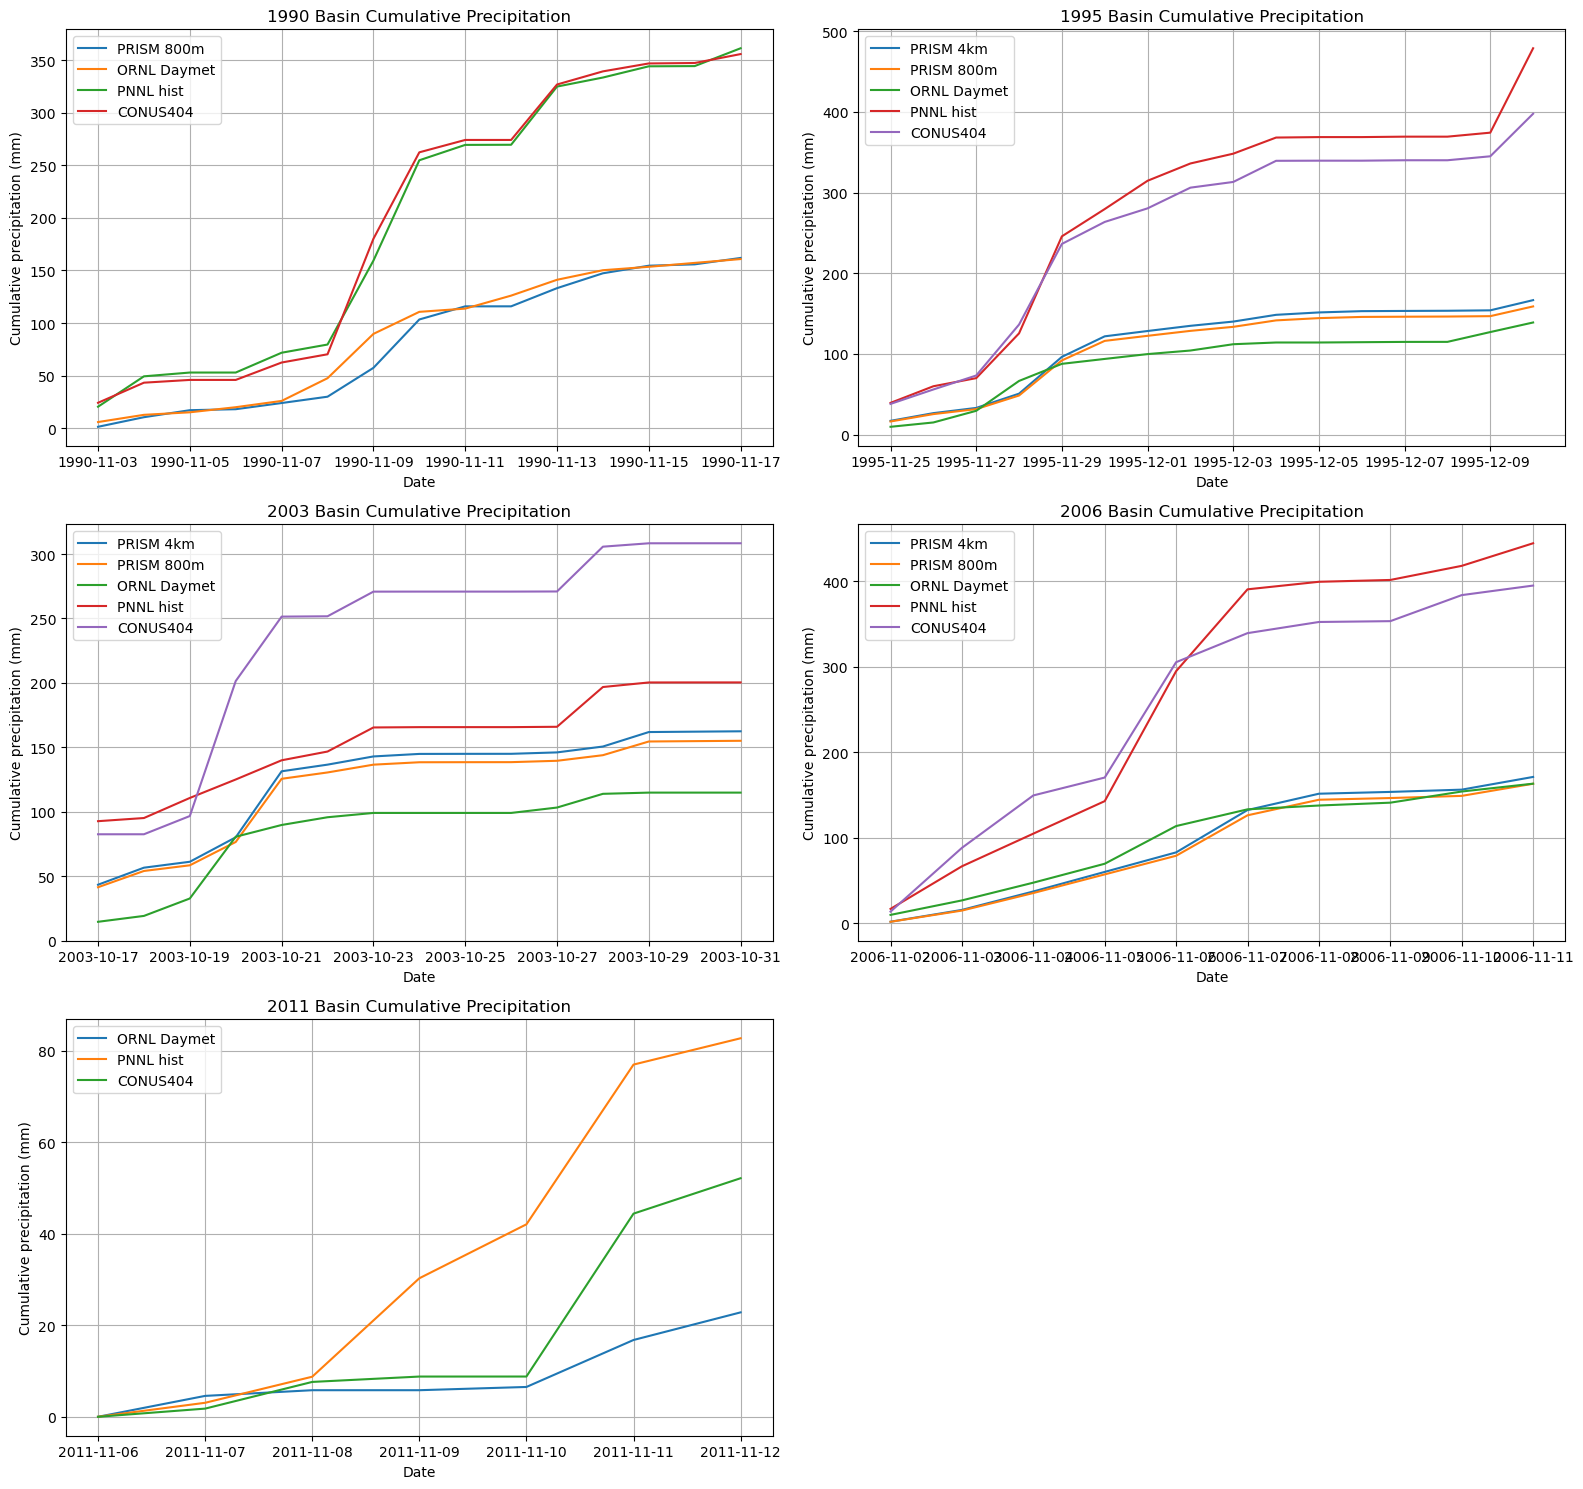

In [ ]:
# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison 
# PRISM (local zarr), ORNL Daymet (local zarr),
# PNNL hist WRF (local netcdf), CONUS404 (external OSN),
# SNOTEL (external stations + AWDB daily PRCPSA)
#
# Fixed:
# - PRISM: exact window match only (no wrong-year fallback)
# - CONUS404: curvilinear mask on (y,x) (no meshgrid)
# - PNNL: AUTO-detect whether PREC_ACC_NC is cumulative or incremental
# - Plot guard: only plot if numeric + finite values exist
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import shapely.geometry as sgeom
import regionmask
import intake
import requests

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_ORNL_DIR  = BASE / "ornl_nc"
P_PNNL_DIR  = BASE / "PNNL" / "historical"
P_PNNL_GEO  = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"
BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

# External
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

SNOTEL_STATIONS_GEOJSON = (
    "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
)

# ----------------------------
# EVENTS (edit)
# ----------------------------
events = {
    1990: ("1990-11-03", "1990-11-17"),
    1995: ("1995-11-25", "1995-12-10"),
    2003: ("2003-10-17", "2003-10-31"),
    2006: ("2006-11-02", "2006-11-11"),
    2011: ("2011-11-06", "2011-11-12"),
}

# ----------------------------
# HELPERS
# ----------------------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    return gdf.geometry.union_all()

def ensure_daily_sum(da):
    """If sub-daily, sum to daily. If daily already, keep daily."""
    dt = pd.to_datetime(da["time"].values)
    if len(dt) < 2:
        return da
    med = pd.Series(dt).diff().dt.total_seconds().median()
    if med is not None and med < 23 * 3600:
        return da.resample(time="1D").sum()
    # still enforce daily index if already daily
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def hourly_cum_to_daily_mm(bm_cum):
    """For true cumulative counters: diff->clip->daily sum."""
    inc = bm_cum.diff("time").clip(min=0)
    return inc.resample(time="1D").sum()

def pnnl_auto_to_daily_mm(bm_series, label="PNNL hist"):
    """
    AUTO detect if PREC_ACC_NC is:
      A) cumulative-from-start counter  -> use diff()
      B) already incremental (hourly accumulation) -> do NOT diff
    Uses small computes (safe): only on the 1D basin-mean series.
    """
    bm = bm_series.dropna("time")

    if bm.size < 3:
        print(f"    [{label} auto] too few points to decide; treating as incremental")
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")

    # compute diagnostics safely (1D only)
    frac_neg = float((d < 0).mean().compute()) if hasattr(d.data, "compute") else float((d < 0).mean())
    mean_raw = float(bm.mean().compute()) if hasattr(bm.data, "compute") else float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean().compute()) if hasattr(d.data, "compute") else float(d.clip(min=0).mean())

    # Heuristic decision
    # - if it decreases/resets more than tiny fraction - incremental-like
    # - if diff is much smaller than raw - raw likely already incremental
    use_diff = True
    if frac_neg > 0.01:
        use_diff = False
    elif mean_raw > 0 and mean_diff_pos < 0.2 * mean_raw:
        use_diff = False

    mode = "cumulative->diff" if use_diff else "incremental(no diff)"
    print(f"    [{label} auto] frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g} => {mode}")

    if use_diff:
        hourly_inc = d.clip(min=0)
    else:
        hourly_inc = bm.clip(min=0)

    return hourly_inc.resample(time="1D").sum()

# ----------------------------
# MASKING
# ----------------------------
def mask_curvilinear_bool(ds, geom, lon_name="lon", lat_name="lat"):
    """
    For curvilinear grids where lat/lon are 2D on (y,x) etc.
    SAFE: no meshgrid, no .values materialization.
    """
    region = regionmask.Regions([geom])
    m = region.mask(ds[lon_name], ds[lat_name])  # positional args for older regionmask
    return ~xr.ufuncs.isnan(m)

def basin_mean_over_dims(da, mask_bool, dims):
    return da.where(mask_bool).mean(dim=dims, skipna=True)

# ----------------------------
# PRISM (exact match only)
# ----------------------------
def find_prism_zarr_exact(start, end, tag):
    s0 = pd.to_datetime(start).strftime("%Y-%m-%d")
    s1 = pd.to_datetime(end).strftime("%Y-%m-%d")
    patt = f"{s0}_{s1}_daily_{tag}_PRISM_data.zarr"
    hits = list(BASE.glob(f"**/{patt}"))
    return hits[0] if hits else None

def load_prism(start, end, tag):
    z = find_prism_zarr_exact(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag}: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)          # daily totals
    spatial = [d for d in daily.dims if d != "time"]
    bm = daily.mean(dim=spatial, skipna=True)  # safe fallback

    ds.close()
    return bm.cumsum("time")

# ----------------------------
# ORNL Daymet
# ----------------------------
def load_ornl(year, start, end):
    z = next(P_ORNL_DIR.glob(f"{year}_{year}_ref_*ORNL_data.zarr"), None)
    if z is None:
        print("  - ORNL Daymet: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["prcp"])
    if var is None:
        print("  - ORNL Daymet: (no prcp var)")
        ds.close()
        return None

    print_units(ds, var, f"ORNL Daymet [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)  # if already daily, safe
    spatial = [d for d in daily.dims if d != "time"]
    bm = daily.mean(dim=spatial, skipna=True)

    ds.close()
    return bm.cumsum("time")

# ----------------------------
# PNNL HIST WRF (AUTO)
# ----------------------------
_PNNL_MASK_NP = None

def build_pnnl_mask_np(geom):
    geo = xr.open_dataset(P_PNNL_GEO)
    lat = geo["XLAT_M"].isel(Time=0)
    lon = geo["XLONG_M"].isel(Time=0)
    geo.close()

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    return np.asarray(~np.isnan(m))

def load_pnnl(year, start, end, geom):
    global _PNNL_MASK_NP

    f = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", "PNNL hist")

    if _PNNL_MASK_NP is None:
        _PNNL_MASK_NP = build_pnnl_mask_np(geom)

    da = ds["PREC_ACC_NC"].sel(time=slice(start, end)).sortby("time")

    # Basin-mean 1D series first (safe)
    spatial = [d for d in da.dims if d != "time"]
    m = xr.DataArray(_PNNL_MASK_NP.astype("bool"), dims=spatial)
    bm = da.where(m).mean(dim=spatial, skipna=True)

    # AUTO choose daily conversion
    daily = pnnl_auto_to_daily_mm(bm, label="PNNL hist")
    out = daily.cumsum("time")

    ds.close()
    return out

# ----------------------------
# CONUS404 (external)
# ----------------------------
_conus_ds = None
def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus(start, end, geom):
    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()
    var = pick_var(ds, ["PREC_ACC_NC", "prcp"])
    if var is None:
        print("  - CONUS404: (no precip var)")
        return None

    print_units(ds, var, "CONUS404")

    mask2d = mask_curvilinear_bool(ds, geom, lon_name="lon", lat_name="lat")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)  # daily totals
    bm = basin_mean_over_dims(daily, mask2d, dims=("y", "x"))

    return bm.cumsum("time")

# ----------------------------
# SNOTEL (external)
# ----------------------------
def load_snotel(start, end, geom):
    stations = gpd.read_file(SNOTEL_STATIONS_GEOJSON).to_crs("EPSG:4326")
    basin = gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")

    sel = gpd.sjoin(stations, basin, predicate="intersects", how="inner")

    if "triplet" in sel.columns:
        triplets = sel["triplet"].dropna().unique().tolist()
    elif "stationTriplet" in sel.columns:
        triplets = sel["stationTriplet"].dropna().unique().tolist()
    else:
        print("  - SNOTEL: triplet field not found in GeoJSON")
        return None

    triplets = sorted(set(triplets))
    if not triplets:
        print("  - SNOTEL: no stations intersect basin")
        return None

    url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data/getDaily"
    params = {
        "stationTriplets": ",".join(triplets),
        "elements": "PRCPSA",
        "beginDate": start,
        "endDate": end,
        "format": "json",
    }
    rr = requests.get(url, params=params, timeout=120)
    rr.raise_for_status()
    js = rr.json()

    data = {}
    for st in js:
        trip = st.get("stationTriplet")
        vals = st.get("values", [])
        if not trip or not vals:
            continue
        s = {pd.to_datetime(v["date"]): (np.nan if v["value"] is None else float(v["value"])) for v in vals}
        data[trip] = pd.Series(s)

    if not data:
        print("  - SNOTEL: AWDB returned no data")
        return None

    df_in = pd.DataFrame(data).sort_index()

    print("  - SNOTEL: var='PRCPSA', units='inches → mm'")
    df_mm = df_in * 25.4
    daily_mean = df_mm.mean(axis=1, skipna=True).loc[pd.to_datetime(start):pd.to_datetime(end)].asfreq("D")

    da = xr.DataArray(
        daily_mean.cumsum().values,
        coords={"time": daily_mean.index},
        dims=("time",),
        name="SNOTEL"
    )
    return da

# ----------------------------
# MAIN
# ----------------------------
def main():
    geom = load_basin_geom()

    n = len(events)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axs = np.array(axs).reshape(-1)

    for i, (yr, (start, end)) in enumerate(events.items()):
        ax = axs[i]
        print(f"\n================ {yr} ({start} → {end}) ================")

        series = [
            ("PRISM 4km",   load_prism(start, end, "4km")),
            ("PRISM 800m",  load_prism(start, end, "800m")),
            ("ORNL Daymet", load_ornl(yr, start, end)),
            ("PNNL hist",   load_pnnl(yr, start, end, geom)),
            ("CONUS404",    load_conus(start, end, geom)),
            ("SNOTEL",      load_snotel(start, end, geom)),
        ]

        for label, da in series:
            if is_plottable_1d(da):
                ax.plot(pd.to_datetime(da["time"].values), da.values, label=label)

        ax.set_title(f"{yr} Basin Cumulative Precipitation")
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative precipitation (mm)")
        ax.grid(True)
        ax.legend()

    # delete unused axes
    for j in range(len(events), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()



================ 1990 (1990-11-03 → 1990-11-17) ================


  - PRISM 4km: (no precip var found)
  - PRISM 800m [1990-11-03_1990-11-17_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'
  - ORNL Daymet [1990_1990_ref_DaymetV4_ORNL_data.zarr]: var='prcp', units='mm/day'
  - PNNL hist: var='PREC_ACC_NC', units='mm'
    [PNNL hist] reset-check: frac_neg=0.499, mean_raw=1.004, mean_diff_pos=0.08857
  - CONUS404: var='PREC_ACC_NC', units='mm'
  - SNOTEL: triplet field not found in GeoJSON.
    Available columns: ['code', 'name', 'network', 'elevation_m', 'latitude', 'longitude', 'state', 'HUC', 'mgrs', 'mountainRange', 'beginDate', 'endDate', 'csvData', 'geometry', 'index_right']

================ 1995 (1995-11-25 → 1995-12-10) ================
  - PRISM 4km [1995-11-25_1995-12-10_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'
  - PRISM 800m [1995-11-25_1995-12-10_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'
  - ORNL Daymet [1995_1995_ref_DaymetV4_ORNL_data.zarr]: var='prcp', units='mm/day'
  - PNNL hist: var='PREC_ACC_

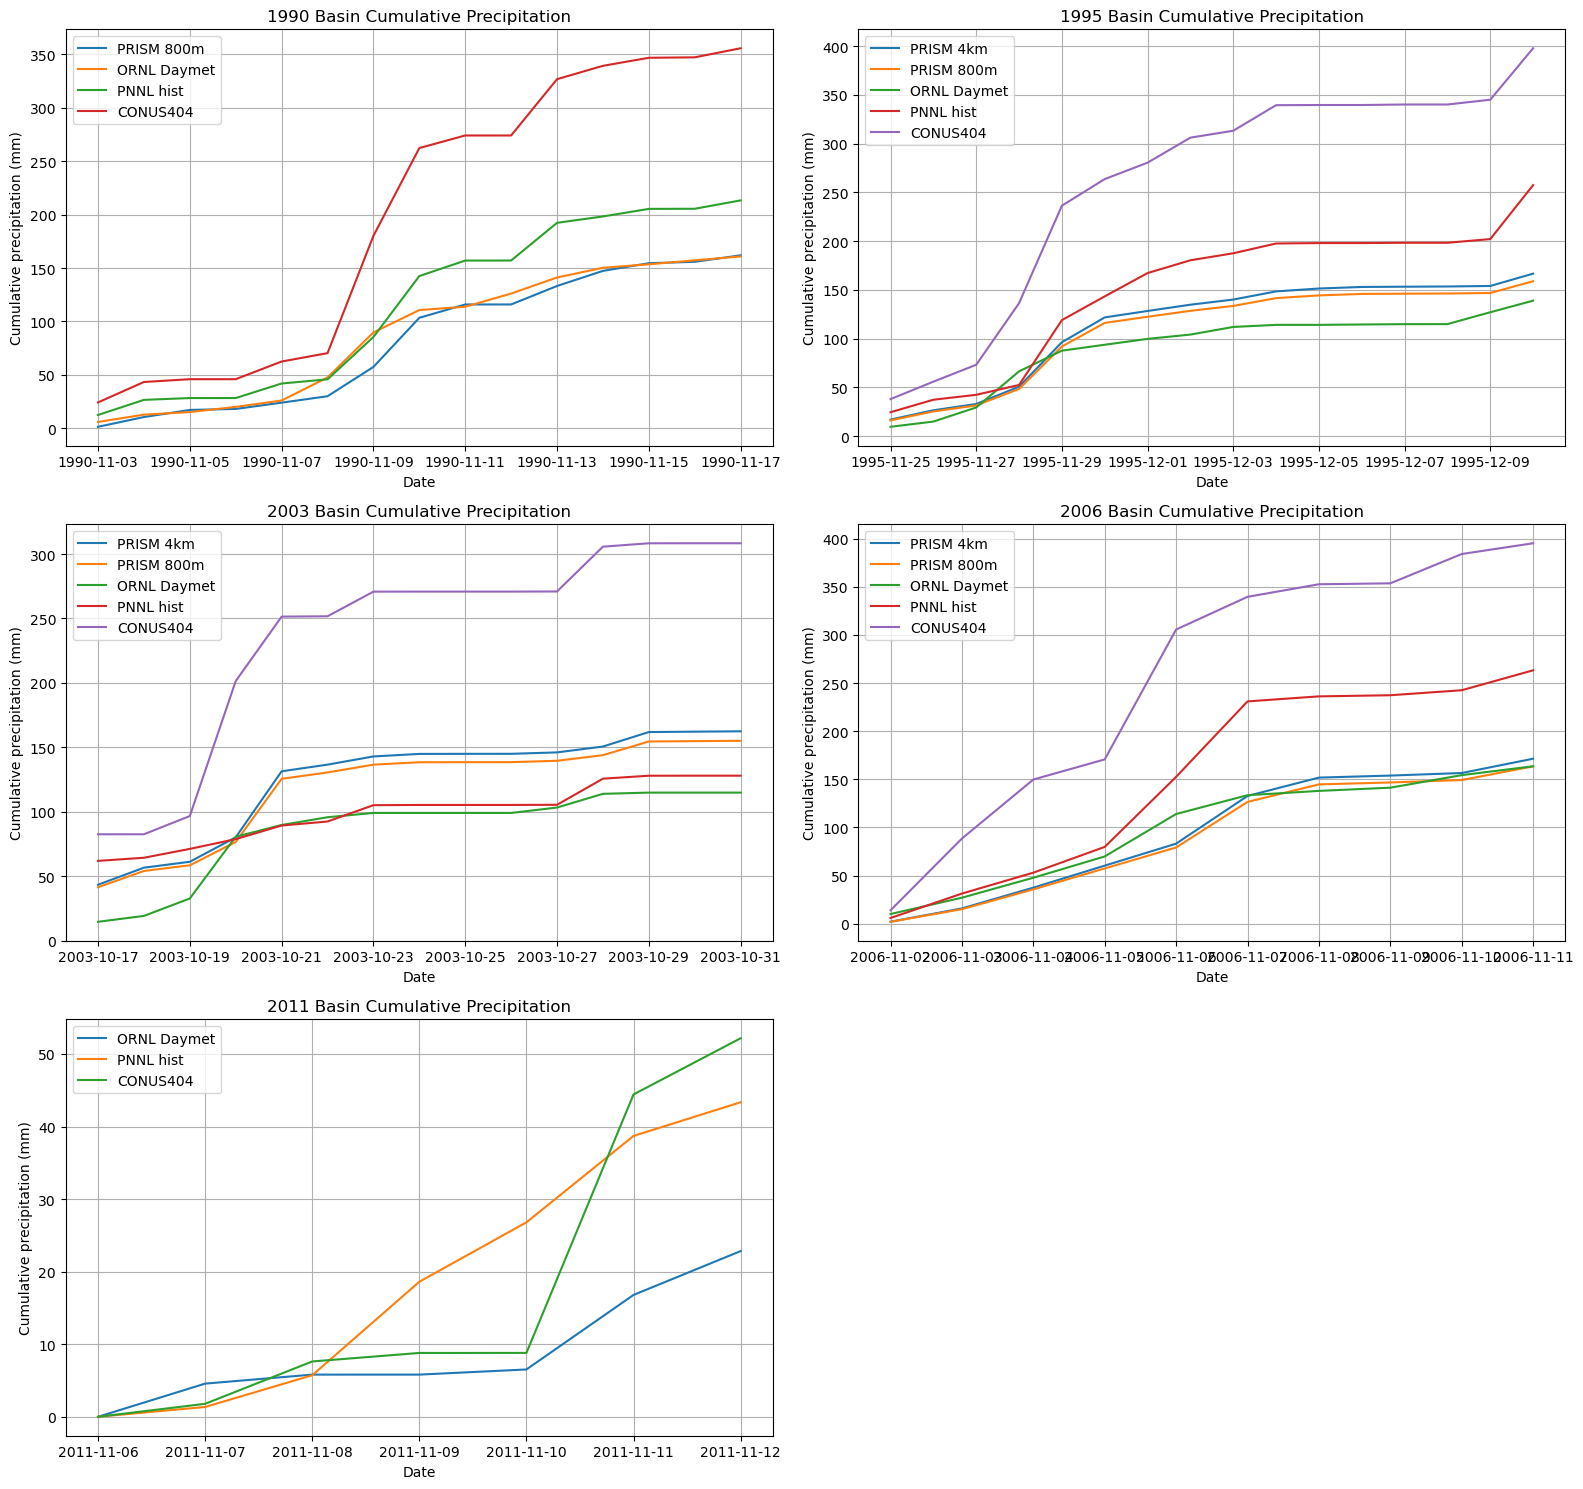

In [ ]:
# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison 
# PRISM (local zarr), ORNL Daymet (local zarr),
# PNNL hist WRF (local netcdf; dims time,x,y; geo from SERDP6km),
# CONUS404 (external OSN), SNOTEL (external)
#
# Outputs: one subplot per event window, cumulative precip (mm)
# Prints: variable units + key diagnostics (PNNL reset handling)
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import requests

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_ORNL_DIR   = BASE / "ornl_nc"
P_PNNL_DIR   = BASE / "PNNL" / "historical"
P_PNNL_GEO   = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"  # has lat/lon on model grid
BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

# External
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

SNOTEL_STATIONS_GEOJSON = (
    "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
)

# ----------------------------
# EVENTS (edit)
# ----------------------------
events = {
    1990: ("1990-11-03", "1990-11-17"),
    1995: ("1995-11-25", "1995-12-10"),
    2003: ("2003-10-17", "2003-10-31"),
    2006: ("2006-11-02", "2006-11-11"),
    2011: ("2011-11-06", "2011-11-12"),
}

# ----------------------------
# HELPERS
# ----------------------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    return gdf.geometry.union_all()

def ensure_daily_sum(da):
    """If sub-daily, sum to daily. If daily already, keep daily totals."""
    if "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return da
    med = pd.Series(t).diff().dt.total_seconds().median()
    if med is not None and med < 23 * 3600:
        return da.resample(time="1D").sum()
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_hourly_increment(bm_cum_like):
    """
    Convert a resetting 'accumulated over window' series to increments:
      inc[t] = diff if diff>=0 else current_value (reset)
    Returns inc aligned to bm_cum_like.time[1:]
    """
    d = bm_cum_like.diff("time")
    curr = bm_cum_like.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def pnnl_to_daily_mm_from_precacc(bm_prec_acc, label="PNNL hist"):
    """
    bm_prec_acc is basin-mean series of PREC_ACC_NC (mm) at hourly steps.
    We MUST treat it as a resetting accumulation -> reset-safe increments -> daily sum.
    """
    bm = bm_prec_acc.dropna("time")
    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = float((d < 0).mean().compute()) if hasattr(d.data, "compute") else float((d < 0).mean())
    mean_raw = float(bm.mean().compute()) if hasattr(bm.data, "compute") else float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean().compute()) if hasattr(d.data, "compute") else float(d.clip(min=0).mean())

    print(f"    [{label}] reset-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")
    inc = reset_safe_hourly_increment(bm)  # robust even if frac_neg is high
    daily = inc.resample(time="1D").sum()
    return daily

# ----------------------------
# MASKS
# ----------------------------
def mask_curvilinear_bool(ds, geom, lon_name="lon", lat_name="lat"):
    """
    Curvilinear grids with 2D lon/lat.
    SAFE: no meshgrid; regionmask.mask(lon2d, lat2d) works with xarray objects.
    """
    region = regionmask.Regions([geom])
    m = region.mask(ds[lon_name], ds[lat_name])  # positional args for regionmask compat
    return ~xr.ufuncs.isnan(m)

def basin_mean_over_dims(da, mask_bool, dims):
    return da.where(mask_bool).mean(dim=dims, skipna=True)

# ----------------------------
# PRISM (exact match only)
# ----------------------------
def find_prism_zarr_exact(start, end, tag):
    s0 = pd.to_datetime(start).strftime("%Y-%m-%d")
    s1 = pd.to_datetime(end).strftime("%Y-%m-%d")
    patt = f"{s0}_{s1}_daily_{tag}_PRISM_data.zarr"
    hits = list(BASE.glob(f"**/{patt}"))
    return hits[0] if hits else None

def load_prism(start, end, tag, geom=None):
    z = find_prism_zarr_exact(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag}: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    # If PRISM zarr is already clipped to basin, mean over spatial dims is fine.
    
    spatial = [d for d in daily.dims if d != "time"]
    bm = daily.mean(dim=spatial, skipna=True)

    ds.close()
    return bm.cumsum("time")

# ----------------------------
# ORNL Daymet
# ----------------------------
def load_ornl(year, start, end):
    z = next(P_ORNL_DIR.glob(f"{year}_{year}_ref_*ORNL_data.zarr"), None)
    if z is None:
        print("  - ORNL Daymet: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["prcp"])
    if var is None:
        print("  - ORNL Daymet: (no prcp var)")
        ds.close()
        return None

    print_units(ds, var, f"ORNL Daymet [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)
    spatial = [d for d in daily.dims if d != "time"]
    bm = daily.mean(dim=spatial, skipna=True)

    ds.close()
    return bm.cumsum("time")

# ----------------------------
# PNNL HIST WRF (dims time,x,y) – geo mask from SERDP6km
# ----------------------------
_PNNL_MASK_XY = None

def build_pnnl_mask_xy(geom):
    """
    Build boolean mask on (x,y) grid for PNNL historic WRF.
    Uses SERDP6km geo file to get lat/lon on same grid.
    """
    geo = xr.open_dataset(P_PNNL_GEO)

    # Try common WRF geo var names
    lat_name = None
    lon_name = None
    for cand in ["XLAT_M", "XLAT", "lat", "LAT"]:
        if cand in geo:
            lat_name = cand
            break
    for cand in ["XLONG_M", "XLONG", "lon", "LON"]:
        if cand in geo:
            lon_name = cand
            break
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:50]}")

    lat = geo[lat_name]
    lon = geo[lon_name]

    # If time-like dim exists, take first
    for d in lat.dims:
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in lon.dims:
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask = ~xr.ufuncs.isnan(m)

    geo.close()

    # Ensure dims named exactly ("x","y") to match PREC_ACC_NC
    # If mask dims are ("south_north","west_east") etc, rename by position.
    if mask.dims != ("x", "y"):
        if len(mask.dims) == 2:
            mask = mask.rename({mask.dims[0]: "x", mask.dims[1]: "y"})
    return mask

def load_pnnl(year, start, end, geom):
    global _PNNL_MASK_XY

    f = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", "PNNL hist")

    if _PNNL_MASK_XY is None:
        _PNNL_MASK_XY = build_pnnl_mask_xy(geom)

    da = ds["PREC_ACC_NC"].sel(time=slice(start, end)).sortby("time")

    # Apply mask in xarray (no numpy broadcast)
    bm = da.where(_PNNL_MASK_XY).mean(dim=("x", "y"), skipna=True)

    # Reset-safe conversion to daily totals
    daily = pnnl_to_daily_mm_from_precacc(bm, label="PNNL hist")
    out = daily.cumsum("time")

    ds.close()
    return out

# ----------------------------
# CONUS404 (external)
# ----------------------------
_conus_ds = None
def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus(start, end, geom):
    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()

    # Prefer actual precip variable if present
    var = pick_var(ds, ["PREC_ACC_NC", "prcp", "precip", "precipitation"])
    if var is None:
        print("  - CONUS404: (no precip var)")
        return None

    print_units(ds, var, "CONUS404")

    # Curvilinear mask (y,x) without meshgrid
    mask2d = mask_curvilinear_bool(ds, geom, lon_name="lon", lat_name="lat")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    # Basin mean over (y,x)
    bm = basin_mean_over_dims(daily, mask2d, dims=("y", "x"))

    return bm.cumsum("time")

# ----------------------------
# SNOTEL (external)
# ----------------------------
def load_snotel(start, end, geom):
    stations = gpd.read_file(SNOTEL_STATIONS_GEOJSON).to_crs("EPSG:4326")
    basin = gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")
    sel = gpd.sjoin(stations, basin, predicate="intersects", how="inner")

    if sel.empty:
        print("  - SNOTEL: no stations intersect basin")
        return None

    # Try to find a station triplet column
    cand_cols = ["triplet", "stationTriplet", "station_triplet", "awdbTriplet", "awdb_triplet"]
    triplet_col = next((c for c in cand_cols if c in sel.columns), None)

    if triplet_col is None:
        # Print columns so we can map properly later
        print("  - SNOTEL: triplet field not found in GeoJSON.")
        print("    Available columns:", list(sel.columns))
        return None

    triplets = sel[triplet_col].dropna().astype(str).unique().tolist()
    triplets = sorted(set(triplets))
    if not triplets:
        print("  - SNOTEL: no valid triplets")
        return None

    # AWDB daily data: PRCPSA (precip since midnight, inches)
    url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data/getDaily"
    params = {
        "stationTriplets": ",".join(triplets),
        "elements": "PRCPSA",
        "beginDate": start,
        "endDate": end,
        "format": "json",
    }
    rr = requests.get(url, params=params, timeout=120)
    rr.raise_for_status()
    js = rr.json()

    data = {}
    for st in js:
        trip = st.get("stationTriplet")
        vals = st.get("values", [])
        if not trip or not vals:
            continue
        s = {pd.to_datetime(v["date"]): (np.nan if v["value"] is None else float(v["value"])) for v in vals}
        data[trip] = pd.Series(s)

    if not data:
        print("  - SNOTEL: AWDB returned no data")
        return None

    df_in = pd.DataFrame(data).sort_index()
    print("  - SNOTEL: var='PRCPSA', units='inches → mm'")
    df_mm = df_in * 25.4

    daily_mean = df_mm.mean(axis=1, skipna=True).loc[pd.to_datetime(start):pd.to_datetime(end)].asfreq("D")

    da = xr.DataArray(
        daily_mean.cumsum().values,
        coords={"time": daily_mean.index},
        dims=("time",),
        name="SNOTEL"
    )
    return da

# ----------------------------
# MAIN
# ----------------------------
def main():
    geom = load_basin_geom()

    n = len(events)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axs = np.array(axs).reshape(-1)

    for i, (yr, (start, end)) in enumerate(events.items()):
        ax = axs[i]
        print(f"\n================ {yr} ({start} → {end}) ================")

        series = [
            ("PRISM 4km",    load_prism(start, end, "4km", geom=geom)),
            ("PRISM 800m",   load_prism(start, end, "800m", geom=geom)),
            ("ORNL Daymet",  load_ornl(yr, start, end)),
            ("PNNL hist",    load_pnnl(yr, start, end, geom)),
            ("CONUS404",     load_conus(start, end, geom)),
            ("SNOTEL",       load_snotel(start, end, geom)),
        ]

        for label, da in series:
            if is_plottable_1d(da):
                ax.plot(pd.to_datetime(da["time"].values), da.values, label=label)

        ax.set_title(f"{yr} Basin Cumulative Precipitation")
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative precipitation (mm)")
        ax.grid(True)
        ax.legend()

    # delete unused axes
    for j in range(len(events), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()



================ 1990 (1990-11-03 → 1990-11-17) ================
  - PRISM 4km: (no precip var found)
  - PRISM 800m [1990-11-03_1990-11-17_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'
  - ORNL Daymet [1990_1990_ref_DaymetV4_ORNL_data.zarr]: var='prcp', units='mm/day'
  - PNNL hist: var='PREC_ACC_NC', units='mm'
    [PNNL hist] accum-check: frac_neg=0.499, mean_raw=1.004, mean_diff_pos=0.08857
  - CONUS404: var='PREC_ACC_NC', units='mm'
    [CONUS404 accum] accum-check: frac_neg=0.714, mean_raw=23.72, mean_diff_pos=12.81
  - SNOTEL: triplet field not found in GeoJSON
    Available columns: ['code', 'name', 'network', 'elevation_m', 'latitude', 'longitude', 'state', 'HUC', 'mgrs', 'mountainRange', 'beginDate', 'endDate', 'csvData', 'geometry', 'index_right']

================ 1995 (1995-11-25 → 1995-12-10) ================
  - PRISM 4km [1995-11-25_1995-12-10_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'
  - PRISM 800m [1995-11-25_1995-12-10_daily_800m_PRISM_dat

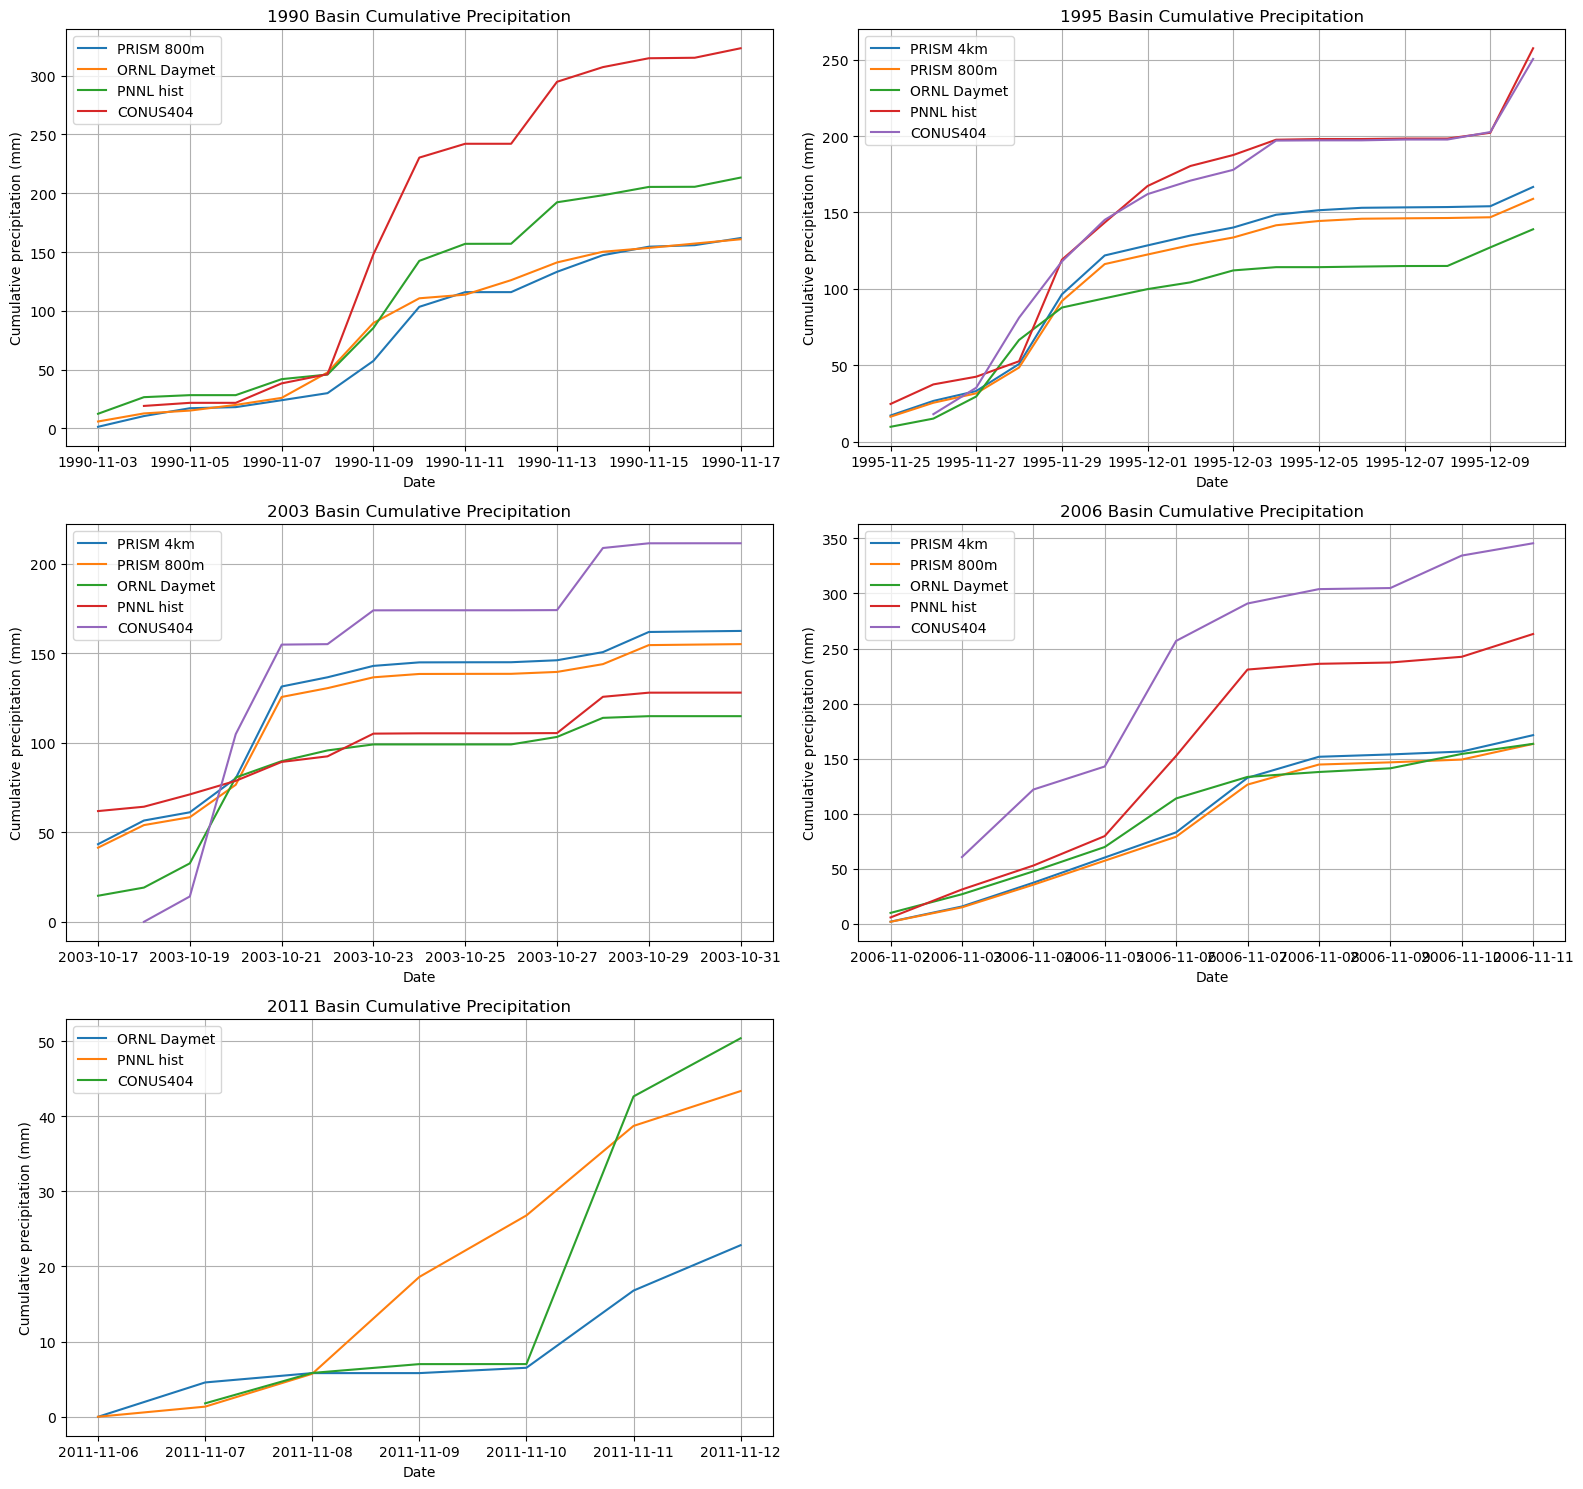

In [ ]:
# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison
# PRISM (local zarr), ORNL Daymet (local zarr),
# PNNL hist WRF (local netcdf; dims time,x,y; geo from SERDP6km),
# CONUS404 (external OSN), SNOTEL (external)
#
# Outputs: one subplot per event window, cumulative precip (mm)
# Prints: variable units + key diagnostics (accum handling)
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import requests

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_PRISM_DIR  = BASE / "prism_nc"
P_ORNL_DIR   = BASE / "ornl_nc"
P_PNNL_DIR   = BASE / "PNNL" / "historical"
P_PNNL_GEO   = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"
BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

# External
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

SNOTEL_STATIONS_GEOJSON = (
    "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
)

# ----------------------------
# EVENTS
# ----------------------------
events = {
    1990: ("1990-11-03", "1990-11-17"),
    1995: ("1995-11-25", "1995-12-10"),
    2003: ("2003-10-17", "2003-10-31"),
    2006: ("2006-11-02", "2006-11-11"),
    2011: ("2011-11-06", "2011-11-12"),
}

# ----------------------------
# HELPERS
# ----------------------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    return gdf.geometry.union_all()

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    """Sum to daily totals (safe for both hourly and daily)."""
    if "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    # If sub-daily or daily, summing to daily is correct for precip totals
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_increment(acc_like_1d):
    """
    Reset-safe increments for an accumulated series (1D time):
      inc[t] = diff if diff>=0 else current_value (reset)
    Output aligns to time[1:].
    """
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    """
    Convert accumulated precip (mm) -> increments (mm/step) -> daily totals (mm/day).
    acc_like_1d MUST be 1D (time).
    """
    bm = acc_like_1d

    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    # light diagnostics (safe; 1D)
    frac_neg = float((d < 0).mean())
    mean_raw = float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean())
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)       # 1D time
    daily = ensure_daily_sum(inc)        # daily totals
    return daily

# ----------------------------
# MASKS
# ----------------------------
def mask_curvilinear_bool(ds, geom, lon_name="lon", lat_name="lat"):
    """
    Curvilinear grids with 2D lon/lat.
    SAFE: no meshgrid, no .values.
    """
    region = regionmask.Regions([geom])
    m = region.mask(ds[lon_name], ds[lat_name])  # positional args for compat
    return ~xr.ufuncs.isnan(m)

# ----------------------------
# PRISM (exact match only)
# ----------------------------
def find_prism_zarr_exact(start, end, tag):
    s0 = pd.to_datetime(start).strftime("%Y-%m-%d")
    s1 = pd.to_datetime(end).strftime("%Y-%m-%d")
    patt = f"{s0}_{s1}_daily_{tag}_PRISM_data.zarr"
    hits = sorted(P_PRISM_DIR.glob(patt))
    return hits[0] if hits else None

def load_prism(start, end, tag):
    z = find_prism_zarr_exact(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag}: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm = daily.mean(dim=spatial, skipna=True)

    ds.close()
    return bm.cumsum("time")

# ----------------------------
# ORNL Daymet
# ----------------------------
def load_ornl(year, start, end):
    z = next(P_ORNL_DIR.glob(f"{year}_{year}_ref_*ORNL_data.zarr"), None)
    if z is None:
        print("  - ORNL Daymet: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["prcp"])
    if var is None:
        print("  - ORNL Daymet: (no prcp var)")
        ds.close()
        return None

    print_units(ds, var, f"ORNL Daymet [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm = daily.mean(dim=spatial, skipna=True)

    ds.close()
    return bm.cumsum("time")

# ----------------------------
# PNNL HIST WRF (dims time,x,y) – SAFE MASK BUILD
# ----------------------------
_PNNL_MASK_XY = None
_PNNL_MASK_KEY = None

def build_pnnl_mask_for_ds(ds_prec, geom):
    """
    Build a boolean mask that matches ds_prec PREC_ACC_NC spatial dims exactly.
    This avoids xarray alignment broadcasting (the source of your TiB crash).
    """
    # Spatial dims in the precip file 
    spatial = [d for d in ds_prec["PREC_ACC_NC"].dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = ds_prec.sizes[d0], ds_prec.sizes[d1]

    geo = xr.open_dataset(P_PNNL_GEO)

    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat = geo[lat_name]
    lon = geo[lon_name]

    # squeeze any time-like dim
    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    # regionmask mask on the geo grid
    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)

    # Convert to plain numpy boolean (small: ~450x450) to drop coords safely
    mask_np = np.asarray(mask_geo.data).astype(bool)
    geo.close()

    # Now enforce shape matches precip spatial grid.
    # Some files are (south_north, west_east) vs (x,y) ordering – handle transpose.
    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[PNNL] Mask shape {mask_np.shape} does not match precip grid "
            f"({d0},{d1})={(s0,s1)}"
        )

    # Return a coordinate-free DataArray with EXACT dims (prevents alignment broadcast)
    return xr.DataArray(mask_np, dims=(d0, d1))

def load_pnnl(year, start, end, geom):
    global _PNNL_MASK_XY, _PNNL_MASK_KEY

    f = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", "PNNL hist")

    # Build mask keyed by grid shape + dim names 
    spatial = [d for d in ds["PREC_ACC_NC"].dims if d != "time"]
    key = (tuple(spatial), ds.sizes[spatial[0]], ds.sizes[spatial[1]])
    if (_PNNL_MASK_XY is None) or (_PNNL_MASK_KEY != key):
        _PNNL_MASK_XY = build_pnnl_mask_for_ds(ds, geom)
        _PNNL_MASK_KEY = key

    da = ds["PREC_ACC_NC"].sel(time=slice(start, end)).sortby("time")

    # This is now SAFE: mask dims match da spatial dims exactly - NO broadcasting
    bm_acc = da.where(_PNNL_MASK_XY).mean(dim=spatial, skipna=True)

    # Convert accumulated - daily totals
    daily = accumulated_to_daily_mm(bm_acc, label="PNNL hist")
    out = daily.cumsum("time")

    ds.close()
    return out

# ----------------------------
# CONUS404 (external)
# ----------------------------
_conus_ds = None
_conus_mask = None

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus(start, end, geom):
    global _conus_mask

    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()

    var = pick_var(ds, [
        "prcp", "precip", "precipitation", "PREC", "PRECIP",
        "RAIN", "RAINNC", "RAINC",
        "PREC_ACC_NC"
    ])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    if _conus_mask is None:
        _conus_mask = mask_curvilinear_bool(ds, geom, lon_name="lon", lat_name="lat")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    bm = da.where(_conus_mask).mean(dim=("y", "x"), skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = ("accum" in var.lower()) or ("accumul" in desc) or (var.upper() in ("RAINNC", "RAINC", "PREC_ACC_NC"))
    if looks_accum:
        daily = accumulated_to_daily_mm(bm, label="CONUS404 accum")
    else:
        daily = ensure_daily_sum(bm)

    return daily.cumsum("time")

# ----------------------------
# SNOTEL (external)
# ----------------------------
def load_snotel(start, end, geom):
    stations = gpd.read_file(SNOTEL_STATIONS_GEOJSON).to_crs("EPSG:4326")
    basin = gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")
    sel = gpd.sjoin(stations, basin, predicate="intersects", how="inner")

    if sel.empty:
        print("  - SNOTEL: no stations in basin")
        return None

    triplet_col = None
    for c in sel.columns:
        if "triplet" in str(c).lower():
            triplet_col = c
            break

    if triplet_col is None:
        print("  - SNOTEL: triplet field not found in GeoJSON")
        print("    Available columns:", list(sel.columns))
        return None

    triplets = sorted(set(sel[triplet_col].dropna().astype(str).tolist()))
    if not triplets:
        print("  - SNOTEL: no valid triplets")
        return None

    url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data/getDaily"
    params = {
        "stationTriplets": ",".join(triplets),
        "elements": "PRCPSA",
        "beginDate": start,
        "endDate": end,
        "format": "json",
    }
    rr = requests.get(url, params=params, timeout=120)
    rr.raise_for_status()
    js = rr.json()

    data = {}
    for st in js:
        trip = st.get("stationTriplet")
        vals = st.get("values", [])
        if not trip or not vals:
            continue
        s = {pd.to_datetime(v["date"]): (np.nan if v["value"] is None else float(v["value"])) for v in vals}
        data[trip] = pd.Series(s)

    if not data:
        print("  - SNOTEL: AWDB returned no data")
        return None

    df_in = pd.DataFrame(data).sort_index()
    print(f"  - SNOTEL: var='PRCPSA', units='inches → mm', stations={df_in.shape[1]}")

    df_mm = df_in * 25.4
    daily_mean = df_mm.mean(axis=1, skipna=True).loc[pd.to_datetime(start):pd.to_datetime(end)].asfreq("D")

    return xr.DataArray(
        daily_mean.cumsum().values,
        coords={"time": daily_mean.index},
        dims=("time",),
        name="SNOTEL",
    )

# ----------------------------
# MAIN
# ----------------------------
def main():
    geom = load_basin_geom()

    n = len(events)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axs = np.array(axs).reshape(-1)

    for i, (yr, (start, end)) in enumerate(events.items()):
        ax = axs[i]
        print(f"\n================ {yr} ({start} → {end}) ================")

        series = [
            ("PRISM 4km",    load_prism(start, end, "4km")),
            ("PRISM 800m",   load_prism(start, end, "800m")),
            ("ORNL Daymet",  load_ornl(yr, start, end)),
            ("PNNL hist",    load_pnnl(yr, start, end, geom)),
            ("CONUS404",     load_conus(start, end, geom)),
            ("SNOTEL",       load_snotel(start, end, geom)),
        ]

        plotted_any = False
        for label, da in series:
            if is_plottable_1d(da):
                ax.plot(pd.to_datetime(da["time"].values), da.values, label=label)
                plotted_any = True

        ax.set_title(f"{yr} Basin Cumulative Precipitation")
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative precipitation (mm)")
        ax.grid(True)
        if plotted_any:
            ax.legend()

    for j in range(len(events), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()



================ 1990 (1990-11-03 → 1990-11-17) ================
  - PRISM 4km: (no precip var found)
  - PRISM 800m [1990-11-03_1990-11-17_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 800m =====
  median dt (hours): 24.00

[PRISM 800m] DAILY CHECK
  min: 0.015709754079580307
  max: 46.002017974853516
  mean: 10.795679092407227
  sum: 161.9351806640625
  CHECK: daily.sum vs cum[-1]: 161.9351806640625 161.9351806640625  | diff: 0.0
  TOP 5 daily values:
    1990-11-10 46.002017974853516
    1990-11-09 27.435359954833984
    1990-11-13 17.281404495239258
    1990-11-14 14.143548011779785
    1990-11-11 12.484274864196777
  - ORNL Daymet [1990_1990_ref_DaymetV4_ORNL_data.zarr]: var='prcp', units='mm/day'

===== VERIFY: ORNL Daymet =====
  median dt (hours): 24.00

[ORNL Daymet] DAILY CHECK
  min: 2.4080331325531006
  max: 42.135520935058594
  mean: 10.724541664123535
  sum: 160.8681182861328
  CHECK: daily.sum vs cum[-1]: 160.8681182861328 160.8681182861

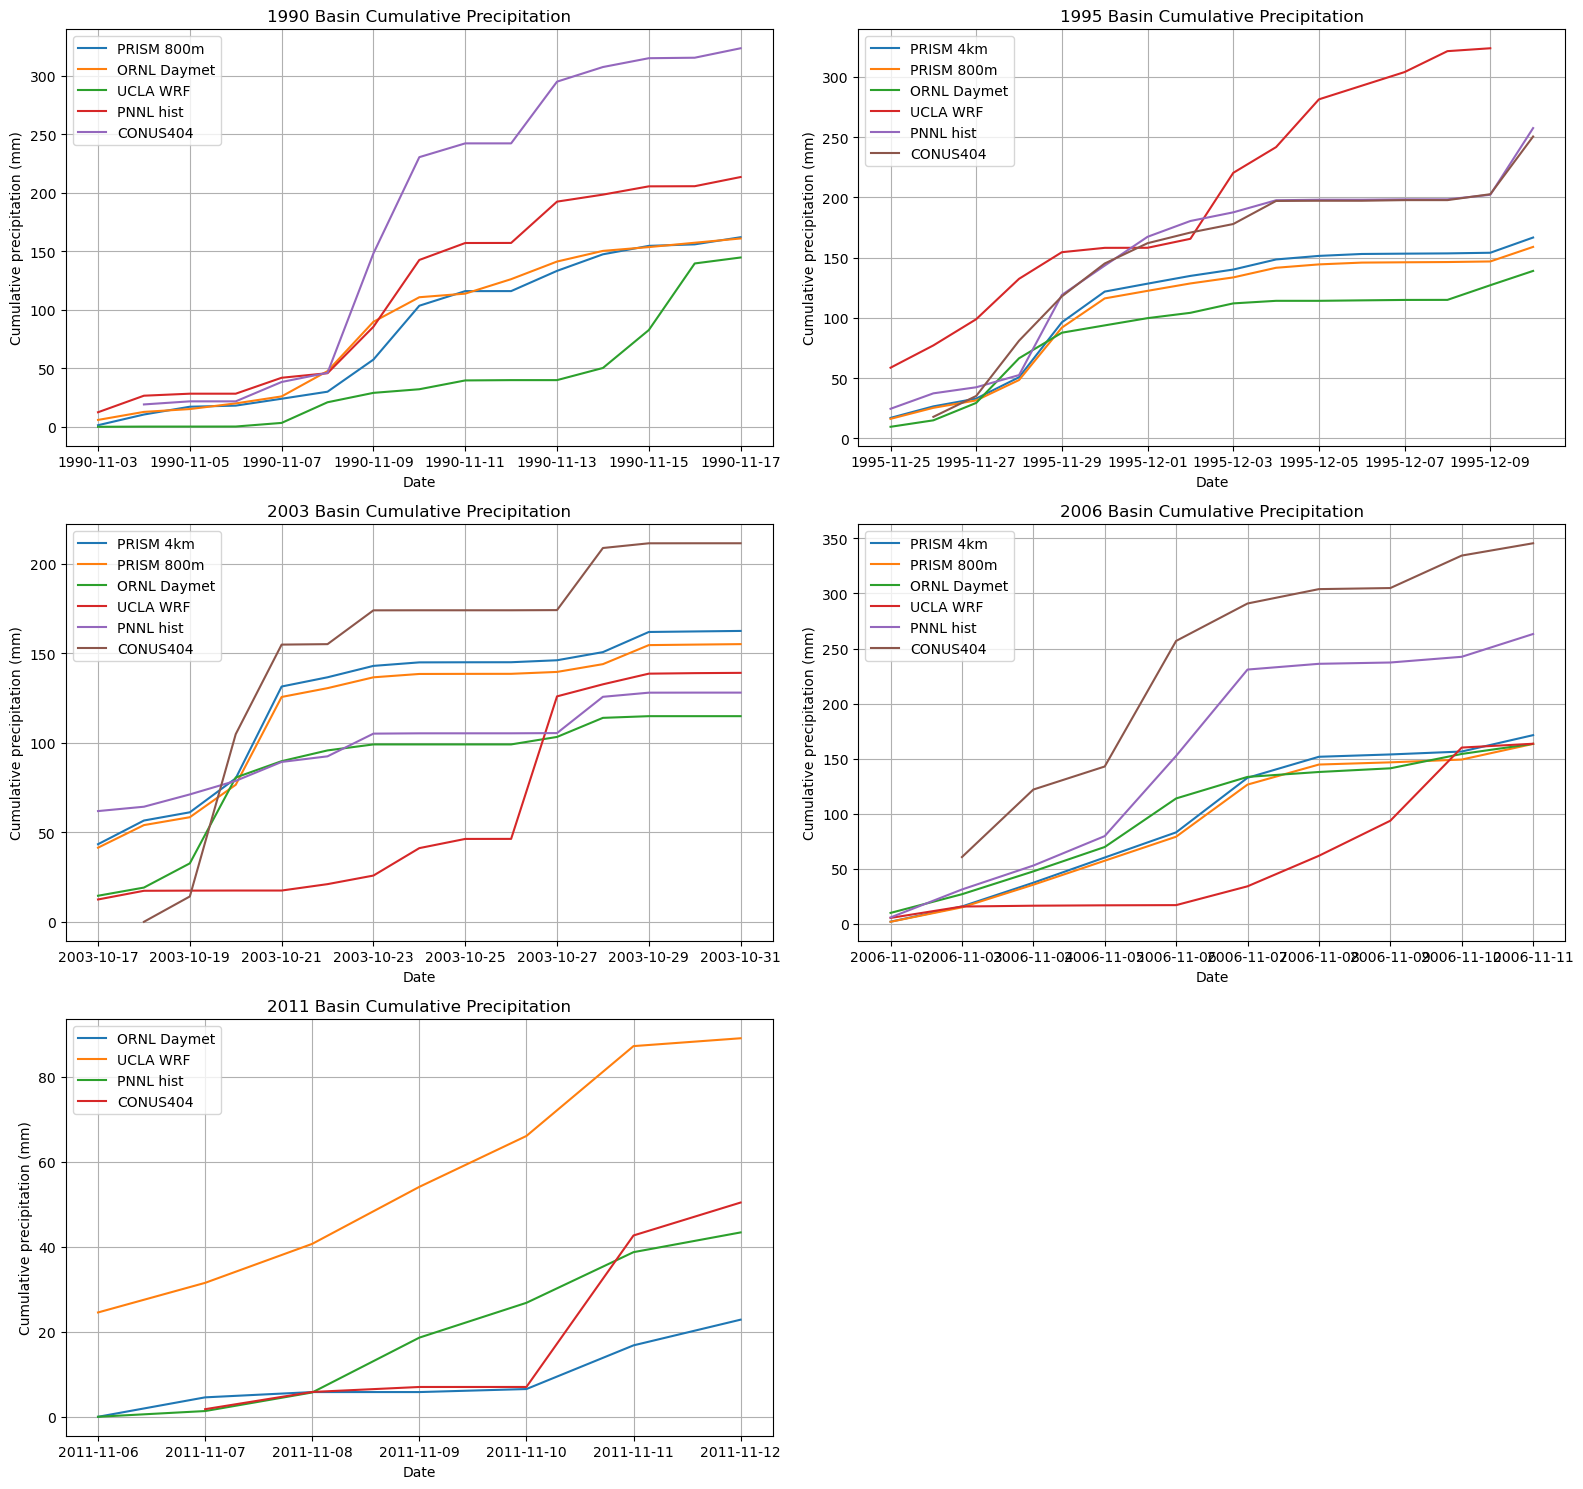

In [ ]:

# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison + VERIFICATION
# PRISM (local zarr), ORNL Daymet (local zarr),
# UCLA WRF outputs (local zarr; your ucla_wrf_outputs naming),
# PNNL hist WRF (local netcdf; dims time,x,y; geo from SERDP6km),
# CONUS404 (external OSN), SNOTEL (external)
#
# Outputs: one subplot per event window, cumulative precip (mm)
# Prints: variable units + key diagnostics (accum handling)
# Adds: verification prints for daily series + mass-balance checks
#
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import requests

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_PRISM_DIR  = BASE / "prism_nc"
P_ORNL_DIR   = BASE / "ornl_nc"

# UCLA outputs
P_UCLA_DIR   = BASE / "ucla_wrf_outputs"

P_PNNL_DIR   = BASE / "PNNL" / "historical"
P_PNNL_GEO   = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"
BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

# External
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

SNOTEL_STATIONS_GEOJSON = (
    "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
)

# ----------------------------
# EVENTS
# ----------------------------
events = {
    1990: ("1990-11-03", "1990-11-17"),
    1995: ("1995-11-25", "1995-12-10"),
    2003: ("2003-10-17", "2003-10-31"),
    2006: ("2006-11-02", "2006-11-11"),
    2011: ("2011-11-06", "2011-11-12"),
}

# ----------------------------
# HELPERS
# ----------------------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    return gdf.geometry.union_all()

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    """Sum to daily totals (safe for both hourly and daily)."""
    if "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_increment(acc_like_1d):
    """
    Reset-safe increments for an accumulated series (1D time):
      inc[t] = diff if diff>=0 else current_value (reset)
    Output aligns to time[1:].
    """
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    """
    Convert accumulated precip (mm) -> increments (mm/step) -> daily totals (mm/day).
    acc_like_1d MUST be 1D (time).
    """
    bm = acc_like_1d
    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = float((d < 0).mean())
    mean_raw = float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean())
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)
    daily = ensure_daily_sum(inc)
    return daily

# ----------------------------
# VERIFICATION
# ----------------------------
def debug_daily(label, daily_da):
    """Print distribution stats for a DAILY (mm/day) 1D time series."""
    if daily_da is None or "time" not in daily_da.dims or daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (empty)")
        return
    daily_da = daily_da.dropna("time")
    if daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (all NaN)")
        return
    print(f"\n[{label}] DAILY CHECK")
    print("  min:", float(daily_da.min()))
    print("  max:", float(daily_da.max()))
    print("  mean:", float(daily_da.mean()))
    print("  sum:", float(daily_da.sum()))

def _median_dt_hours_from_da(da):
    if da is None or "time" not in da.dims:
        return None
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return None
    dt_hours = pd.Series(t).diff().dt.total_seconds().dropna().median() / 3600.0
    return float(dt_hours) if pd.notnull(dt_hours) else None

def verify_daily_and_cumsum(label, daily_da, cum_da=None, top_n=5):
    """
    Verifies:
      - dt sanity
      - daily stats
      - sum(daily) == last(cumsum) (if cum passed)
      - top-N daily increments (helps spot unit/var issues)
    """
    if daily_da is None or daily_da.size == 0:
        print(f"\n===== VERIFY: {label} =====")
        print("  (no data)")
        return

    daily_da = daily_da.dropna("time").sortby("time")
    print(f"\n===== VERIFY: {label} =====")
    dt_hours = _median_dt_hours_from_da(daily_da)
    if dt_hours is not None:
        print(f"  median dt (hours): {dt_hours:.2f}")

    debug_daily(label, daily_da)

    # mass balance with cumsum if provided
    if cum_da is not None and is_plottable_1d(cum_da):
        try:
            cum_last = float(cum_da.dropna("time").isel(time=-1))
            daily_sum = float(daily_da.sum())
            print("  CHECK: daily.sum vs cum[-1]:", daily_sum, cum_last, " | diff:", daily_sum - cum_last)
        except Exception as e:
            print("  CHECK: daily.sum vs cum[-1]: (failed)", repr(e))

    # top N days
    try:
        top = daily_da.sortby(daily_da, ascending=False).isel(time=slice(0, min(top_n, daily_da.size)))
        print(f"  TOP {min(top_n, daily_da.size)} daily values:")
        for tt, vv in zip(pd.to_datetime(top["time"].values), np.asarray(top.values)):
            print("   ", tt.date(), float(vv))
    except Exception as e:
        print("  TOP daily values: (failed)", repr(e))

# ----------------------------
# MASKS
# ----------------------------
def mask_curvilinear_bool(ds, geom, lon_name="lon", lat_name="lat"):
    """
    Curvilinear grids with 2D lon/lat.
    SAFE: no meshgrid, no .values.
    """
    region = regionmask.Regions([geom])
    m = region.mask(ds[lon_name], ds[lat_name])  # positional args for compat
    return ~xr.ufuncs.isnan(m)

def _infer_lonlat_vars(ds):
    """
    Find lon/lat arrays in either coords or data_vars.
    Works for typical WRF outputs (XLONG/XLAT) and also lon/lat.
    Returns (lon_da, lat_da) or (None, None).
    """
    lon_candidates = ["lon", "longitude", "XLONG", "XLONG_M", "LON", "xlong", "xlong_m"]
    lat_candidates = ["lat", "latitude",  "XLAT",  "XLAT_M",  "LAT", "xlat",  "xlat_m"]

    def _get(name):
        if name in ds.coords:
            return ds.coords[name]
        if name in ds.data_vars:
            return ds.data_vars[name]
        return None

    lon = None
    lat = None
    for n in lon_candidates:
        lon = _get(n)
        if lon is not None:
            break
    for n in lat_candidates:
        lat = _get(n)
        if lat is not None:
            break

    if lon is None or lat is None:
        return None, None

    # squeeze any time-like dim if present (WRF often has Time)
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})
    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})

    return lon, lat

# ----------------------------
# PRISM (exact match only)
# ----------------------------
def find_prism_zarr_exact(start, end, tag):
    s0 = pd.to_datetime(start).strftime("%Y-%m-%d")
    s1 = pd.to_datetime(end).strftime("%Y-%m-%d")
    patt = f"{s0}_{s1}_daily_{tag}_PRISM_data.zarr"
    hits = sorted(P_PRISM_DIR.glob(patt))
    return hits[0] if hits else None

def load_prism(start, end, tag, do_verify=True):
    z = find_prism_zarr_exact(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag}: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm_daily = daily.mean(dim=spatial, skipna=True)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum(f"PRISM {tag}", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# ORNL Daymet
# ----------------------------
def load_ornl(year, start, end, do_verify=True):
    z = next(P_ORNL_DIR.glob(f"{year}_{year}_ref_*ORNL_data.zarr"), None)
    if z is None:
        print("  - ORNL Daymet: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["prcp"])
    if var is None:
        print("  - ORNL Daymet: (no prcp var)")
        ds.close()
        return None

    print_units(ds, var, f"ORNL Daymet [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm_daily = daily.mean(dim=spatial, skipna=True)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("ORNL Daymet", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# UCLA WRF OUTPUTS 
# ----------------------------
_UCLA_MASK = None
_UCLA_MASK_KEY = None

def _parse_ucla_event_zarr_name(p: Path):
    """
    Expected patterns:
      {start}_{end}_wrf_cesm2_r11i1p1f1_historical_data.zarr
      {start}_{end}_wrf_cesm2_r11i1p1f1_ssp245_data.zarr
    """
    name = p.name
    if not name.endswith(".zarr"):
        return None, None, None
    parts = name.split("_")
    if len(parts) < 3:
        return None, None, None
    try:
        s0 = pd.to_datetime(parts[0])
        s1 = pd.to_datetime(parts[1])
    except Exception:
        return None, None, None

    scenario = "historical" if "historical" in name else ("ssp245" if "ssp245" in name else "unknown")
    return s0, s1, scenario

def find_ucla_zarr_event(start, end):
    """
    Finder for UCLA event zarrs.
    Allows end-date mismatch ±2 days (e.g., 1995 file ends 12-09).
    """
    if not P_UCLA_DIR.exists():
        return None

    s0 = pd.to_datetime(start)
    s1 = pd.to_datetime(end)

    exact = P_UCLA_DIR / f"{s0:%Y-%m-%d}_{s1:%Y-%m-%d}_wrf_cesm2_r11i1p1f1_historical_data.zarr"
    if exact.exists():
        return exact

    exact_ssp = P_UCLA_DIR / f"{s0:%Y-%m-%d}_{s1:%Y-%m-%d}_wrf_cesm2_r11i1p1f1_ssp245_data.zarr"
    if exact_ssp.exists():
        return exact_ssp

    candidates = sorted(P_UCLA_DIR.glob(f"{s0:%Y-%m-%d}_*_wrf_cesm2_r11i1p1f1_*_data.zarr"))
    if not candidates:
        candidates = sorted(P_UCLA_DIR.glob(f"{s0:%Y-%m-%d}_*_wrf_*_data.zarr"))

    best = None
    best_score = None
    for p in candidates:
        c0, c1, _scen = _parse_ucla_event_zarr_name(p)
        if c0 is None:
            continue
        if c0.normalize() != s0.normalize():
            continue
        score = abs((c1.normalize() - s1.normalize()).days)
        if best is None or score < best_score:
            best = p
            best_score = score

    if best is not None and best_score is not None and best_score <= 2:
        return best
    return None

def build_ucla_mask_for_da(da_precip, ds_ucla, geom):
    spatial = [d for d in da_precip.dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[UCLA] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = da_precip.sizes[d0], da_precip.sizes[d1]

    lon, lat = _infer_lonlat_vars(ds_ucla)
    if lon is None or lat is None:
        raise RuntimeError("[UCLA] Could not infer lon/lat arrays")

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)

    mask_np = np.asarray(mask_geo.data).astype(bool)

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[UCLA] Mask shape {mask_np.shape} does not match precip grid "
            f"({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_ucla(start, end, geom, do_verify=True):
    global _UCLA_MASK, _UCLA_MASK_KEY

    z = find_ucla_zarr_event(start, end)
    if z is None:
        print("  - UCLA WRF: (not available)")
        return None

    ds = safe_open_zarr(z)

    var = pick_var(ds, ["PREC_ACC_NC", "RAINNC", "RAINC", "RAIN", "prcp", "precip", "precipitation", "ppt"])
    if var is None:
        print(f"  - UCLA WRF [{z.name}]: (no precip var found)")
        print(f"    data_vars (first 60): {list(ds.data_vars)[:60]}")
        ds.close()
        return None

    print_units(ds, var, f"UCLA WRF [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    spatial = [d for d in da.dims if d != "time"]

    key = (z.as_posix(), var, tuple(spatial), da.sizes[spatial[0]], da.sizes[spatial[1]])
    if (_UCLA_MASK is None) or (_UCLA_MASK_KEY != key):
        _UCLA_MASK = build_ucla_mask_for_da(da, ds, geom)
        _UCLA_MASK_KEY = key

    bm = da.where(_UCLA_MASK).mean(dim=spatial, skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = (
        ("accum" in var.lower()) or ("accumul" in desc) or
        (var.upper() in ("RAINNC", "RAINC", "RAIN", "PREC_ACC_NC"))
    )
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label="UCLA WRF accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("UCLA WRF", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# PNNL HIST WRF (dims time,x,y) – SAFE MASK BUILD
# ----------------------------
_PNNL_MASK_XY = None
_PNNL_MASK_KEY = None

def build_pnnl_mask_for_ds(ds_prec, geom):
    spatial = [d for d in ds_prec["PREC_ACC_NC"].dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = ds_prec.sizes[d0], ds_prec.sizes[d1]

    geo = xr.open_dataset(P_PNNL_GEO)

    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat = geo[lat_name]
    lon = geo[lon_name]

    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)

    mask_np = np.asarray(mask_geo.data).astype(bool)
    geo.close()

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[PNNL] Mask shape {mask_np.shape} does not match precip grid "
            f"({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_pnnl(year, start, end, geom, do_verify=True):
    global _PNNL_MASK_XY, _PNNL_MASK_KEY

    f = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", "PNNL hist")

    spatial = [d for d in ds["PREC_ACC_NC"].dims if d != "time"]
    key = (tuple(spatial), ds.sizes[spatial[0]], ds.sizes[spatial[1]])
    if (_PNNL_MASK_XY is None) or (_PNNL_MASK_KEY != key):
        _PNNL_MASK_XY = build_pnnl_mask_for_ds(ds, geom)
        _PNNL_MASK_KEY = key

    da = ds["PREC_ACC_NC"].sel(time=slice(start, end)).sortby("time")
    bm_acc = da.where(_PNNL_MASK_XY).mean(dim=spatial, skipna=True)

    bm_daily = accumulated_to_daily_mm(bm_acc, label="PNNL hist")
    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("PNNL hist", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# CONUS404 (external)
# ----------------------------
_conus_ds = None
_conus_mask = None

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus(start, end, geom, do_verify=True):
    global _conus_mask

    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()

    var = pick_var(ds, [
        "prcp", "precip", "precipitation", "PREC", "PRECIP",
        "RAIN", "RAINNC", "RAINC",
        "PREC_ACC_NC"
    ])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    if _conus_mask is None:
        _conus_mask = mask_curvilinear_bool(ds, geom, lon_name="lon", lat_name="lat")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    bm = da.where(_conus_mask).mean(dim=("y", "x"), skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = ("accum" in var.lower()) or ("accumul" in desc) or (var.upper() in ("RAINNC", "RAINC", "PREC_ACC_NC"))
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label="CONUS404 accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("CONUS404", bm_daily, cum)

    return cum

# ----------------------------
# SNOTEL (external)
# ----------------------------
def load_snotel(start, end, geom, do_verify=True):
    """
    Uses the GeoJSON's 'code' field as stationTriplet (your GeoJSON does NOT expose 'triplet').
    AWDB endpoint can be flaky; this function fails soft (prints error and returns None).
    """
    stations = gpd.read_file(SNOTEL_STATIONS_GEOJSON).to_crs("EPSG:4326")
    basin = gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")
    sel = gpd.sjoin(stations, basin, predicate="intersects", how="inner")

    if sel.empty:
        print("  - SNOTEL: no stations in basin")
        return None

    if "code" not in sel.columns:
        print("  - SNOTEL: expected 'code' column not found")
        print("    Available columns:", list(sel.columns))
        return None

    triplets = sorted(set(sel["code"].dropna().astype(str).tolist()))
    if not triplets:
        print("  - SNOTEL: no valid station triplets")
        return None

    url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data/getDaily"
    params = {
        "stationTriplets": ",".join(triplets),
        "elements": "PRCPSA",
        "beginDate": start,
        "endDate": end,
        "format": "json",
    }

    try:
        rr = requests.get(url, params=params, timeout=120)
        if rr.status_code != 200:
            print("  - SNOTEL: AWDB request failed")
            print("    status:", rr.status_code)
            print("    url:", rr.url)
            return None
        js = rr.json()
    except Exception as e:
        print("  - SNOTEL: AWDB request error:", repr(e))
        return None

    data = {}
    for st in js:
        trip = st.get("stationTriplet")
        vals = st.get("values", [])
        if not trip or not vals:
            continue
        s = {pd.to_datetime(v["date"]): (np.nan if v["value"] is None else float(v["value"])) for v in vals}
        data[trip] = pd.Series(s)

    if not data:
        print("  - SNOTEL: AWDB returned no data")
        return None

    df_in = pd.DataFrame(data).sort_index()
    print(f"  - SNOTEL: var='PRCPSA', units='inches → mm', stations={df_in.shape[1]}")

    df_mm = df_in * 25.4
    daily_mean = df_mm.mean(axis=1, skipna=True).loc[pd.to_datetime(start):pd.to_datetime(end)].asfreq("D")

    bm_daily = xr.DataArray(
        daily_mean.values,
        coords={"time": daily_mean.index},
        dims=("time",),
        name="SNOTEL",
    )
    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("SNOTEL", bm_daily, cum)

    return cum

# ----------------------------
# MAIN
# ----------------------------
def main():
    geom = load_basin_geom()

    n = len(events)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axs = np.array(axs).reshape(-1)

    for i, (yr, (start, end)) in enumerate(events.items()):
        ax = axs[i]
        print(f"\n================ {yr} ({start} → {end}) ================")

        series = [
            ("PRISM 4km",    load_prism(start, end, "4km", do_verify=True)),
            ("PRISM 800m",   load_prism(start, end, "800m", do_verify=True)),
            ("ORNL Daymet",  load_ornl(yr, start, end, do_verify=True)),
            ("UCLA WRF",     load_ucla(start, end, geom, do_verify=True)),
            ("PNNL hist",    load_pnnl(yr, start, end, geom, do_verify=True)),
            ("CONUS404",     load_conus(start, end, geom, do_verify=True)),
            ("SNOTEL",       load_snotel(start, end, geom, do_verify=True)),
        ]

        plotted_any = False
        for label, da in series:
            if is_plottable_1d(da):
                ax.plot(pd.to_datetime(da["time"].values), da.values, label=label)
                plotted_any = True

        ax.set_title(f"{yr} Basin Cumulative Precipitation")
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative precipitation (mm)")
        ax.grid(True)
        if plotted_any:
            ax.legend()

    for j in range(len(events), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


================ 2006 (2006-03-01 → 2006-04-30) ================
  - PRISM 4km [2006-01-01_2006-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km =====
  median dt (hours): 24.00

[PRISM 4km] DAILY CHECK
  min: 0.0
  max: 12.21356201171875
  mean: 1.8172951936721802
  sum: 110.8550033569336
  CHECK: daily.sum vs cum[-1]: 110.8550033569336 110.8550033569336  | diff: 0.0
  TOP 5 daily values:
    2006-03-09 12.21356201171875
    2006-04-15 9.725650787353516
    2006-04-14 8.325936317443848
    2006-04-13 5.547675609588623
    2006-03-10 4.998325824737549
  - PRISM 800m [2006-01-01_2006-12-31_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 800m =====
  median dt (hours): 24.00

[PRISM 800m] DAILY CHECK
  min: 0.0
  max: 11.651607513427734
  mean: 1.7307782173156738
  sum: 105.57746887207031
  CHECK: daily.sum vs cum[-1]: 105.57746887207031 105.57747650146484  | diff: -7.62939453125e-06
  TOP 5 daily values:
    2006-03-

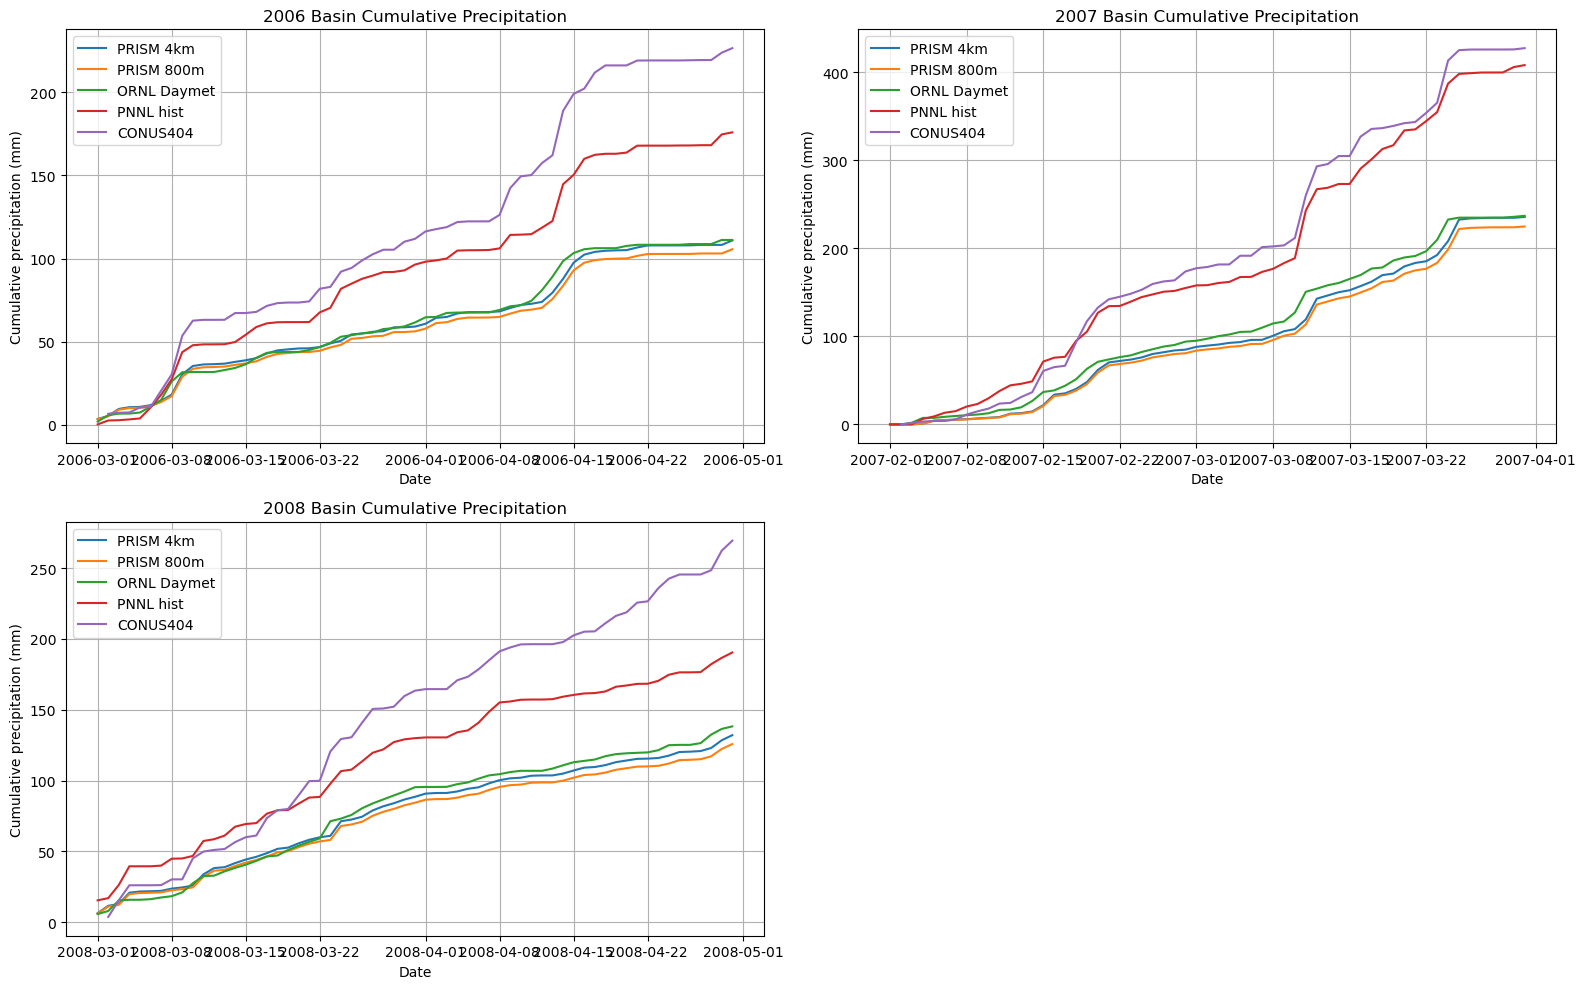

In [ ]:

# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison + VERIFICATION
# PRISM (local zarr), ORNL Daymet (local zarr),
# UCLA WRF outputs (local zarr; your ucla_wrf_outputs naming),
# PNNL hist WRF (local netcdf; dims time,x,y; geo from SERDP6km),
# CONUS404 (external OSN), SNOTEL (external)
#
# Outputs: one subplot per event window, cumulative precip (mm)
# Prints: variable units + key diagnostics (accum handling)
# Adds: verification prints for daily series + mass-balance checks
#
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import requests

# for seasonal-style CONUS mask creation
import shapely

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_PRISM_DIR  = BASE / "prism_nc"
P_ORNL_DIR   = BASE / "ornl_nc"

# UCLA outputs (your folder listing)
P_UCLA_DIR   = BASE / "ucla_wrf_outputs"

P_PNNL_DIR   = BASE / "PNNL" / "historical"
P_PNNL_GEO   = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"
BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

# External
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

SNOTEL_STATIONS_GEOJSON = (
    "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
)

# ----------------------------
# EVENTS
# ----------------------------
events = {
    2006: ("2006-03-01", "2006-04-30"),
    2007: ("2007-02-01", "2007-03-31"),
    2008: ("2008-03-01", "2008-04-30"),
}

# ----------------------------
# HELPERS
# ----------------------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    return gdf.geometry.union_all()

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    """Sum to daily totals (safe for both hourly and daily)."""
    if "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_increment(acc_like_1d):
    """
    Reset-safe increments for an accumulated series (1D time):
      inc[t] = diff if diff>=0 else current_value (reset)
    Output aligns to time[1:].
    """
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    """
    Convert accumulated precip (mm) -> increments (mm/step) -> daily totals (mm/day).
    acc_like_1d MUST be 1D (time).
    """
    bm = acc_like_1d
    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = float((d < 0).mean())
    mean_raw = float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean())
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)
    daily = ensure_daily_sum(inc)
    return daily

# ----------------------------
# VERIFICATION
# ----------------------------
def debug_daily(label, daily_da):
    """Print distribution stats for a DAILY (mm/day) 1D time series."""
    if daily_da is None or "time" not in daily_da.dims or daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (empty)")
        return
    daily_da = daily_da.dropna("time")
    if daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (all NaN)")
        return
    print(f"\n[{label}] DAILY CHECK")
    print("  min:", float(daily_da.min()))
    print("  max:", float(daily_da.max()))
    print("  mean:", float(daily_da.mean()))
    print("  sum:", float(daily_da.sum()))

def _median_dt_hours_from_da(da):
    if da is None or "time" not in da.dims:
        return None
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return None
    dt_hours = pd.Series(t).diff().dt.total_seconds().dropna().median() / 3600.0
    return float(dt_hours) if pd.notnull(dt_hours) else None

def verify_daily_and_cumsum(label, daily_da, cum_da=None, top_n=5):
    """
    Verifies:
      - dt sanity
      - daily stats
      - sum(daily) == last(cumsum) (if cum passed)
      - top-N daily increments (helps spot unit/var issues)
    """
    if daily_da is None or daily_da.size == 0:
        print(f"\n===== VERIFY: {label} =====")
        print("  (no data)")
        return

    daily_da = daily_da.dropna("time").sortby("time")
    print(f"\n===== VERIFY: {label} =====")
    dt_hours = _median_dt_hours_from_da(daily_da)
    if dt_hours is not None:
        print(f"  median dt (hours): {dt_hours:.2f}")

    debug_daily(label, daily_da)

    # mass balance with cumsum if provided
    if cum_da is not None and is_plottable_1d(cum_da):
        try:
            cum_last = float(cum_da.dropna("time").isel(time=-1))
            daily_sum = float(daily_da.sum())
            print("  CHECK: daily.sum vs cum[-1]:", daily_sum, cum_last, " | diff:", daily_sum - cum_last)
        except Exception as e:
            print("  CHECK: daily.sum vs cum[-1]: (failed)", repr(e))

    # top N days
    try:
        top = daily_da.sortby(daily_da, ascending=False).isel(time=slice(0, min(top_n, daily_da.size)))
        print(f"  TOP {min(top_n, daily_da.size)} daily values:")
        for tt, vv in zip(pd.to_datetime(top["time"].values), np.asarray(top.values)):
            print("   ", tt.date(), float(vv))
    except Exception as e:
        print("  TOP daily values: (failed)", repr(e))

# ----------------------------
# MASKS
# ----------------------------
def mask_curvilinear_bool(ds, geom, lon_name="lon", lat_name="lat"):
    """
    Curvilinear grids with 2D lon/lat.
    SAFE: no meshgrid, no .values.
    """
    region = regionmask.Regions([geom])
    m = region.mask(ds[lon_name], ds[lat_name])  # positional args for compat
    return ~xr.ufuncs.isnan(m)

def _infer_lonlat_vars(ds):
    """
    Find lon/lat arrays in either coords or data_vars.
    Works for typical WRF outputs (XLONG/XLAT) and also lon/lat.
    Returns (lon_da, lat_da) or (None, None).
    """
    lon_candidates = ["lon", "longitude", "XLONG", "XLONG_M", "LON", "xlong", "xlong_m"]
    lat_candidates = ["lat", "latitude",  "XLAT",  "XLAT_M",  "LAT", "xlat",  "xlat_m"]

    def _get(name):
        if name in ds.coords:
            return ds.coords[name]
        if name in ds.data_vars:
            return ds.data_vars[name]
        return None

    lon = None
    lat = None
    for n in lon_candidates:
        lon = _get(n)
        if lon is not None:
            break
    for n in lat_candidates:
        lat = _get(n)
        if lat is not None:
            break

    if lon is None or lat is None:
        return None, None

    # squeeze any time-like dim if present (WRF often has Time)
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})
    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})

    return lon, lat

# ----------------------------
# PRISM (covers-window match)
# ----------------------------
import re

_PRISM_NAME_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_daily_(?P<tag>4km|800m)_PRISM_data\.zarr$"
)

def find_prism_zarr_covering(start, end, tag):
    """
    Find a PRISM zarr whose filename date-range fully covers [start,end].
    Prefers the smallest covering file (event-specific over full-year).
    """
    start = pd.Timestamp(start)
    end   = pd.Timestamp(end)

    candidates = []
    for p in P_PRISM_DIR.glob(f"*_daily_{tag}_PRISM_data.zarr"):
        m = _PRISM_NAME_RE.search(p.name)
        if not m:
            continue
        f0 = pd.Timestamp(m.group("s"))
        f1 = pd.Timestamp(m.group("e"))
        if f0 <= start and f1 >= end:
            span_days = (f1 - f0).days
            candidates.append((span_days, f0, p))

    if not candidates:
        return None

    # smallest span first; if tie, later start first
    candidates.sort(key=lambda t: (t[0], -t[1].value))
    return candidates[0][2]

def load_prism(start, end, tag, do_verify=True):
    z = find_prism_zarr_covering(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag} [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm_daily = daily.mean(dim=spatial, skipna=True)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum(f"PRISM {tag}", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# ORNL Daymet
# ----------------------------
def load_ornl(year, start, end, do_verify=True):
    z = next(P_ORNL_DIR.glob(f"{year}_{year}_ref_*ORNL_data.zarr"), None)
    if z is None:
        print("  - ORNL Daymet: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["prcp"])
    if var is None:
        print("  - ORNL Daymet: (no prcp var)")
        ds.close()
        return None

    print_units(ds, var, f"ORNL Daymet [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm_daily = daily.mean(dim=spatial, skipna=True)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("ORNL Daymet", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# UCLA WRF OUTPUTS 
# ----------------------------
_UCLA_MASK = None
_UCLA_MASK_KEY = None

def _parse_ucla_event_zarr_name(p: Path):
    """
    Expected patterns:
      {start}_{end}_wrf_cesm2_r11i1p1f1_historical_data.zarr
      {start}_{end}_wrf_cesm2_r11i1p1f1_ssp245_data.zarr
    """
    name = p.name
    if not name.endswith(".zarr"):
        return None, None, None
    parts = name.split("_")
    if len(parts) < 3:
        return None, None, None
    try:
        s0 = pd.to_datetime(parts[0])
        s1 = pd.to_datetime(parts[1])
    except Exception:
        return None, None, None

    scenario = "historical" if "historical" in name else ("ssp245" if "ssp245" in name else "unknown")
    return s0, s1, scenario

def find_ucla_zarr_event(start, end):
    """
    Finder for UCLA event zarrs.
    Allows end-date mismatch ±2 days (e.g., 1995 file ends 12-09).
    """
    if not P_UCLA_DIR.exists():
        return None

    s0 = pd.to_datetime(start)
    s1 = pd.to_datetime(end)

    exact = P_UCLA_DIR / f"{s0:%Y-%m-%d}_{s1:%Y-%m-%d}_wrf_cesm2_r11i1p1f1_historical_data.zarr"
    if exact.exists():
        return exact

    exact_ssp = P_UCLA_DIR / f"{s0:%Y-%m-%d}_{s1:%Y-%m-%d}_wrf_cesm2_r11i1p1f1_ssp245_data.zarr"
    if exact_ssp.exists():
        return exact_ssp

    candidates = sorted(P_UCLA_DIR.glob(f"{s0:%Y-%m-%d}_*_wrf_cesm2_r11i1p1f1_*_data.zarr"))
    if not candidates:
        candidates = sorted(P_UCLA_DIR.glob(f"{s0:%Y-%m-%d}_*_wrf_*_data.zarr"))

    best = None
    best_score = None
    for p in candidates:
        c0, c1, _scen = _parse_ucla_event_zarr_name(p)
        if c0 is None:
            continue
        if c0.normalize() != s0.normalize():
            continue
        score = abs((c1.normalize() - s1.normalize()).days)
        if best is None or score < best_score:
            best = p
            best_score = score

    if best is not None and best_score is not None and best_score <= 2:
        return best
    return None

def build_ucla_mask_for_da(da_precip, ds_ucla, geom):
    spatial = [d for d in da_precip.dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[UCLA] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = da_precip.sizes[d0], da_precip.sizes[d1]

    lon, lat = _infer_lonlat_vars(ds_ucla)
    if lon is None or lat is None:
        raise RuntimeError("[UCLA] Could not infer lon/lat arrays")

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)

    mask_np = np.asarray(mask_geo.data).astype(bool)

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[UCLA] Mask shape {mask_np.shape} does not match precip grid "
            f"({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_ucla(start, end, geom, do_verify=True):
    global _UCLA_MASK, _UCLA_MASK_KEY

    z = find_ucla_zarr_event(start, end)
    if z is None:
        print("  - UCLA WRF: (not available)")
        return None

    ds = safe_open_zarr(z)

    var = pick_var(ds, ["PREC_ACC_NC", "RAINNC", "RAINC", "RAIN", "prcp", "precip", "precipitation", "ppt"])
    if var is None:
        print(f"  - UCLA WRF [{z.name}]: (no precip var found)")
        print(f"    data_vars (first 60): {list(ds.data_vars)[:60]}")
        ds.close()
        return None

    print_units(ds, var, f"UCLA WRF [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    spatial = [d for d in da.dims if d != "time"]

    key = (z.as_posix(), var, tuple(spatial), da.sizes[spatial[0]], da.sizes[spatial[1]])
    if (_UCLA_MASK is None) or (_UCLA_MASK_KEY != key):
        _UCLA_MASK = build_ucla_mask_for_da(da, ds, geom)
        _UCLA_MASK_KEY = key

    bm = da.where(_UCLA_MASK).mean(dim=spatial, skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = (
        ("accum" in var.lower()) or ("accumul" in desc) or
        (var.upper() in ("RAINNC", "RAINC", "RAIN", "PREC_ACC_NC"))
    )
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label="UCLA WRF accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("UCLA WRF", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# PNNL HIST WRF (dims time,x,y) – SAFE MASK BUILD
# ----------------------------
_PNNL_MASK_XY = None
_PNNL_MASK_KEY = None

def build_pnnl_mask_for_ds(ds_prec, geom):
    spatial = [d for d in ds_prec["PREC_ACC_NC"].dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = ds_prec.sizes[d0], ds_prec.sizes[d1]

    geo = xr.open_dataset(P_PNNL_GEO)

    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat = geo[lat_name]
    lon = geo[lon_name]

    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)

    mask_np = np.asarray(mask_geo.data).astype(bool)
    geo.close()

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[PNNL] Mask shape {mask_np.shape} does not match precip grid "
            f"({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_pnnl(year, start, end, geom, do_verify=True):
    global _PNNL_MASK_XY, _PNNL_MASK_KEY

    f = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", "PNNL hist")

    spatial = [d for d in ds["PREC_ACC_NC"].dims if d != "time"]
    key = (tuple(spatial), ds.sizes[spatial[0]], ds.sizes[spatial[1]])
    if (_PNNL_MASK_XY is None) or (_PNNL_MASK_KEY != key):
        _PNNL_MASK_XY = build_pnnl_mask_for_ds(ds, geom)
        _PNNL_MASK_KEY = key

    da = ds["PREC_ACC_NC"].sel(time=slice(start, end)).sortby("time")
    bm_acc = da.where(_PNNL_MASK_XY).mean(dim=spatial, skipna=True)

    bm_daily = accumulated_to_daily_mm(bm_acc, label="PNNL hist")
    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("PNNL hist", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# CONUS404 (external) 
# ----------------------------
_conus_ds = None
_conus_mask = None  # cached xr.DataArray boolean mask on (y,x)

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus(start, end, geom, do_verify=True):
    """
    Seasonal-style CONUS loading:
      - build mask via shapely.contains_xy(geom, lon.values, lat.values)
      - cache mask globally
      - basin mean on native grid
    """
    global _conus_mask

    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()

    var = pick_var(ds, [
        "prcp", "precip", "precipitation", "PREC", "PRECIP",
        "RAIN", "RAINNC", "RAINC",
        "PREC_ACC_NC"
    ])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    # seasonal-style mask build (NOTE: materializes full lon/lat in RAM)
    if _conus_mask is None:
        lon = ds["lon"]
        lat = ds["lat"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)  # (y,x) boolean numpy
        _conus_mask = xr.DataArray(mask_np, dims=("y", "x"))

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    bm = da.where(_conus_mask).mean(dim=("y", "x"), skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = ("accum" in var.lower()) or ("accumul" in desc) or (var.upper() in ("RAINNC", "RAINC", "PREC_ACC_NC"))
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label="CONUS404 accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("CONUS404", bm_daily, cum)

    return cum

# ----------------------------
# SNOTEL (external)
# ----------------------------
def load_snotel(start, end, geom, do_verify=True):
    """
    Uses the GeoJSON's 'code' field as stationTriplet (your GeoJSON does NOT expose 'triplet').
    AWDB endpoint can be flaky; this function fails soft (prints error and returns None).
    """
    stations = gpd.read_file(SNOTEL_STATIONS_GEOJSON).to_crs("EPSG:4326")
    basin = gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")
    sel = gpd.sjoin(stations, basin, predicate="intersects", how="inner")

    if sel.empty:
        print("  - SNOTEL: no stations in basin")
        return None

    if "code" not in sel.columns:
        print("  - SNOTEL: expected 'code' column not found")
        print("    Available columns:", list(sel.columns))
        return None

    triplets = sorted(set(sel["code"].dropna().astype(str).tolist()))
    if not triplets:
        print("  - SNOTEL: no valid station triplets")
        return None

    url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data/getDaily"
    params = {
        "stationTriplets": ",".join(triplets),
        "elements": "PRCPSA",
        "beginDate": start,
        "endDate": end,
        "format": "json",
    }

    try:
        rr = requests.get(url, params=params, timeout=120)
        if rr.status_code != 200:
            print("  - SNOTEL: AWDB request failed")
            print("    status:", rr.status_code)
            print("    url:", rr.url)
            return None
        js = rr.json()
    except Exception as e:
        print("  - SNOTEL: AWDB request error:", repr(e))
        return None

    data = {}
    for st in js:
        trip = st.get("stationTriplet")
        vals = st.get("values", [])
        if not trip or not vals:
            continue
        s = {pd.to_datetime(v["date"]): (np.nan if v["value"] is None else float(v["value"])) for v in vals}
        data[trip] = pd.Series(s)

    if not data:
        print("  - SNOTEL: AWDB returned no data")
        return None

    df_in = pd.DataFrame(data).sort_index()
    print(f"  - SNOTEL: var='PRCPSA', units='inches → mm', stations={df_in.shape[1]}")

    df_mm = df_in * 25.4
    daily_mean = df_mm.mean(axis=1, skipna=True).loc[pd.to_datetime(start):pd.to_datetime(end)].asfreq("D")

    bm_daily = xr.DataArray(
        daily_mean.values,
        coords={"time": daily_mean.index},
        dims=("time",),
        name="SNOTEL",
    )
    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("SNOTEL", bm_daily, cum)

    return cum

# ----------------------------
# MAIN
# ----------------------------
def main():
    geom = load_basin_geom()

    n = len(events)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axs = np.array(axs).reshape(-1)

    for i, (yr, (start, end)) in enumerate(events.items()):
        ax = axs[i]
        print(f"\n================ {yr} ({start} → {end}) ================")

        series = [
            ("PRISM 4km",    load_prism(start, end, "4km", do_verify=True)),
            ("PRISM 800m",   load_prism(start, end, "800m", do_verify=True)),
            ("ORNL Daymet",  load_ornl(yr, start, end, do_verify=True)),
            ("UCLA WRF",     load_ucla(start, end, geom, do_verify=True)),
            ("PNNL hist",    load_pnnl(yr, start, end, geom, do_verify=True)),
            ("CONUS404",     load_conus(start, end, geom, do_verify=True)),
            ("SNOTEL",       load_snotel(start, end, geom, do_verify=True)),
        ]

        plotted_any = False
        for label, da in series:
            if is_plottable_1d(da):
                ax.plot(pd.to_datetime(da["time"].values), da.values, label=label)
                plotted_any = True

        ax.set_title(f"{yr} Basin Cumulative Precipitation")
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative precipitation (mm)")
        ax.grid(True)
        if plotted_any:
            ax.legend()

    for j in range(len(events), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


================ 2012 (2012-06-01 → 2012-07-31) ================
  - PRISM 4km [2012-01-01_2012-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km =====
  median dt (hours): 24.00

[PRISM 4km] DAILY CHECK
  min: 0.0
  max: 9.276529312133789
  mean: 1.4589226245880127
  sum: 88.99427795410156
  CHECK: daily.sum vs cum[-1]: 88.99427795410156 88.99427795410156  | diff: 0.0
  TOP 5 daily values:
    2012-06-17 9.276529312133789
    2012-07-04 6.120370388031006
    2012-06-08 5.7481369972229
    2012-06-02 5.713587760925293
    2012-06-23 5.481362819671631
  - PRISM 800m [2012-01-01_2012-12-31_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 800m =====
  median dt (hours): 24.00

[PRISM 800m] DAILY CHECK
  min: 0.0
  max: 8.838093757629395
  mean: 1.3912668228149414
  sum: 84.86727905273438
  CHECK: daily.sum vs cum[-1]: 84.86727905273438 84.86727905273438  | diff: 0.0
  TOP 5 daily values:
    2012-06-17 8.838093757629395


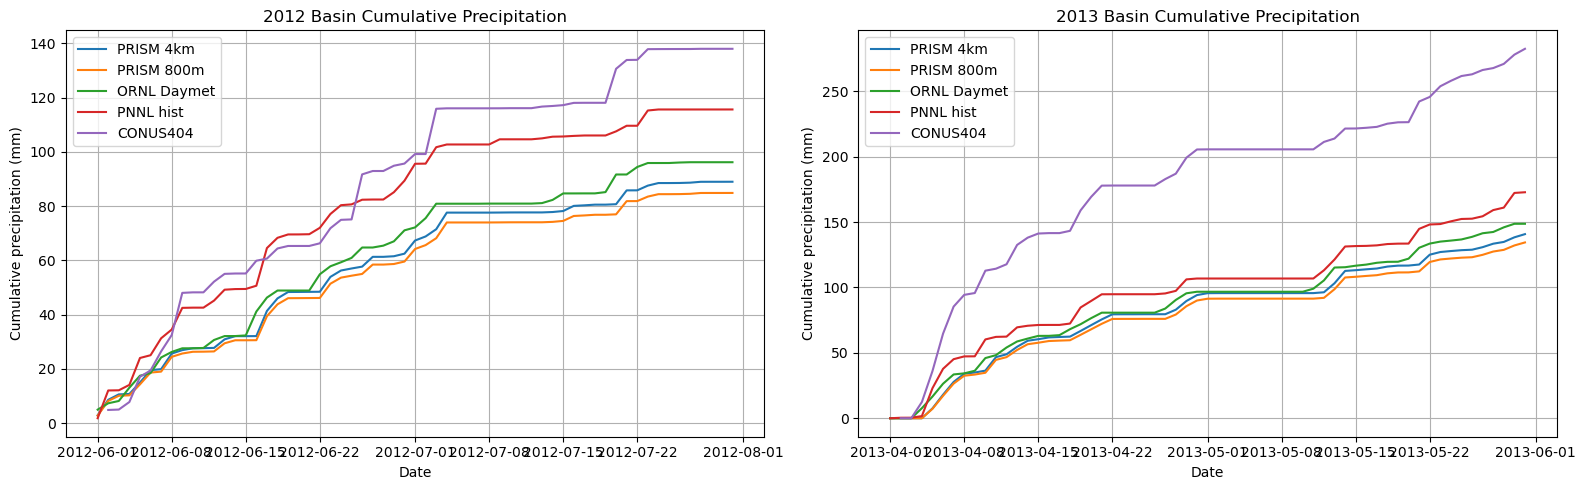

In [ ]:

# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison + VERIFICATION
# PRISM (local zarr), ORNL Daymet (local zarr),
# UCLA WRF outputs (local zarr; your ucla_wrf_outputs naming),
# PNNL hist WRF (local netcdf; dims time,x,y; geo from SERDP6km),
# CONUS404 (external OSN), SNOTEL (external)
#
# Outputs: one subplot per event window, cumulative precip (mm)
# Prints: variable units + key diagnostics (accum handling)
# Adds: verification prints for daily series + mass-balance checks
#
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import requests

# NEW: for seasonal-style CONUS mask creation
import shapely

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_PRISM_DIR  = BASE / "prism_nc"
P_ORNL_DIR   = BASE / "ornl_nc"

# UCLA outputs 
P_UCLA_DIR   = BASE / "ucla_wrf_outputs"

P_PNNL_DIR   = BASE / "PNNL" / "historical"
P_PNNL_GEO   = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"
BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

# External
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

SNOTEL_STATIONS_GEOJSON = (
    "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
)

# ----------------------------
# EVENTS
# ----------------------------
events = {
    2012: ("2012-05-01", "2012-06-30"),
    2012: ("2012-06-01", "2012-07-31"),
    2013: ("2013-04-01", "2013-05-31"),
}

# ----------------------------
# HELPERS
# ----------------------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    return gdf.geometry.union_all()

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    """Sum to daily totals (safe for both hourly and daily)."""
    if "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_increment(acc_like_1d):
    """
    Reset-safe increments for an accumulated series (1D time):
      inc[t] = diff if diff>=0 else current_value (reset)
    Output aligns to time[1:].
    """
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    """
    Convert accumulated precip (mm) -> increments (mm/step) -> daily totals (mm/day).
    acc_like_1d MUST be 1D (time).
    """
    bm = acc_like_1d
    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = float((d < 0).mean())
    mean_raw = float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean())
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)
    daily = ensure_daily_sum(inc)
    return daily

# ----------------------------
# VERIFICATION
# ----------------------------
def debug_daily(label, daily_da):
    """Print distribution stats for a DAILY (mm/day) 1D time series."""
    if daily_da is None or "time" not in daily_da.dims or daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (empty)")
        return
    daily_da = daily_da.dropna("time")
    if daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (all NaN)")
        return
    print(f"\n[{label}] DAILY CHECK")
    print("  min:", float(daily_da.min()))
    print("  max:", float(daily_da.max()))
    print("  mean:", float(daily_da.mean()))
    print("  sum:", float(daily_da.sum()))

def _median_dt_hours_from_da(da):
    if da is None or "time" not in da.dims:
        return None
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return None
    dt_hours = pd.Series(t).diff().dt.total_seconds().dropna().median() / 3600.0
    return float(dt_hours) if pd.notnull(dt_hours) else None

def verify_daily_and_cumsum(label, daily_da, cum_da=None, top_n=5):
    """
    Verifies:
      - dt sanity
      - daily stats
      - sum(daily) == last(cumsum) (if cum passed)
      - top-N daily increments (helps spot unit/var issues)
    """
    if daily_da is None or daily_da.size == 0:
        print(f"\n===== VERIFY: {label} =====")
        print("  (no data)")
        return

    daily_da = daily_da.dropna("time").sortby("time")
    print(f"\n===== VERIFY: {label} =====")
    dt_hours = _median_dt_hours_from_da(daily_da)
    if dt_hours is not None:
        print(f"  median dt (hours): {dt_hours:.2f}")

    debug_daily(label, daily_da)

    # mass balance with cumsum if provided
    if cum_da is not None and is_plottable_1d(cum_da):
        try:
            cum_last = float(cum_da.dropna("time").isel(time=-1))
            daily_sum = float(daily_da.sum())
            print("  CHECK: daily.sum vs cum[-1]:", daily_sum, cum_last, " | diff:", daily_sum - cum_last)
        except Exception as e:
            print("  CHECK: daily.sum vs cum[-1]: (failed)", repr(e))

    # top N days
    try:
        top = daily_da.sortby(daily_da, ascending=False).isel(time=slice(0, min(top_n, daily_da.size)))
        print(f"  TOP {min(top_n, daily_da.size)} daily values:")
        for tt, vv in zip(pd.to_datetime(top["time"].values), np.asarray(top.values)):
            print("   ", tt.date(), float(vv))
    except Exception as e:
        print("  TOP daily values: (failed)", repr(e))

# ----------------------------
# MASKS
# ----------------------------
def mask_curvilinear_bool(ds, geom, lon_name="lon", lat_name="lat"):
    """
    Curvilinear grids with 2D lon/lat.
    SAFE: no meshgrid, no .values.
    """
    region = regionmask.Regions([geom])
    m = region.mask(ds[lon_name], ds[lat_name])  # positional args for compat
    return ~xr.ufuncs.isnan(m)

def _infer_lonlat_vars(ds):
    """
    Find lon/lat arrays in either coords or data_vars.
    Works for typical WRF outputs (XLONG/XLAT) and also lon/lat.
    Returns (lon_da, lat_da) or (None, None).
    """
    lon_candidates = ["lon", "longitude", "XLONG", "XLONG_M", "LON", "xlong", "xlong_m"]
    lat_candidates = ["lat", "latitude",  "XLAT",  "XLAT_M",  "LAT", "xlat",  "xlat_m"]

    def _get(name):
        if name in ds.coords:
            return ds.coords[name]
        if name in ds.data_vars:
            return ds.data_vars[name]
        return None

    lon = None
    lat = None
    for n in lon_candidates:
        lon = _get(n)
        if lon is not None:
            break
    for n in lat_candidates:
        lat = _get(n)
        if lat is not None:
            break

    if lon is None or lat is None:
        return None, None

    # squeeze any time-like dim if present (WRF often has Time)
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})
    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})

    return lon, lat

# ----------------------------
# PRISM (covers-window match)
# ----------------------------
import re

_PRISM_NAME_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_daily_(?P<tag>4km|800m)_PRISM_data\.zarr$"
)

def find_prism_zarr_covering(start, end, tag):
    """
    Find a PRISM zarr whose filename date-range fully covers [start,end].
    Prefers the smallest covering file (event-specific over full-year).
    """
    start = pd.Timestamp(start)
    end   = pd.Timestamp(end)

    candidates = []
    for p in P_PRISM_DIR.glob(f"*_daily_{tag}_PRISM_data.zarr"):
        m = _PRISM_NAME_RE.search(p.name)
        if not m:
            continue
        f0 = pd.Timestamp(m.group("s"))
        f1 = pd.Timestamp(m.group("e"))
        if f0 <= start and f1 >= end:
            span_days = (f1 - f0).days
            candidates.append((span_days, f0, p))

    if not candidates:
        return None

    # smallest span first; if tie, later start first
    candidates.sort(key=lambda t: (t[0], -t[1].value))
    return candidates[0][2]

def load_prism(start, end, tag, do_verify=True):
    z = find_prism_zarr_covering(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag} [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm_daily = daily.mean(dim=spatial, skipna=True)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum(f"PRISM {tag}", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# ORNL Daymet
# ----------------------------
def load_ornl(year, start, end, do_verify=True):
    z = next(P_ORNL_DIR.glob(f"{year}_{year}_ref_*ORNL_data.zarr"), None)
    if z is None:
        print("  - ORNL Daymet: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["prcp"])
    if var is None:
        print("  - ORNL Daymet: (no prcp var)")
        ds.close()
        return None

    print_units(ds, var, f"ORNL Daymet [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm_daily = daily.mean(dim=spatial, skipna=True)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("ORNL Daymet", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# UCLA WRF OUTPUTS (local zarr; matches your naming)
# ----------------------------
_UCLA_MASK = None
_UCLA_MASK_KEY = None

def _parse_ucla_event_zarr_name(p: Path):
    """
    Expected patterns:
      {start}_{end}_wrf_cesm2_r11i1p1f1_historical_data.zarr
      {start}_{end}_wrf_cesm2_r11i1p1f1_ssp245_data.zarr
    """
    name = p.name
    if not name.endswith(".zarr"):
        return None, None, None
    parts = name.split("_")
    if len(parts) < 3:
        return None, None, None
    try:
        s0 = pd.to_datetime(parts[0])
        s1 = pd.to_datetime(parts[1])
    except Exception:
        return None, None, None

    scenario = "historical" if "historical" in name else ("ssp245" if "ssp245" in name else "unknown")
    return s0, s1, scenario

def find_ucla_zarr_event(start, end):
    """
    Finder for UCLA event zarrs.
    Allows end-date mismatch ±2 days (e.g., 1995 file ends 12-09).
    """
    if not P_UCLA_DIR.exists():
        return None

    s0 = pd.to_datetime(start)
    s1 = pd.to_datetime(end)

    exact = P_UCLA_DIR / f"{s0:%Y-%m-%d}_{s1:%Y-%m-%d}_wrf_cesm2_r11i1p1f1_historical_data.zarr"
    if exact.exists():
        return exact

    exact_ssp = P_UCLA_DIR / f"{s0:%Y-%m-%d}_{s1:%Y-%m-%d}_wrf_cesm2_r11i1p1f1_ssp245_data.zarr"
    if exact_ssp.exists():
        return exact_ssp

    candidates = sorted(P_UCLA_DIR.glob(f"{s0:%Y-%m-%d}_*_wrf_cesm2_r11i1p1f1_*_data.zarr"))
    if not candidates:
        candidates = sorted(P_UCLA_DIR.glob(f"{s0:%Y-%m-%d}_*_wrf_*_data.zarr"))

    best = None
    best_score = None
    for p in candidates:
        c0, c1, _scen = _parse_ucla_event_zarr_name(p)
        if c0 is None:
            continue
        if c0.normalize() != s0.normalize():
            continue
        score = abs((c1.normalize() - s1.normalize()).days)
        if best is None or score < best_score:
            best = p
            best_score = score

    if best is not None and best_score is not None and best_score <= 2:
        return best
    return None

def build_ucla_mask_for_da(da_precip, ds_ucla, geom):
    spatial = [d for d in da_precip.dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[UCLA] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = da_precip.sizes[d0], da_precip.sizes[d1]

    lon, lat = _infer_lonlat_vars(ds_ucla)
    if lon is None or lat is None:
        raise RuntimeError("[UCLA] Could not infer lon/lat arrays")

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)

    mask_np = np.asarray(mask_geo.data).astype(bool)

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[UCLA] Mask shape {mask_np.shape} does not match precip grid "
            f"({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_ucla(start, end, geom, do_verify=True):
    global _UCLA_MASK, _UCLA_MASK_KEY

    z = find_ucla_zarr_event(start, end)
    if z is None:
        print("  - UCLA WRF: (not available)")
        return None

    ds = safe_open_zarr(z)

    var = pick_var(ds, ["PREC_ACC_NC", "RAINNC", "RAINC", "RAIN", "prcp", "precip", "precipitation", "ppt"])
    if var is None:
        print(f"  - UCLA WRF [{z.name}]: (no precip var found)")
        print(f"    data_vars (first 60): {list(ds.data_vars)[:60]}")
        ds.close()
        return None

    print_units(ds, var, f"UCLA WRF [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    spatial = [d for d in da.dims if d != "time"]

    key = (z.as_posix(), var, tuple(spatial), da.sizes[spatial[0]], da.sizes[spatial[1]])
    if (_UCLA_MASK is None) or (_UCLA_MASK_KEY != key):
        _UCLA_MASK = build_ucla_mask_for_da(da, ds, geom)
        _UCLA_MASK_KEY = key

    bm = da.where(_UCLA_MASK).mean(dim=spatial, skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = (
        ("accum" in var.lower()) or ("accumul" in desc) or
        (var.upper() in ("RAINNC", "RAINC", "RAIN", "PREC_ACC_NC"))
    )
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label="UCLA WRF accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("UCLA WRF", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# PNNL HIST WRF (dims time,x,y) – SAFE MASK BUILD
# ----------------------------
_PNNL_MASK_XY = None
_PNNL_MASK_KEY = None

def build_pnnl_mask_for_ds(ds_prec, geom):
    spatial = [d for d in ds_prec["PREC_ACC_NC"].dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = ds_prec.sizes[d0], ds_prec.sizes[d1]

    geo = xr.open_dataset(P_PNNL_GEO)

    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat = geo[lat_name]
    lon = geo[lon_name]

    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)

    mask_np = np.asarray(mask_geo.data).astype(bool)
    geo.close()

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[PNNL] Mask shape {mask_np.shape} does not match precip grid "
            f"({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_pnnl(year, start, end, geom, do_verify=True):
    global _PNNL_MASK_XY, _PNNL_MASK_KEY

    f = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", "PNNL hist")

    spatial = [d for d in ds["PREC_ACC_NC"].dims if d != "time"]
    key = (tuple(spatial), ds.sizes[spatial[0]], ds.sizes[spatial[1]])
    if (_PNNL_MASK_XY is None) or (_PNNL_MASK_KEY != key):
        _PNNL_MASK_XY = build_pnnl_mask_for_ds(ds, geom)
        _PNNL_MASK_KEY = key

    da = ds["PREC_ACC_NC"].sel(time=slice(start, end)).sortby("time")
    bm_acc = da.where(_PNNL_MASK_XY).mean(dim=spatial, skipna=True)

    bm_daily = accumulated_to_daily_mm(bm_acc, label="PNNL hist")
    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("PNNL hist", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# CONUS404 (external) 
# ----------------------------
_conus_ds = None
_conus_mask = None  # cached xr.DataArray boolean mask on (y,x)

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus(start, end, geom, do_verify=True):
    """
    Seasonal-style CONUS loading:
      - build mask via shapely.contains_xy(geom, lon.values, lat.values)
      - cache mask globally
      - basin mean on native grid
    """
    global _conus_mask

    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()

    var = pick_var(ds, [
        "prcp", "precip", "precipitation", "PREC", "PRECIP",
        "RAIN", "RAINNC", "RAINC",
        "PREC_ACC_NC"
    ])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    # seasonal-style mask build (NOTE: materializes full lon/lat in RAM)
    if _conus_mask is None:
        lon = ds["lon"]
        lat = ds["lat"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)  # (y,x) boolean numpy
        _conus_mask = xr.DataArray(mask_np, dims=("y", "x"))

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    bm = da.where(_conus_mask).mean(dim=("y", "x"), skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = ("accum" in var.lower()) or ("accumul" in desc) or (var.upper() in ("RAINNC", "RAINC", "PREC_ACC_NC"))
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label="CONUS404 accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("CONUS404", bm_daily, cum)

    return cum

# ----------------------------
# SNOTEL (external)
# ----------------------------
def load_snotel(start, end, geom, do_verify=True):
    """
    Uses the GeoJSON's 'code' field as stationTriplet (your GeoJSON does NOT expose 'triplet').
    AWDB endpoint can be flaky; this function fails soft (prints error and returns None).
    """
    stations = gpd.read_file(SNOTEL_STATIONS_GEOJSON).to_crs("EPSG:4326")
    basin = gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")
    sel = gpd.sjoin(stations, basin, predicate="intersects", how="inner")

    if sel.empty:
        print("  - SNOTEL: no stations in basin")
        return None

    if "code" not in sel.columns:
        print("  - SNOTEL: expected 'code' column not found")
        print("    Available columns:", list(sel.columns))
        return None

    triplets = sorted(set(sel["code"].dropna().astype(str).tolist()))
    if not triplets:
        print("  - SNOTEL: no valid station triplets")
        return None

    url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data/getDaily"
    params = {
        "stationTriplets": ",".join(triplets),
        "elements": "PRCPSA",
        "beginDate": start,
        "endDate": end,
        "format": "json",
    }

    try:
        rr = requests.get(url, params=params, timeout=120)
        if rr.status_code != 200:
            print("  - SNOTEL: AWDB request failed")
            print("    status:", rr.status_code)
            print("    url:", rr.url)
            return None
        js = rr.json()
    except Exception as e:
        print("  - SNOTEL: AWDB request error:", repr(e))
        return None

    data = {}
    for st in js:
        trip = st.get("stationTriplet")
        vals = st.get("values", [])
        if not trip or not vals:
            continue
        s = {pd.to_datetime(v["date"]): (np.nan if v["value"] is None else float(v["value"])) for v in vals}
        data[trip] = pd.Series(s)

    if not data:
        print("  - SNOTEL: AWDB returned no data")
        return None

    df_in = pd.DataFrame(data).sort_index()
    print(f"  - SNOTEL: var='PRCPSA', units='inches → mm', stations={df_in.shape[1]}")

    df_mm = df_in * 25.4
    daily_mean = df_mm.mean(axis=1, skipna=True).loc[pd.to_datetime(start):pd.to_datetime(end)].asfreq("D")

    bm_daily = xr.DataArray(
        daily_mean.values,
        coords={"time": daily_mean.index},
        dims=("time",),
        name="SNOTEL",
    )
    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("SNOTEL", bm_daily, cum)

    return cum

# ----------------------------
# MAIN
# ----------------------------
def main():
    geom = load_basin_geom()

    n = len(events)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axs = np.array(axs).reshape(-1)

    for i, (yr, (start, end)) in enumerate(events.items()):
        ax = axs[i]
        print(f"\n================ {yr} ({start} → {end}) ================")

        series = [
            ("PRISM 4km",    load_prism(start, end, "4km", do_verify=True)),
            ("PRISM 800m",   load_prism(start, end, "800m", do_verify=True)),
            ("ORNL Daymet",  load_ornl(yr, start, end, do_verify=True)),
            ("UCLA WRF",     load_ucla(start, end, geom, do_verify=True)),
            ("PNNL hist",    load_pnnl(yr, start, end, geom, do_verify=True)),
            ("CONUS404",     load_conus(start, end, geom, do_verify=True)),
            ("SNOTEL",       load_snotel(start, end, geom, do_verify=True)),
        ]

        plotted_any = False
        for label, da in series:
            if is_plottable_1d(da):
                ax.plot(pd.to_datetime(da["time"].values), da.values, label=label)
                plotted_any = True

        ax.set_title(f"{yr} Basin Cumulative Precipitation")
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative precipitation (mm)")
        ax.grid(True)
        if plotted_any:
            ax.legend()

    for j in range(len(events), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


================ 2006 (2006-03-01 → 2006-04-30) ================
  - PRISM 4km [2006-01-01_2006-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km =====
  median dt (hours): 24.00

[PRISM 4km] DAILY CHECK
  min: 0.0
  max: 12.21356201171875
  mean: 1.8172951936721802
  sum: 110.8550033569336
  CHECK: daily.sum vs cum[-1]: 110.8550033569336 110.8550033569336  | diff: 0.0
  TOP 5 daily values:
    2006-03-09 12.21356201171875
    2006-04-15 9.725650787353516
    2006-04-14 8.325936317443848
    2006-04-13 5.547675609588623
    2006-03-10 4.998325824737549
  - PRISM 800m [2006-01-01_2006-12-31_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 800m =====
  median dt (hours): 24.00

[PRISM 800m] DAILY CHECK
  min: 0.0
  max: 11.651607513427734
  mean: 1.7307782173156738
  sum: 105.57746887207031
  CHECK: daily.sum vs cum[-1]: 105.57746887207031 105.57747650146484  | diff: -7.62939453125e-06
  TOP 5 daily values:
    2006-03-

/tmp/ipykernel_847788/3184120835.py:524: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  m = region.mask(lon, lat)


    [UCLA] mask true cells: 0 / 91800 (0.000000)  (A=0, B=-1)
  - UCLA WRF: basin mask has 0 cells inside. lon/lat mapping is wrong for this dataset.
  - PNNL hist: var='PREC_ACC_NC', units='mm'
    [PNNL hist] accum-check: frac_neg=0.491, mean_raw=0.2039, mean_diff_pos=0.02853

===== VERIFY: PNNL hist =====
  median dt (hours): 24.00

[PNNL hist] DAILY CHECK
  min: 0.0
  max: 22.080331802368164
  mean: 2.8820619583129883
  sum: 175.8057861328125
  CHECK: daily.sum vs cum[-1]: 175.8057861328125 175.8057861328125  | diff: 0.0
  TOP 5 daily values:
    2006-04-14 22.080331802368164
    2006-03-09 16.335067749023438
    2006-03-24 11.447639465332031
    2006-04-16 9.609277725219727
    2006-03-08 9.329550743103027
  - CONUS404: var='PREC_ACC_NC', units='mm'
    [CONUS404 accum] accum-check: frac_neg=0.533, mean_raw=4.808, mean_diff_pos=2.235

===== VERIFY: CONUS404 =====
  median dt (hours): 24.00

[CONUS404] DAILY CHECK
  min: 0.0
  max: 26.661161422729492
  mean: 3.773221254348755
  sum

/tmp/ipykernel_847788/3184120835.py:524: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  m = region.mask(lon, lat)


    [UCLA] mask true cells: 0 / 91800 (0.000000)  (A=0, B=-1)
  - UCLA WRF: basin mask has 0 cells inside. lon/lat mapping is wrong for this dataset.
  - PNNL hist: var='PREC_ACC_NC', units='mm'
    [PNNL hist] accum-check: frac_neg=0.504, mean_raw=0.5172, mean_diff_pos=0.05393

===== VERIFY: PNNL hist =====
  median dt (hours): 24.00

[PNNL hist] DAILY CHECK
  min: 1.4848388360869103e-12
  max: 54.159690856933594
  mean: 6.920430660247803
  sum: 408.305419921875
  CHECK: daily.sum vs cum[-1]: 408.305419921875 408.305419921875  | diff: 0.0
  TOP 5 daily values:
    2007-03-11 54.159690856933594
    2007-03-24 32.425079345703125
    2007-03-12 24.159521102905273
    2007-02-15 22.423877716064453
    2007-02-20 21.503498077392578
  - CONUS404: var='PREC_ACC_NC', units='mm'
    [CONUS404 accum] accum-check: frac_neg=0.483, mean_raw=9.617, mean_diff_pos=4.736

===== VERIFY: CONUS404 =====
  median dt (hours): 24.00

[CONUS404] DAILY CHECK
  min: 0.0
  max: 48.4400749206543
  mean: 7.371963

/tmp/ipykernel_847788/3184120835.py:524: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  m = region.mask(lon, lat)


    [UCLA] mask true cells: 0 / 91800 (0.000000)  (A=0, B=-1)
  - UCLA WRF: basin mask has 0 cells inside. lon/lat mapping is wrong for this dataset.
  - PNNL hist: var='PREC_ACC_NC', units='mm'
    [PNNL hist] accum-check: frac_neg=0.489, mean_raw=0.2312, mean_diff_pos=0.0291

===== VERIFY: PNNL hist =====
  median dt (hours): 24.00

[PNNL hist] DAILY CHECK
  min: 6.502942255792732e-07
  max: 15.396793365478516
  mean: 3.122387647628784
  sum: 190.4656524658203
  CHECK: daily.sum vs cum[-1]: 190.4656524658203 190.46566772460938  | diff: -1.52587890625e-05
  TOP 5 daily values:
    2008-03-01 15.396793365478516
    2008-03-04 13.204811096191406
    2008-03-11 10.542072296142578
    2008-03-23 9.307998657226562
    2008-03-03 9.293814659118652
  - CONUS404: var='PREC_ACC_NC', units='mm'
    [CONUS404 accum] accum-check: frac_neg=0.567, mean_raw=5.899, mean_diff_pos=2.553

===== VERIFY: CONUS404 =====
  median dt (hours): 24.00

[CONUS404] DAILY CHECK
  min: 3.40527108733113e-08
  max: 2

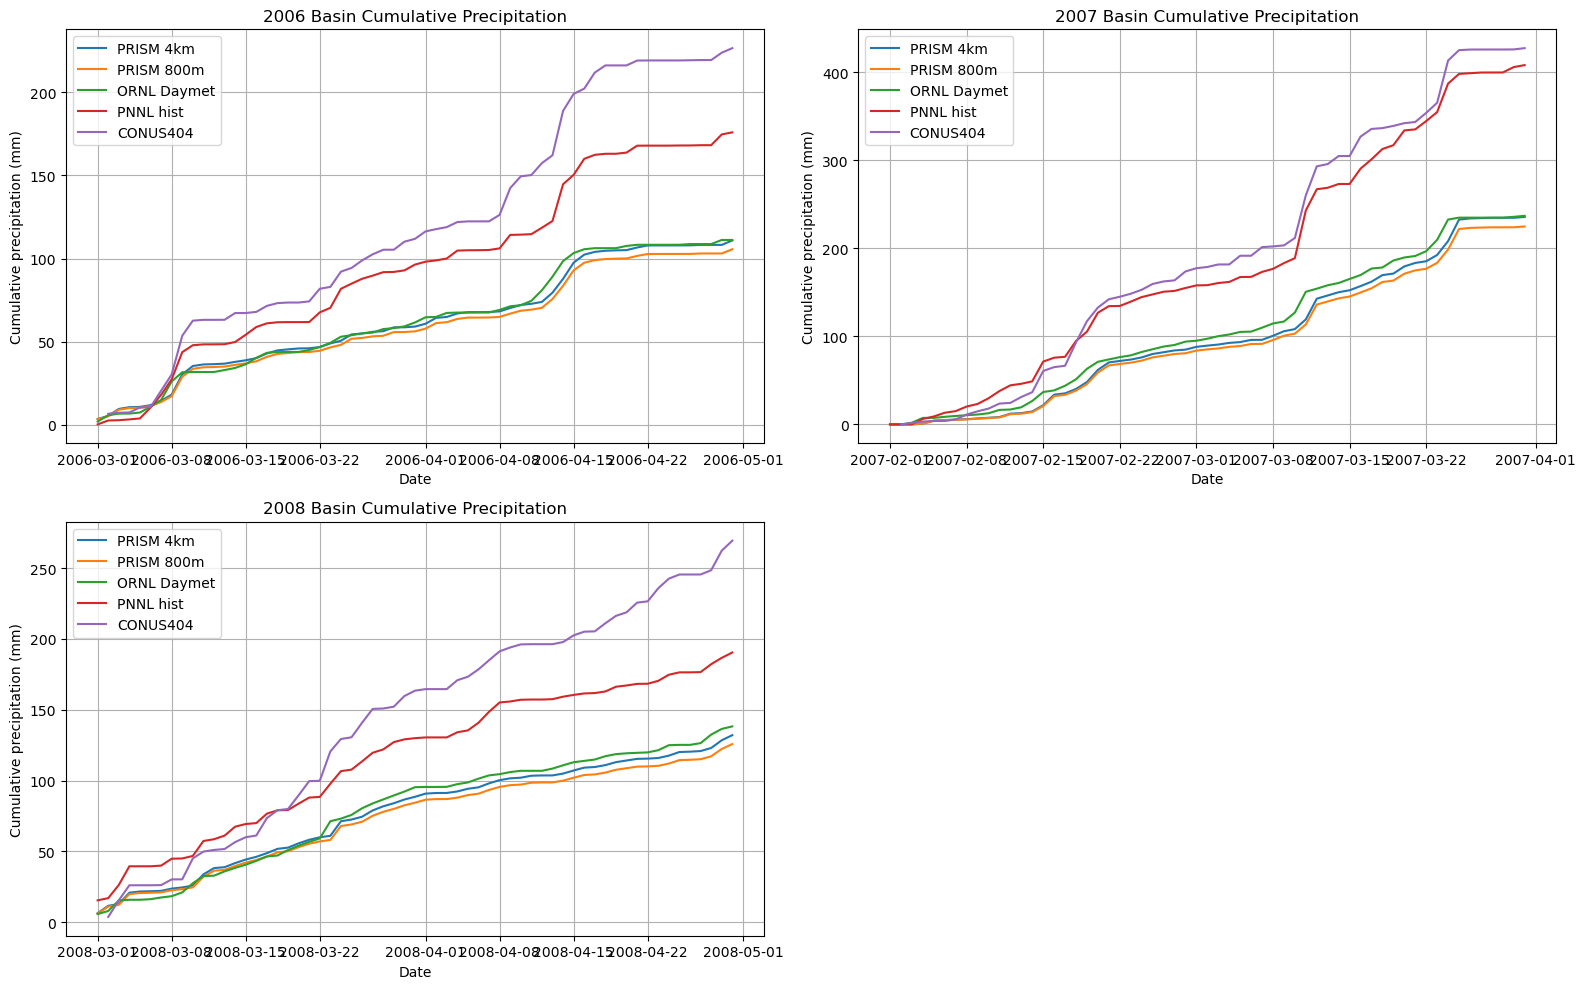

In [ ]:
# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison + VERIFICATION
# PRISM (local zarr), ORNL Daymet (local zarr),
# UCLA WRF outputs (LOCAL auxhist hourly .nc),
# PNNL hist WRF (local netcdf; dims time,x,y; geo from SERDP6km),
# CONUS404 (external OSN), SNOTEL (external)
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import requests

# for seasonal-style CONUS mask creation
import shapely
from pyproj import CRS, Transformer

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_PRISM_DIR  = BASE / "prism_nc"
P_ORNL_DIR   = BASE / "ornl_nc"

# UCLA outputs 
P_UCLA_DIR   = BASE / "ucla_wrf_outputs"

P_PNNL_DIR   = BASE / "PNNL" / "historical"
P_PNNL_GEO   = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"
BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

# External
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

SNOTEL_STATIONS_GEOJSON = (
    "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
)

# ----------------------------
# EVENTS
# ----------------------------
events = {
    2006: ("2006-03-01", "2006-04-30"),
    2007: ("2007-02-01", "2007-03-31"),
    2008: ("2008-03-01", "2008-04-30"),
}

# ----------------------------
# HELPERS
# ----------------------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    return gdf.geometry.union_all()

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    """Sum to daily totals (safe for both hourly and daily)."""
    if "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_increment(acc_like_1d):
    """
    Reset-safe increments for an accumulated series (1D time):
      inc[t] = diff if diff>=0 else current_value (reset)
    Output aligns to time[1:].
    """
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    """
    Convert accumulated precip (mm) -> increments (mm/step) -> daily totals (mm/day).
    acc_like_1d MUST be 1D (time).
    """
    bm = acc_like_1d
    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = float((d < 0).mean())
    mean_raw = float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean())
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)
    daily = ensure_daily_sum(inc)
    return daily

# ----------------------------
# VERIFICATION
# ----------------------------
def debug_daily(label, daily_da):
    """Print distribution stats for a DAILY (mm/day) 1D time series."""
    if daily_da is None or "time" not in daily_da.dims or daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (empty)")
        return
    daily_da = daily_da.dropna("time")
    if daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (all NaN)")
        return
    print(f"\n[{label}] DAILY CHECK")
    print("  min:", float(daily_da.min()))
    print("  max:", float(daily_da.max()))
    print("  mean:", float(daily_da.mean()))
    print("  sum:", float(daily_da.sum()))

def _median_dt_hours_from_da(da):
    if da is None or "time" not in da.dims:
        return None
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return None
    dt_hours = pd.Series(t).diff().dt.total_seconds().dropna().median() / 3600.0
    return float(dt_hours) if pd.notnull(dt_hours) else None

def verify_daily_and_cumsum(label, daily_da, cum_da=None, top_n=5):
    """
    Verifies:
      - dt sanity
      - daily stats
      - sum(daily) == last(cumsum) (if cum passed)
      - top-N daily increments (helps spot unit/var issues)
    """
    if daily_da is None or daily_da.size == 0:
        print(f"\n===== VERIFY: {label} =====")
        print("  (no data)")
        return

    daily_da = daily_da.dropna("time").sortby("time")
    print(f"\n===== VERIFY: {label} =====")
    dt_hours = _median_dt_hours_from_da(daily_da)
    if dt_hours is not None:
        print(f"  median dt (hours): {dt_hours:.2f}")

    debug_daily(label, daily_da)

    if cum_da is not None and is_plottable_1d(cum_da):
        try:
            cum_last = float(cum_da.dropna("time").isel(time=-1))
            daily_sum = float(daily_da.sum())
            print("  CHECK: daily.sum vs cum[-1]:", daily_sum, cum_last, " | diff:", daily_sum - cum_last)
        except Exception as e:
            print("  CHECK: daily.sum vs cum[-1]: (failed)", repr(e))

    try:
        top = daily_da.sortby(daily_da, ascending=False).isel(time=slice(0, min(top_n, daily_da.size)))
        print(f"  TOP {min(top_n, daily_da.size)} daily values:")
        for tt, vv in zip(pd.to_datetime(top["time"].values), np.asarray(top.values)):
            print("   ", tt.date(), float(vv))
    except Exception as e:
        print("  TOP daily values: (failed)", repr(e))

# ----------------------------
# MASK HELPERS
# ----------------------------
def mask_curvilinear_bool(ds, geom, lon_name="lon", lat_name="lat"):
    """Curvilinear grids with 2D lon/lat. SAFE: no meshgrid, no .values."""
    region = regionmask.Regions([geom])
    m = region.mask(ds[lon_name], ds[lat_name])  # positional args for compat
    return ~xr.ufuncs.isnan(m)

def _infer_lonlat_vars(ds):
    lon_candidates = ["lon", "longitude", "XLONG", "XLONG_M", "LON", "xlong", "xlong_m"]
    lat_candidates = ["lat", "latitude",  "XLAT",  "XLAT_M",  "LAT", "xlat",  "xlat_m"]

    def _get(name):
        if name in ds.coords:
            return ds.coords[name]
        if name in ds.data_vars:
            return ds.data_vars[name]
        return None

    lon = None
    lat = None
    for n in lon_candidates:
        lon = _get(n)
        if lon is not None:
            break
    for n in lat_candidates:
        lat = _get(n)
        if lat is not None:
            break

    if lon is None or lat is None:
        return None, None

    # squeeze any time-like dim if present
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})
    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})

    return lon, lat

def _wrf_lonlat_from_attrs(ds, ydim, xdim):
    """
    Reconstruct lon/lat from WRF projection attributes when XLAT/XLONG are missing.
    Works if ds has MAP_PROJ, TRUELAT1/2, STAND_LON, CEN_LAT, CEN_LON, DX, DY.
    """
    attrs = ds.attrs

    need = ["MAP_PROJ", "TRUELAT1", "STAND_LON", "CEN_LAT", "CEN_LON", "DX", "DY"]
    missing = [k for k in need if k not in attrs]
    if missing:
        raise RuntimeError(f"[UCLA] Missing projection attrs for lon/lat reconstruction: {missing}")

    map_proj = int(attrs["MAP_PROJ"])
    truelat1 = float(attrs["TRUELAT1"])
    truelat2 = float(attrs.get("TRUELAT2", truelat1))
    stand_lon = float(attrs["STAND_LON"])
    cen_lat = float(attrs["CEN_LAT"])
    cen_lon = float(attrs["CEN_LON"])
    dx = float(attrs["DX"])
    dy = float(attrs["DY"])

    ny = int(ds.sizes[ydim])
    nx = int(ds.sizes[xdim])

    # grid centered assumption (good enough for masking basin)
    x = (np.arange(nx) - (nx - 1) / 2.0) * dx
    y = (np.arange(ny) - (ny - 1) / 2.0) * dy
    xx, yy = np.meshgrid(x, y)

    if map_proj == 1:  # Lambert Conformal
        crs_src = CRS.from_proj4(
            f"+proj=lcc +lat_1={truelat1} +lat_2={truelat2} +lat_0={cen_lat} "
            f"+lon_0={stand_lon} +datum=WGS84 +units=m +no_defs"
        )
    elif map_proj == 3:  # Mercator
        crs_src = CRS.from_proj4(
            f"+proj=merc +lat_ts={truelat1} +lon_0={stand_lon} +datum=WGS84 +units=m +no_defs"
        )
    elif map_proj == 2:  # Polar stereographic
        crs_src = CRS.from_proj4(
            f"+proj=stere +lat_0=90 +lat_ts={truelat1} +lon_0={stand_lon} +datum=WGS84 +units=m +no_defs"
        )
    else:
        raise RuntimeError(f"[UCLA] Unsupported MAP_PROJ={map_proj} for lon/lat reconstruction")

    transformer = Transformer.from_crs(crs_src, CRS.from_epsg(4326), always_xy=True)

    # shift the projected origin so that (0,0) maps to center lon/lat
    x0, y0 = transformer.transform(0.0, 0.0)  # lon/lat at origin per CRS definition
    # We can't "set" origin in pyproj directly, but the CRS already uses lat_0/lon_0 as center.
    # So we just transform xx,yy directly.
    lon2d, lat2d = transformer.transform(xx, yy)

    lon_da = xr.DataArray(lon2d, dims=(ydim, xdim))
    lat_da = xr.DataArray(lat2d, dims=(ydim, xdim))
    return lon_da, lat_da

# ----------------------------
# PRISM
# ----------------------------
_PRISM_NAME_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_daily_(?P<tag>4km|800m)_PRISM_data\.zarr$"
)

def find_prism_zarr_covering(start, end, tag):
    start = pd.Timestamp(start)
    end   = pd.Timestamp(end)

    candidates = []
    for p in P_PRISM_DIR.glob(f"*_daily_{tag}_PRISM_data.zarr"):
        m = _PRISM_NAME_RE.search(p.name)
        if not m:
            continue
        f0 = pd.Timestamp(m.group("s"))
        f1 = pd.Timestamp(m.group("e"))
        if f0 <= start and f1 >= end:
            span_days = (f1 - f0).days
            candidates.append((span_days, f0, p))

    if not candidates:
        return None

    candidates.sort(key=lambda t: (t[0], -t[1].value))
    return candidates[0][2]

def load_prism(start, end, tag, do_verify=True):
    z = find_prism_zarr_covering(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag} [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm_daily = daily.mean(dim=spatial, skipna=True)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum(f"PRISM {tag}", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# ORNL Daymet
# ----------------------------
def load_ornl(year, start, end, do_verify=True):
    z = next(P_ORNL_DIR.glob(f"{year}_{year}_ref_*ORNL_data.zarr"), None)
    if z is None:
        print("  - ORNL Daymet: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["prcp"])
    if var is None:
        print("  - ORNL Daymet: (no prcp var)")
        ds.close()
        return None

    print_units(ds, var, f"ORNL Daymet [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm_daily = daily.mean(dim=spatial, skipna=True)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("ORNL Daymet", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# UCLA WRF 
# ----------------------------
_UCLA_MASK = None
_UCLA_MASK_KEY = None

_UCLA_AUX_RE = re.compile(
    r"cesm2_r11i1p1f1_(?P<scen>historical|ssp245)_auxhist_d01_(?P<ts>\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})\.nc$"
)

def _parse_ucla_auxhist_time(p: Path):
    m = _UCLA_AUX_RE.match(p.name)
    if not m:
        return None, None
    scen = m.group("scen")
    ts = pd.to_datetime(m.group("ts"), format="%Y-%m-%d_%H-%M-%S")
    return scen, ts

def _find_ucla_auxhist_files(start, end, scenario="historical"):
    if not P_UCLA_DIR.exists():
        return [], []

    start = pd.Timestamp(start)
    end = pd.Timestamp(end)

    files = []
    times = []
    for p in sorted(P_UCLA_DIR.glob(f"cesm2_r11i1p1f1_{scenario}_auxhist_d01_*.nc")):
        scen, ts = _parse_ucla_auxhist_time(p)
        if ts is None:
            continue
        if start <= ts <= (end + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)):
            files.append(p)
            times.append(ts)

    return files, times

def _open_ucla_auxhist_mfdataset(files, times):
    """
    Open many auxhist files (each has Time=1) into a Dataset with dim 'time'.
    """
    if not files:
        return None

    def _preprocess(dsi, ts=None):
        # Rename Time - time if present
        if "Time" in dsi.dims:
            dsi = dsi.rename({"Time": "time"})
        # force a length-1 time coordinate from filename
        if "time" in dsi.dims:
            dsi = dsi.assign_coords(time=("time", [ts]))
        else:
            # fallback: create time dim
            dsi = dsi.expand_dims({"time": [ts]})
        return dsi

    # build list of datasets with preprocess
    dsets = []
    for f, ts in zip(files, times):
        dsi = xr.open_dataset(f, chunks={"time": 1} if "time" in xr.open_dataset(f).dims else None)
        dsi = _preprocess(dsi, ts=ts)
        dsets.append(dsi)

    ds = xr.concat(dsets, dim="time")
    return ds

def load_ucla(start, end, geom, do_verify=True, scenario="historical"):
    """
    Loads UCLA WRF from hourly auxhist .nc files:
      - selects files by filename timestamps
      - concatenates to a 'time' dimension
      - builds lon/lat from XLAT/XLONG if present else from WRF projection attrs
      - builds basin mask, with orientation fallback + diagnostics
      - basin-mean, accumulated->daily if needed, cumsum
    """
    global _UCLA_MASK, _UCLA_MASK_KEY

    files, times = _find_ucla_auxhist_files(start, end, scenario=scenario)
    if not files:
        print(f"  - UCLA WRF ({scenario} auxhist): (no files for window)")
        return None

    ds = _open_ucla_auxhist_mfdataset(files, times)
    if ds is None:
        print(f"  - UCLA WRF ({scenario} auxhist): (failed to open)")
        return None

    var = pick_var(ds, ["PREC_ACC_NC", "RAINNC", "RAINC", "RAIN", "prcp", "precip", "precipitation", "ppt"])
    if var is None:
        print(f"  - UCLA WRF ({scenario} auxhist): (no precip var found)")
        print("    data_vars (first 80):", list(ds.data_vars)[:80])
        ds.close()
        return None

    print_units(ds, var, f"UCLA WRF ({scenario} auxhist)")

    da = ds[var].sel(time=slice(pd.Timestamp(start), pd.Timestamp(end))).sortby("time")
    if da.size == 0:
        print("  - UCLA WRF: (empty after time slice)")
        ds.close()
        return None

    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) != 2:
        ds.close()
        raise RuntimeError(f"[UCLA] Unexpected spatial dims for precip: {spatial}")

    ydim, xdim = spatial[0], spatial[1]
    ny, nx = int(da.sizes[ydim]), int(da.sizes[xdim])

    # lon/lat
    lon, lat = _infer_lonlat_vars(ds)
    if lon is None or lat is None:
        lon, lat = _wrf_lonlat_from_attrs(ds, ydim=ydim, xdim=xdim)

    # Basic lon/lat sanity print (first call per grid)
    try:
        lon_min, lon_max = float(lon.min()), float(lon.max())
        lat_min, lat_max = float(lat.min()), float(lat.max())
        print(f"    [UCLA] lon range: {lon_min:.3f} .. {lon_max:.3f}")
        print(f"    [UCLA] lat range: {lat_min:.3f} .. {lat_max:.3f}")
    except Exception:
        pass

    # Build mask with orientation fallback
    key = (scenario, var, tuple(spatial), ny, nx)
    if (_UCLA_MASK is None) or (_UCLA_MASK_KEY != key):
        region = regionmask.Regions([geom])
        m = region.mask(lon, lat)
        mask_geo = ~xr.ufuncs.isnan(m)

        mask_np = np.asarray(mask_geo.data).astype(bool)

        # Candidate A: as-is
        candA = mask_np
        # Candidate B: transposed
        candB = mask_np.T

        # Score candidates by how many True cells they have and matching shape
        def _score(mask):
            if mask.shape != (ny, nx):
                return -1
            return int(mask.sum())

        scoreA = _score(candA)
        scoreB = _score(candB)

        if scoreA < 0 and scoreB < 0:
            ds.close()
            raise RuntimeError(f"[UCLA] Mask shapes {candA.shape} / {candB.shape} don't match data grid {(ny,nx)}")

        best = candA if scoreA >= scoreB else candB
        best_score = max(scoreA, scoreB)
        true_frac = best_score / float(ny * nx)

        print(f"    [UCLA] mask true cells: {best_score} / {ny*nx} ({true_frac:.6f})  "
              f"(A={scoreA}, B={scoreB})")

        # If mask is basically empty, do NOT proceed (prevents silent all-zero output)
        if best_score == 0:
            ds.close()
            print("  - UCLA WRF: basin mask has 0 cells inside. lon/lat mapping is wrong for this dataset.")
            return None

        _UCLA_MASK = xr.DataArray(best.astype(bool), dims=(ydim, xdim))
        _UCLA_MASK_KEY = key

    # Basin mean
    bm = da.where(_UCLA_MASK).mean(dim=spatial, skipna=True)

    # If bm is all NaN, bail (also prevents silent zero)
    if not np.isfinite(np.asarray(bm.isel(time=0).data)).any():
        ds.close()
        print("  - UCLA WRF: basin-mean is NaN (mask/grid mismatch). Returning None.")
        return None

    # Accum vs rate
    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = (
        ("accum" in var.lower()) or ("accumul" in desc) or
        (var.upper() in ("RAINNC", "RAINC", "RAIN", "PREC_ACC_NC"))
    )
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label="UCLA WRF accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum(f"UCLA WRF ({scenario} auxhist)", bm_daily, cum)

    ds.close()
    return cum


# ----------------------------
# PNNL HIST WRF
# ----------------------------
_PNNL_MASK_XY = None
_PNNL_MASK_KEY = None

def build_pnnl_mask_for_ds(ds_prec, geom):
    spatial = [d for d in ds_prec["PREC_ACC_NC"].dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = ds_prec.sizes[d0], ds_prec.sizes[d1]

    geo = xr.open_dataset(P_PNNL_GEO)

    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat = geo[lat_name]
    lon = geo[lon_name]

    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)

    mask_np = np.asarray(mask_geo.data).astype(bool)
    geo.close()

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[PNNL] Mask shape {mask_np.shape} does not match precip grid "
            f"({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_pnnl(year, start, end, geom, do_verify=True):
    global _PNNL_MASK_XY, _PNNL_MASK_KEY

    f = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", "PNNL hist")

    spatial = [d for d in ds["PREC_ACC_NC"].dims if d != "time"]
    key = (tuple(spatial), ds.sizes[spatial[0]], ds.sizes[spatial[1]])
    if (_PNNL_MASK_XY is None) or (_PNNL_MASK_KEY != key):
        _PNNL_MASK_XY = build_pnnl_mask_for_ds(ds, geom)
        _PNNL_MASK_KEY = key

    da = ds["PREC_ACC_NC"].sel(time=slice(start, end)).sortby("time")
    bm_acc = da.where(_PNNL_MASK_XY).mean(dim=spatial, skipna=True)

    bm_daily = accumulated_to_daily_mm(bm_acc, label="PNNL hist")
    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("PNNL hist", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# CONUS404 (seasonal-style mask)
# ----------------------------
_conus_ds = None
_conus_mask = None  # cached xr.DataArray boolean mask on (y,x)

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus(start, end, geom, do_verify=True):
    global _conus_mask

    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()

    var = pick_var(ds, [
        "prcp", "precip", "precipitation", "PREC", "PRECIP",
        "RAIN", "RAINNC", "RAINC", "PREC_ACC_NC"
    ])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    if _conus_mask is None:
        lon = ds["lon"]
        lat = ds["lat"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)  # (y,x) boolean numpy
        _conus_mask = xr.DataArray(mask_np, dims=("y", "x"))

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    bm = da.where(_conus_mask).mean(dim=("y", "x"), skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = ("accum" in var.lower()) or ("accumul" in desc) or (var.upper() in ("RAINNC", "RAINC", "PREC_ACC_NC"))
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label="CONUS404 accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("CONUS404", bm_daily, cum)

    return cum

# ----------------------------
# SNOTEL
# ----------------------------
def load_snotel(start, end, geom, do_verify=True):
    stations = gpd.read_file(SNOTEL_STATIONS_GEOJSON).to_crs("EPSG:4326")
    basin = gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")
    sel = gpd.sjoin(stations, basin, predicate="intersects", how="inner")

    if sel.empty:
        print("  - SNOTEL: no stations in basin")
        return None

    if "code" not in sel.columns:
        print("  - SNOTEL: expected 'code' column not found")
        print("    Available columns:", list(sel.columns))
        return None

    triplets = sorted(set(sel["code"].dropna().astype(str).tolist()))
    if not triplets:
        print("  - SNOTEL: no valid station triplets")
        return None

    url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data/getDaily"
    params = {
        "stationTriplets": ",".join(triplets),
        "elements": "PRCPSA",
        "beginDate": start,
        "endDate": end,
        "format": "json",
    }

    try:
        rr = requests.get(url, params=params, timeout=120)
        if rr.status_code != 200:
            print("  - SNOTEL: AWDB request failed")
            print("    status:", rr.status_code)
            print("    url:", rr.url)
            return None
        js = rr.json()
    except Exception as e:
        print("  - SNOTEL: AWDB request error:", repr(e))
        return None

    data = {}
    for st in js:
        trip = st.get("stationTriplet")
        vals = st.get("values", [])
        if not trip or not vals:
            continue
        s = {pd.to_datetime(v["date"]): (np.nan if v["value"] is None else float(v["value"])) for v in vals}
        data[trip] = pd.Series(s)

    if not data:
        print("  - SNOTEL: AWDB returned no data")
        return None

    df_in = pd.DataFrame(data).sort_index()
    print(f"  - SNOTEL: var='PRCPSA', units='inches → mm', stations={df_in.shape[1]}")

    df_mm = df_in * 25.4
    daily_mean = df_mm.mean(axis=1, skipna=True).loc[pd.to_datetime(start):pd.to_datetime(end)].asfreq("D")

    bm_daily = xr.DataArray(
        daily_mean.values,
        coords={"time": daily_mean.index},
        dims=("time",),
        name="SNOTEL",
    )
    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("SNOTEL", bm_daily, cum)

    return cum

# ----------------------------
# MAIN
# ----------------------------
def main():
    geom = load_basin_geom()

    n = len(events)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axs = np.array(axs).reshape(-1)

    for i, (yr, (start, end)) in enumerate(events.items()):
        ax = axs[i]
        print(f"\n================ {yr} ({start} → {end}) ================")

        series = [
            ("PRISM 4km",    load_prism(start, end, "4km", do_verify=True)),
            ("PRISM 800m",   load_prism(start, end, "800m", do_verify=True)),
            ("ORNL Daymet",  load_ornl(yr, start, end, do_verify=True)),
            ("UCLA WRF",     load_ucla(start, end, geom, do_verify=True, scenario="historical")),
            ("PNNL hist",    load_pnnl(yr, start, end, geom, do_verify=True)),
            ("CONUS404",     load_conus(start, end, geom, do_verify=True)),
            ("SNOTEL",       load_snotel(start, end, geom, do_verify=True)),
        ]

        plotted_any = False
        for label, da in series:
            if is_plottable_1d(da):
                ax.plot(pd.to_datetime(da["time"].values), da.values, label=label)
                plotted_any = True

        ax.set_title(f"{yr} Basin Cumulative Precipitation")
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative precipitation (mm)")
        ax.grid(True)
        if plotted_any:
            ax.legend()

    for j in range(len(events), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


================ 2006 (2006-03-01 → 2006-04-30) ================
  - PRISM 4km [2006-01-01_2006-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km =====
  median dt (hours): 24.00

[PRISM 4km] DAILY CHECK
  min: 0.0
  max: 12.21356201171875
  mean: 1.8172951936721802
  sum: 110.8550033569336
  CHECK: daily.sum vs cum[-1]: 110.8550033569336 110.8550033569336  | diff: 0.0
  TOP 5 daily values:
    2006-03-09 12.21356201171875
    2006-04-15 9.725650787353516
    2006-04-14 8.325936317443848
    2006-04-13 5.547675609588623
    2006-03-10 4.998325824737549
  - PRISM 800m [2006-01-01_2006-12-31_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 800m =====
  median dt (hours): 24.00

[PRISM 800m] DAILY CHECK
  min: 0.0
  max: 11.651607513427734
  mean: 1.7307782173156738
  sum: 105.57746887207031
  CHECK: daily.sum vs cum[-1]: 105.57746887207031 105.57747650146484  | diff: -7.62939453125e-06
  TOP 5 daily values:
    2006-03-

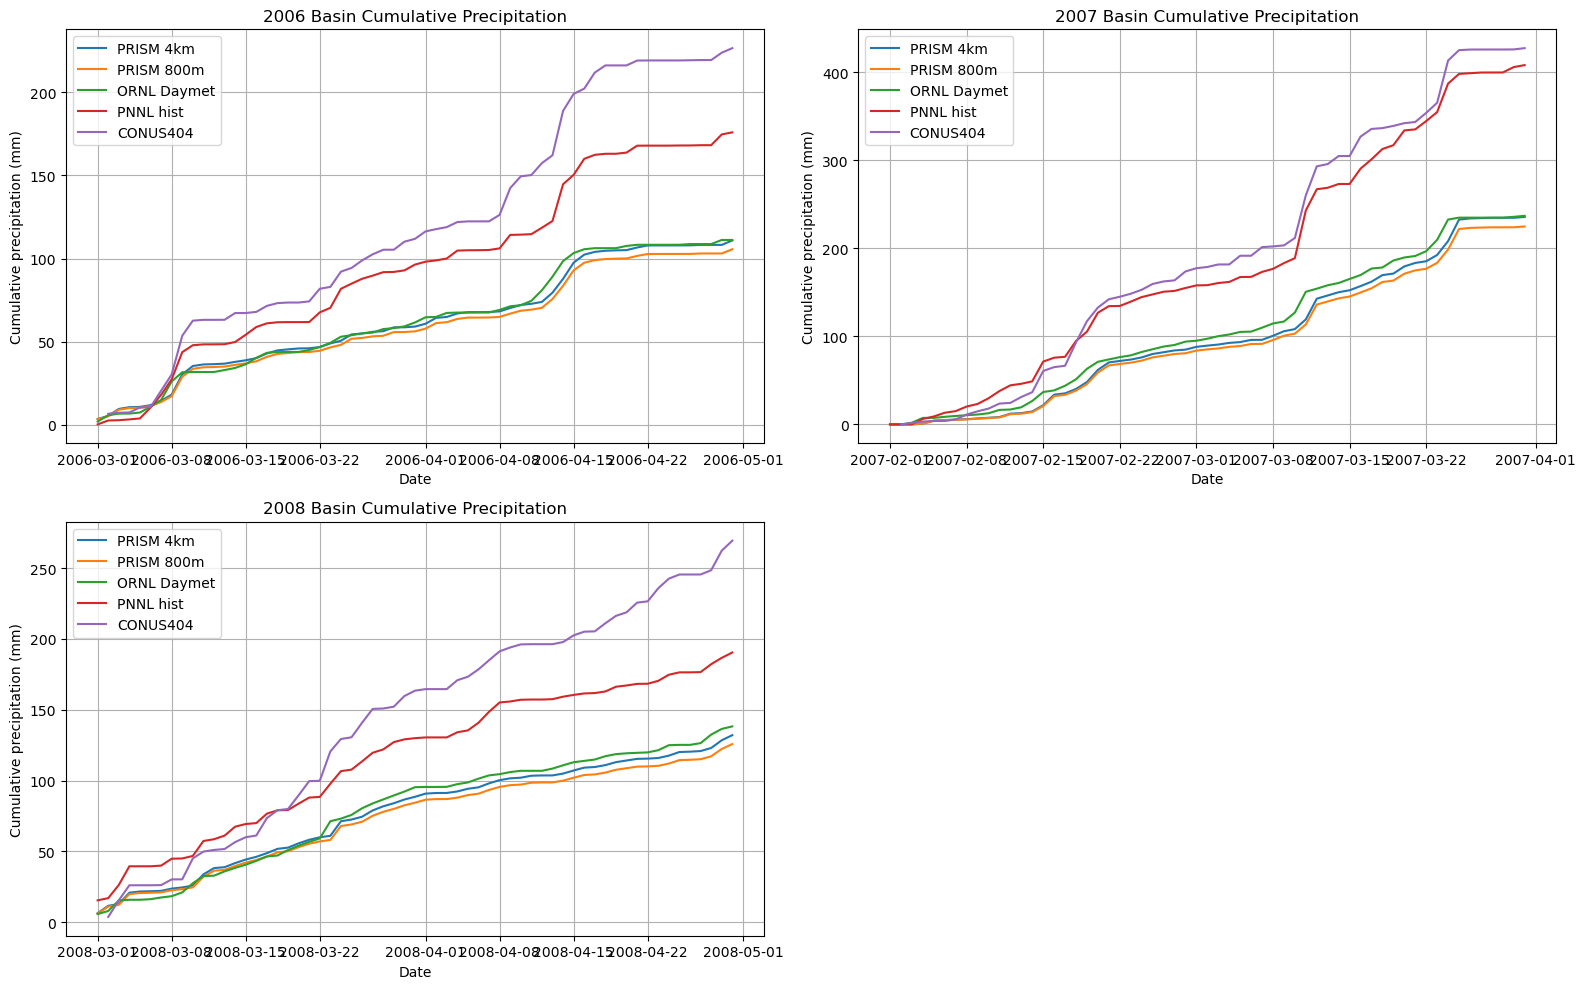


Saved MAE CSV → /data0/balaji24/data/derived/event_mae_vs_prism4km_mm_per_day.csv
    event_year       start         end  reference      dataset  \
0         2006  2006-03-01  2006-04-30  PRISM 4km     CONUS404   
1         2006  2006-03-01  2006-04-30  PRISM 4km  ORNL Daymet   
2         2006  2006-03-01  2006-04-30  PRISM 4km    PNNL hist   
3         2006  2006-03-01  2006-04-30  PRISM 4km   PRISM 800m   
4         2007  2007-02-01  2007-03-31  PRISM 4km     CONUS404   
5         2007  2007-02-01  2007-03-31  PRISM 4km  ORNL Daymet   
6         2007  2007-02-01  2007-03-31  PRISM 4km    PNNL hist   
7         2007  2007-02-01  2007-03-31  PRISM 4km   PRISM 800m   
8         2008  2008-03-01  2008-04-30  PRISM 4km     CONUS404   
9         2008  2008-03-01  2008-04-30  PRISM 4km  ORNL Daymet   
10        2008  2008-03-01  2008-04-30  PRISM 4km    PNNL hist   
11        2008  2008-03-01  2008-04-30  PRISM 4km   PRISM 800m   

    mae_mm_per_day  n_days  
0         2.632993      59  


In [ ]:
# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison + VERIFICATION
# PRISM (local zarr), ORNL Daymet (local zarr),
# UCLA WRF outputs (local zarr; your ucla_wrf_outputs naming),
# PNNL hist WRF (local netcdf; dims time,x,y; geo from SERDP6km),
# CONUS404 (external OSN), SNOTEL (external)
#
# Outputs: one subplot per event window, cumulative precip (mm)
# Prints: variable units + key diagnostics (accum handling)
# Adds: verification prints for daily series + mass-balance checks
#
# Added:
# - PRISM as standard (PRISM 4km) and compute MAE (mm/day) for all other datasets per event
# - Saves MAE CSV
#
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import requests

# NEW: for seasonal-style CONUS mask creation
import shapely

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_PRISM_DIR  = BASE / "prism_nc"
P_ORNL_DIR   = BASE / "ornl_nc"

# UCLA outputs
P_UCLA_DIR   = BASE / "ucla_wrf_outputs"

P_PNNL_DIR   = BASE / "PNNL" / "historical"
P_PNNL_GEO   = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"
BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

# External
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

SNOTEL_STATIONS_GEOJSON = (
    "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
)

# OUTPUTS
OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
MAE_CSV_OUT = OUT / "event_mae_vs_prism4km_mm_per_day.csv"

# ----------------------------
# EVENTS
# ----------------------------
events = {
    2006: ("2006-03-01", "2006-04-30"),
    2007: ("2007-02-01", "2007-03-31"),
    2008: ("2008-03-01", "2008-04-30"),
}

# ----------------------------
# HELPERS
# ----------------------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    return gdf.geometry.union_all()

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    """Sum to daily totals (safe for both hourly and daily)."""
    if "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_increment(acc_like_1d):
    """
    Reset-safe increments for an accumulated series (1D time):
      inc[t] = diff if diff>=0 else current_value (reset)
    Output aligns to time[1:].
    """
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    """
    Convert accumulated precip (mm) -> increments (mm/step) -> daily totals (mm/day).
    acc_like_1d MUST be 1D (time).
    """
    bm = acc_like_1d
    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = float((d < 0).mean())
    mean_raw = float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean())
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)
    daily = ensure_daily_sum(inc)
    return daily

# ----------------------------
# VERIFICATION
# ----------------------------
def debug_daily(label, daily_da):
    """Print distribution stats for a DAILY (mm/day) 1D time series."""
    if daily_da is None or "time" not in daily_da.dims or daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (empty)")
        return
    daily_da = daily_da.dropna("time")
    if daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (all NaN)")
        return
    print(f"\n[{label}] DAILY CHECK")
    print("  min:", float(daily_da.min()))
    print("  max:", float(daily_da.max()))
    print("  mean:", float(daily_da.mean()))
    print("  sum:", float(daily_da.sum()))

def _median_dt_hours_from_da(da):
    if da is None or "time" not in da.dims:
        return None
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return None
    dt_hours = pd.Series(t).diff().dt.total_seconds().dropna().median() / 3600.0
    return float(dt_hours) if pd.notnull(dt_hours) else None

def verify_daily_and_cumsum(label, daily_da, cum_da=None, top_n=5):
    """
    Verifies:
      - dt sanity
      - daily stats
      - sum(daily) == last(cumsum) (if cum passed)
      - top-N daily increments (helps spot unit/var issues)
    """
    if daily_da is None or daily_da.size == 0:
        print(f"\n===== VERIFY: {label} =====")
        print("  (no data)")
        return

    daily_da = daily_da.dropna("time").sortby("time")
    print(f"\n===== VERIFY: {label} =====")
    dt_hours = _median_dt_hours_from_da(daily_da)
    if dt_hours is not None:
        print(f"  median dt (hours): {dt_hours:.2f}")

    debug_daily(label, daily_da)

    # mass balance with cumsum if provided
    if cum_da is not None and is_plottable_1d(cum_da):
        try:
            cum_last = float(cum_da.dropna("time").isel(time=-1))
            daily_sum = float(daily_da.sum())
            print("  CHECK: daily.sum vs cum[-1]:", daily_sum, cum_last, " | diff:", daily_sum - cum_last)
        except Exception as e:
            print("  CHECK: daily.sum vs cum[-1]: (failed)", repr(e))

    # top N days
    try:
        top = daily_da.sortby(daily_da, ascending=False).isel(time=slice(0, min(top_n, daily_da.size)))
        print(f"  TOP {min(top_n, daily_da.size)} daily values:")
        for tt, vv in zip(pd.to_datetime(top["time"].values), np.asarray(top.values)):
            print("   ", tt.date(), float(vv))
    except Exception as e:
        print("  TOP daily values: (failed)", repr(e))

# ----------------------------
# MAE helpers (PRISM standard)
# ----------------------------
def cum_to_daily_from_cum(cum_1d):
    """
    Convert a cumulative 1D series to daily increments (mm/day).
    Works even if cum is already daily-cumsum.
    Output time is aligned to cum.time[1:].
    """
    if cum_1d is None or "time" not in cum_1d.dims or cum_1d.size < 2:
        return None
    cum_1d = cum_1d.dropna("time").sortby("time")
    d = cum_1d.diff("time")
    # should be >= 0; clip negatives (rare numeric issues)
    d = d.clip(min=0)
    return d

def mae_vs_ref_daily(ref_cum, other_cum):
    """
    MAE in mm/day between daily increments derived from cumulative curves.
    Align on overlapping timestamps.
    """
    ref_d = cum_to_daily_from_cum(ref_cum)
    oth_d = cum_to_daily_from_cum(other_cum)
    if ref_d is None or oth_d is None or ref_d.size == 0 or oth_d.size == 0:
        return np.nan, 0

    ref_d, oth_d = xr.align(ref_d, oth_d, join="inner")
    if ref_d.size == 0:
        return np.nan, 0

    err = (oth_d - ref_d).astype("float64")
    mae = float(np.nanmean(np.abs(err.values)))
    n = int(np.sum(np.isfinite(err.values)))
    return mae, n

# ----------------------------
# MASKS
# ----------------------------
def mask_curvilinear_bool(ds, geom, lon_name="lon", lat_name="lat"):
    """
    Curvilinear grids with 2D lon/lat.
    SAFE: no meshgrid, no .values.
    """
    region = regionmask.Regions([geom])
    m = region.mask(ds[lon_name], ds[lat_name])  # positional args for compat
    return ~xr.ufuncs.isnan(m)

def _infer_lonlat_vars(ds):
    """
    Find lon/lat arrays in either coords or data_vars.
    Works for typical WRF outputs (XLONG/XLAT) and also lon/lat.
    Returns (lon_da, lat_da) or (None, None).
    """
    lon_candidates = ["lon", "longitude", "XLONG", "XLONG_M", "LON", "xlong", "xlong_m"]
    lat_candidates = ["lat", "latitude",  "XLAT",  "XLAT_M",  "LAT", "xlat",  "xlat_m"]

    def _get(name):
        if name in ds.coords:
            return ds.coords[name]
        if name in ds.data_vars:
            return ds.data_vars[name]
        return None

    lon = None
    lat = None
    for n in lon_candidates:
        lon = _get(n)
        if lon is not None:
            break
    for n in lat_candidates:
        lat = _get(n)
        if lat is not None:
            break

    if lon is None or lat is None:
        return None, None

    # squeeze any time-like dim if present (WRF often has Time)
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})
    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})

    return lon, lat

# ----------------------------
# PRISM (covers-window match)
# ----------------------------
import re

_PRISM_NAME_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_daily_(?P<tag>4km|800m)_PRISM_data\.zarr$"
)

def find_prism_zarr_covering(start, end, tag):
    """
    Find a PRISM zarr whose filename date-range fully covers [start,end].
    Prefers the smallest covering file (event-specific over full-year).
    """
    start = pd.Timestamp(start)
    end   = pd.Timestamp(end)

    candidates = []
    for p in P_PRISM_DIR.glob(f"*_daily_{tag}_PRISM_data.zarr"):
        m = _PRISM_NAME_RE.search(p.name)
        if not m:
            continue
        f0 = pd.Timestamp(m.group("s"))
        f1 = pd.Timestamp(m.group("e"))
        if f0 <= start and f1 >= end:
            span_days = (f1 - f0).days
            candidates.append((span_days, f0, p))

    if not candidates:
        return None

    # smallest span first; if tie, later start first
    candidates.sort(key=lambda t: (t[0], -t[1].value))
    return candidates[0][2]

def load_prism(start, end, tag, do_verify=True):
    z = find_prism_zarr_covering(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag} [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm_daily = daily.mean(dim=spatial, skipna=True)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum(f"PRISM {tag}", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# ORNL Daymet
# ----------------------------
def load_ornl(year, start, end, do_verify=True):
    z = next(P_ORNL_DIR.glob(f"{year}_{year}_ref_*ORNL_data.zarr"), None)
    if z is None:
        print("  - ORNL Daymet: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["prcp"])
    if var is None:
        print("  - ORNL Daymet: (no prcp var)")
        ds.close()
        return None

    print_units(ds, var, f"ORNL Daymet [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm_daily = daily.mean(dim=spatial, skipna=True)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("ORNL Daymet", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# UCLA WRF OUTPUTS 
# ----------------------------
_UCLA_MASK = None
_UCLA_MASK_KEY = None

def _parse_ucla_event_zarr_name(p: Path):
    """
    Expected patterns:
      {start}_{end}_wrf_cesm2_r11i1p1f1_historical_data.zarr
      {start}_{end}_wrf_cesm2_r11i1p1f1_ssp245_data.zarr
    """
    name = p.name
    if not name.endswith(".zarr"):
        return None, None, None
    parts = name.split("_")
    if len(parts) < 3:
        return None, None, None
    try:
        s0 = pd.to_datetime(parts[0])
        s1 = pd.to_datetime(parts[1])
    except Exception:
        return None, None, None

    scenario = "historical" if "historical" in name else ("ssp245" if "ssp245" in name else "unknown")
    return s0, s1, scenario

def find_ucla_zarr_event(start, end):
    """
    Finder for UCLA event zarrs.
    Allows end-date mismatch ±2 days (e.g., 1995 file ends 12-09).
    """
    if not P_UCLA_DIR.exists():
        return None

    s0 = pd.to_datetime(start)
    s1 = pd.to_datetime(end)

    exact = P_UCLA_DIR / f"{s0:%Y-%m-%d}_{s1:%Y-%m-%d}_wrf_cesm2_r11i1p1f1_historical_data.zarr"
    if exact.exists():
        return exact

    exact_ssp = P_UCLA_DIR / f"{s0:%Y-%m-%d}_{s1:%Y-%m-%d}_wrf_cesm2_r11i1p1f1_ssp245_data.zarr"
    if exact_ssp.exists():
        return exact_ssp

    candidates = sorted(P_UCLA_DIR.glob(f"{s0:%Y-%m-%d}_*_wrf_cesm2_r11i1p1f1_*_data.zarr"))
    if not candidates:
        candidates = sorted(P_UCLA_DIR.glob(f"{s0:%Y-%m-%d}_*_wrf_*_data.zarr"))

    best = None
    best_score = None
    for p in candidates:
        c0, c1, _scen = _parse_ucla_event_zarr_name(p)
        if c0 is None:
            continue
        if c0.normalize() != s0.normalize():
            continue
        score = abs((c1.normalize() - s1.normalize()).days)
        if best is None or score < best_score:
            best = p
            best_score = score

    if best is not None and best_score is not None and best_score <= 2:
        return best
    return None

def build_ucla_mask_for_da(da_precip, ds_ucla, geom):
    spatial = [d for d in da_precip.dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[UCLA] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = da_precip.sizes[d0], da_precip.sizes[d1]

    lon, lat = _infer_lonlat_vars(ds_ucla)
    if lon is None or lat is None:
        raise RuntimeError("[UCLA] Could not infer lon/lat arrays")

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)

    mask_np = np.asarray(mask_geo.data).astype(bool)

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[UCLA] Mask shape {mask_np.shape} does not match precip grid "
            f"({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_ucla(start, end, geom, do_verify=True):
    global _UCLA_MASK, _UCLA_MASK_KEY

    z = find_ucla_zarr_event(start, end)
    if z is None:
        print("  - UCLA WRF: (not available)")
        return None

    ds = safe_open_zarr(z)

    var = pick_var(ds, ["PREC_ACC_NC", "RAINNC", "RAINC", "RAIN", "prcp", "precip", "precipitation", "ppt"])
    if var is None:
        print(f"  - UCLA WRF [{z.name}]: (no precip var found)")
        print(f"    data_vars (first 60): {list(ds.data_vars)[:60]}")
        ds.close()
        return None

    print_units(ds, var, f"UCLA WRF [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    spatial = [d for d in da.dims if d != "time"]

    key = (z.as_posix(), var, tuple(spatial), da.sizes[spatial[0]], da.sizes[spatial[1]])
    if (_UCLA_MASK is None) or (_UCLA_MASK_KEY != key):
        _UCLA_MASK = build_ucla_mask_for_da(da, ds, geom)
        _UCLA_MASK_KEY = key

    bm = da.where(_UCLA_MASK).mean(dim=spatial, skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = (
        ("accum" in var.lower()) or ("accumul" in desc) or
        (var.upper() in ("RAINNC", "RAINC", "RAIN", "PREC_ACC_NC"))
    )
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label="UCLA WRF accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("UCLA WRF", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# PNNL HIST WRF (dims time,x,y) – SAFE MASK BUILD
# ----------------------------
_PNNL_MASK_XY = None
_PNNL_MASK_KEY = None

def build_pnnl_mask_for_ds(ds_prec, geom):
    spatial = [d for d in ds_prec["PREC_ACC_NC"].dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = ds_prec.sizes[d0], ds_prec.sizes[d1]

    geo = xr.open_dataset(P_PNNL_GEO)

    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat = geo[lat_name]
    lon = geo[lon_name]

    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)

    mask_np = np.asarray(mask_geo.data).astype(bool)
    geo.close()

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[PNNL] Mask shape {mask_np.shape} does not match precip grid "
            f"({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_pnnl(year, start, end, geom, do_verify=True):
    global _PNNL_MASK_XY, _PNNL_MASK_KEY

    f = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", "PNNL hist")

    spatial = [d for d in ds["PREC_ACC_NC"].dims if d != "time"]
    key = (tuple(spatial), ds.sizes[spatial[0]], ds.sizes[spatial[1]])
    if (_PNNL_MASK_XY is None) or (_PNNL_MASK_KEY != key):
        _PNNL_MASK_XY = build_pnnl_mask_for_ds(ds, geom)
        _PNNL_MASK_KEY = key

    da = ds["PREC_ACC_NC"].sel(time=slice(start, end)).sortby("time")
    bm_acc = da.where(_PNNL_MASK_XY).mean(dim=spatial, skipna=True)

    bm_daily = accumulated_to_daily_mm(bm_acc, label="PNNL hist")
    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("PNNL hist", bm_daily, cum)

    ds.close()
    return cum

# ----------------------------
# CONUS404 (external) — seasonal-style loader
# ----------------------------
_conus_ds = None
_conus_mask = None  # cached xr.DataArray boolean mask on (y,x)

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus(start, end, geom, do_verify=True):
    """
    Seasonal-style CONUS loading:
      - build mask via shapely.contains_xy(geom, lon.values, lat.values)
      - cache mask globally
      - basin mean on native grid
    """
    global _conus_mask

    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()

    var = pick_var(ds, [
        "prcp", "precip", "precipitation", "PREC", "PRECIP",
        "RAIN", "RAINNC", "RAINC",
        "PREC_ACC_NC"
    ])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    # seasonal-style mask build (NOTE: materializes full lon/lat in RAM)
    if _conus_mask is None:
        lon = ds["lon"]
        lat = ds["lat"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)  # (y,x) boolean numpy
        _conus_mask = xr.DataArray(mask_np, dims=("y", "x"))

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    bm = da.where(_conus_mask).mean(dim=("y", "x"), skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = ("accum" in var.lower()) or ("accumul" in desc) or (var.upper() in ("RAINNC", "RAINC", "PREC_ACC_NC"))
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label="CONUS404 accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("CONUS404", bm_daily, cum)

    return cum

# ----------------------------
# SNOTEL (external)
# ----------------------------
def load_snotel(start, end, geom, do_verify=True):
    """
    Uses the GeoJSON's 'code' field as stationTriplet (your GeoJSON does NOT expose 'triplet').
    AWDB endpoint can be flaky; this function fails soft (prints error and returns None).
    """
    stations = gpd.read_file(SNOTEL_STATIONS_GEOJSON).to_crs("EPSG:4326")
    basin = gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")
    sel = gpd.sjoin(stations, basin, predicate="intersects", how="inner")

    if sel.empty:
        print("  - SNOTEL: no stations in basin")
        return None

    if "code" not in sel.columns:
        print("  - SNOTEL: expected 'code' column not found")
        print("    Available columns:", list(sel.columns))
        return None

    triplets = sorted(set(sel["code"].dropna().astype(str).tolist()))
    if not triplets:
        print("  - SNOTEL: no valid station triplets")
        return None

    url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data/getDaily"
    params = {
        "stationTriplets": ",".join(triplets),
        "elements": "PRCPSA",
        "beginDate": start,
        "endDate": end,
        "format": "json",
    }

    try:
        rr = requests.get(url, params=params, timeout=120)
        if rr.status_code != 200:
            print("  - SNOTEL: AWDB request failed")
            print("    status:", rr.status_code)
            print("    url:", rr.url)
            return None
        js = rr.json()
    except Exception as e:
        print("  - SNOTEL: AWDB request error:", repr(e))
        return None

    data = {}
    for st in js:
        trip = st.get("stationTriplet")
        vals = st.get("values", [])
        if not trip or not vals:
            continue
        s = {pd.to_datetime(v["date"]): (np.nan if v["value"] is None else float(v["value"])) for v in vals}
        data[trip] = pd.Series(s)

    if not data:
        print("  - SNOTEL: AWDB returned no data")
        return None

    df_in = pd.DataFrame(data).sort_index()
    print(f"  - SNOTEL: var='PRCPSA', units='inches → mm', stations={df_in.shape[1]}")

    df_mm = df_in * 25.4
    daily_mean = df_mm.mean(axis=1, skipna=True).loc[pd.to_datetime(start):pd.to_datetime(end)].asfreq("D")

    bm_daily = xr.DataArray(
        daily_mean.values,
        coords={"time": daily_mean.index},
        dims=("time",),
        name="SNOTEL",
    )
    cum = bm_daily.cumsum("time")

    if do_verify:
        verify_daily_and_cumsum("SNOTEL", bm_daily, cum)

    return cum

# ----------------------------
# MAIN
# ----------------------------
def main():
    geom = load_basin_geom()

    n = len(events)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axs = np.array(axs).reshape(-1)

    mae_rows = []  # store MAE results per event

    for i, (yr, (start, end)) in enumerate(events.items()):
        ax = axs[i]
        print(f"\n================ {yr} ({start} → {end}) ================")

        series = [
            ("PRISM 4km",    load_prism(start, end, "4km", do_verify=True)),
            ("PRISM 800m",   load_prism(start, end, "800m", do_verify=True)),
            ("ORNL Daymet",  load_ornl(yr, start, end, do_verify=True)),
            ("UCLA WRF",     load_ucla(start, end, geom, do_verify=True)),
            ("PNNL hist",    load_pnnl(yr, start, end, geom, do_verify=True)),
            ("CONUS404",     load_conus(start, end, geom, do_verify=True)),
            ("SNOTEL",       load_snotel(start, end, geom, do_verify=True)),
        ]

        # ----------------------------
        # Plot cumulative curves
        # ----------------------------
        plotted_any = False
        for label, da in series:
            if is_plottable_1d(da):
                ax.plot(pd.to_datetime(da["time"].values), da.values, label=label)
                plotted_any = True

        ax.set_title(f"{yr} Basin Cumulative Precipitation")
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative precipitation (mm)")
        ax.grid(True)
        if plotted_any:
            ax.legend()

        # ----------------------------
        # NEW: MAE vs PRISM 4km (mm/day)
        # - If PRISM 4km missing, fallback to PRISM 800m
        # ----------------------------
        ref_label = "PRISM 4km"
        ref_cum = dict(series).get(ref_label, None)
        if not is_plottable_1d(ref_cum):
            ref_label = "PRISM 800m"
            ref_cum = dict(series).get(ref_label, None)

        print("\n[MAE vs PRISM] reference =", ref_label)
        if not is_plottable_1d(ref_cum):
            print("  -> No PRISM reference available for MAE. Skipping MAE for this event.")
            continue

        for label, da in series:
            if label == ref_label:
                continue
            if not is_plottable_1d(da):
                continue
            mae, n_days = mae_vs_ref_daily(ref_cum, da)
            mae_rows.append({
                "event_year": yr,
                "start": start,
                "end": end,
                "reference": ref_label,
                "dataset": label,
                "mae_mm_per_day": mae,
                "n_days": n_days,
            })
            print(f"  {label:12s}  MAE={mae:.3f} mm/day   n_days={n_days}")

    for j in range(len(events), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Save MAE CSV
    # ----------------------------
    if mae_rows:
        mae_df = pd.DataFrame(mae_rows).sort_values(["event_year", "dataset"]).reset_index(drop=True)
        mae_df.to_csv(MAE_CSV_OUT, index=False)
        print("\nSaved MAE CSV →", MAE_CSV_OUT)
        print(mae_df)
    else:
        print("\nNo MAE rows computed (no overlaps / missing PRISM).")

if __name__ == "__main__":
    main()



================ 2012 (2012-05-01 → 2012-06-30) ================
  - PRISM 4km [2012-01-01_2012-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km =====
  median dt (hours): 24.00

[PRISM 4km] DAILY CHECK
  min: 0.0
  max: 11.230923652648926
  mean: 1.896234154701233
  sum: 115.67028045654297
  CHECK: daily.sum vs cum[-1]: 115.67028045654297 115.67027282714844  | diff: 7.62939453125e-06
  TOP 5 daily values:
    2012-05-22 11.230923652648926
    2012-05-01 10.855676651000977
    2012-06-17 9.276529312133789
    2012-05-21 6.150530815124512
    2012-06-08 5.7481369972229
  - PRISM 800m [2012-01-01_2012-12-31_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 800m =====
  median dt (hours): 24.00

[PRISM 800m] DAILY CHECK
  min: 0.0
  max: 10.644648551940918
  mean: 1.8053030967712402
  sum: 110.12348937988281
  CHECK: daily.sum vs cum[-1]: 110.12348937988281 110.12348937988281  | diff: 0.0
  TOP 5 daily values:
    2012-0

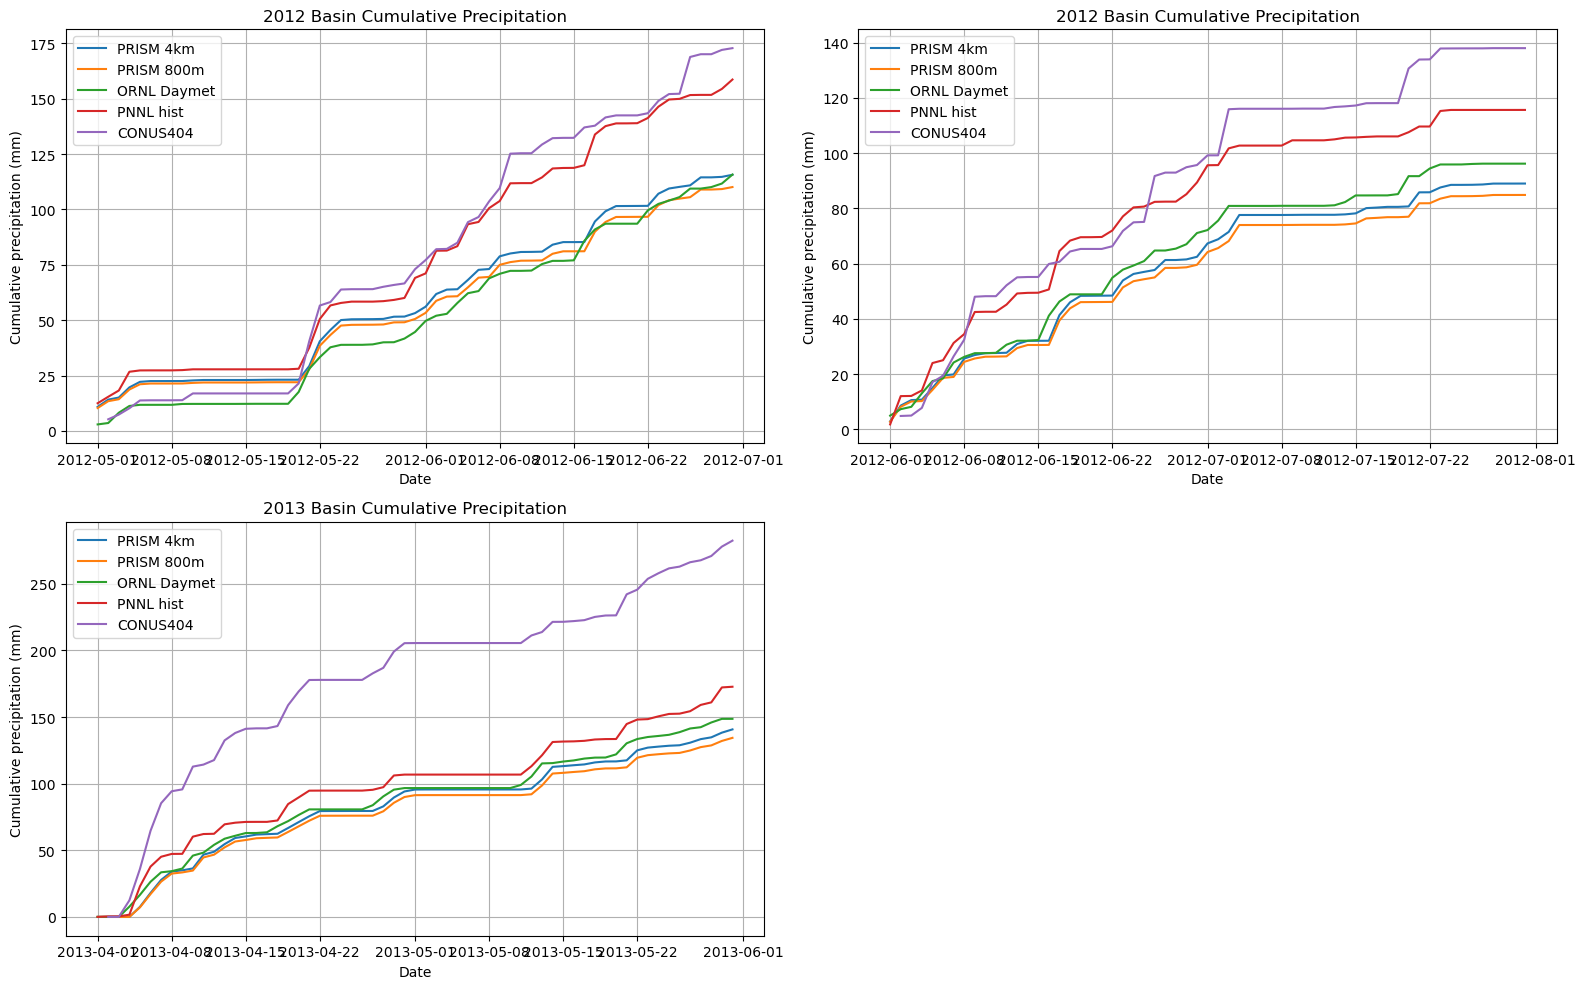


Saved MAE CSV → /data0/balaji24/data/derived/event_mae_vs_prism4km_mm_per_day.csv
    event_year       start         end  reference      dataset  \
0         2012  2012-05-01  2012-06-30  PRISM 4km     CONUS404   
1         2012  2012-06-01  2012-07-31  PRISM 4km     CONUS404   
2         2012  2012-05-01  2012-06-30  PRISM 4km  ORNL Daymet   
3         2012  2012-06-01  2012-07-31  PRISM 4km  ORNL Daymet   
4         2012  2012-05-01  2012-06-30  PRISM 4km    PNNL hist   
5         2012  2012-06-01  2012-07-31  PRISM 4km    PNNL hist   
6         2012  2012-05-01  2012-06-30  PRISM 4km   PRISM 800m   
7         2012  2012-06-01  2012-07-31  PRISM 4km   PRISM 800m   
8         2013  2013-04-01  2013-05-31  PRISM 4km     CONUS404   
9         2013  2013-04-01  2013-05-31  PRISM 4km  ORNL Daymet   
10        2013  2013-04-01  2013-05-31  PRISM 4km    PNNL hist   
11        2013  2013-04-01  2013-05-31  PRISM 4km   PRISM 800m   

    mae_mm_per_day  n_days  
0         2.033739      60  


In [ ]:
# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison + VERIFICATION + MAE vs PRISM 4km
# PRISM (local zarr), ORNL Daymet (local zarr),
# UCLA WRF outputs (local zarr; your ucla_wrf_outputs naming),
# PNNL hist WRF (local netcdf; dims time,x,y; geo from SERDP6km),
# CONUS404 (external OSN), SNOTEL (external)
#
# Outputs: one subplot per event window, cumulative precip (mm)
# Prints: variable units + key diagnostics (accum handling)
# Adds: verification prints for daily series + mass-balance checks
# Adds: MAE(mm/day) vs PRISM 4km per event and saves CSV
#
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import requests

# for seasonal-style CONUS mask creation
import shapely

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_PRISM_DIR  = BASE / "prism_nc"
P_ORNL_DIR   = BASE / "ornl_nc"

# UCLA outputs
P_UCLA_DIR   = BASE / "ucla_wrf_outputs"

P_PNNL_DIR   = BASE / "PNNL" / "historical"
P_PNNL_GEO   = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"
BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
MAE_CSV = OUT / "event_mae_vs_prism4km_mm_per_day.csv"

# External
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

SNOTEL_STATIONS_GEOJSON = (
    "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
)

# ----------------------------
# EVENTS 
# ----------------------------
events = [
    {"event_year": 2012, "start": "2012-05-01", "end": "2012-06-30"},
    {"event_year": 2012, "start": "2012-06-01", "end": "2012-07-31"},
    {"event_year": 2013, "start": "2013-04-01", "end": "2013-05-31"},
]

# ----------------------------
# HELPERS
# ----------------------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    return gdf.geometry.union_all()

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    """Sum to daily totals (safe for both hourly and daily)."""
    if "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_increment(acc_like_1d):
    """
    Reset-safe increments for an accumulated series (1D time):
      inc[t] = diff if diff>=0 else current_value (reset)
    Output aligns to time[1:].
    """
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    """
    Convert accumulated precip (mm) -> increments (mm/step) -> daily totals (mm/day).
    acc_like_1d MUST be 1D (time).
    """
    bm = acc_like_1d
    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = float((d < 0).mean())
    mean_raw = float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean())
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)
    daily = ensure_daily_sum(inc)
    return daily

# ----------------------------
# VERIFICATION
# ----------------------------
def debug_daily(label, daily_da):
    """Print distribution stats for a DAILY (mm/day) 1D time series."""
    if daily_da is None or "time" not in daily_da.dims or daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (empty)")
        return
    daily_da = daily_da.dropna("time")
    if daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (all NaN)")
        return
    print(f"\n[{label}] DAILY CHECK")
    print("  min:", float(daily_da.min()))
    print("  max:", float(daily_da.max()))
    print("  mean:", float(daily_da.mean()))
    print("  sum:", float(daily_da.sum()))

def _median_dt_hours_from_da(da):
    if da is None or "time" not in da.dims:
        return None
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return None
    dt_hours = pd.Series(t).diff().dt.total_seconds().dropna().median() / 3600.0
    return float(dt_hours) if pd.notnull(dt_hours) else None

def verify_daily_and_cumsum(label, daily_da, cum_da=None, top_n=5):
    """
    Verifies:
      - dt sanity
      - daily stats
      - sum(daily) == last(cumsum) (if cum passed)
      - top-N daily increments (helps spot unit/var issues)
    """
    if daily_da is None or daily_da.size == 0:
        print(f"\n===== VERIFY: {label} =====")
        print("  (no data)")
        return

    daily_da = daily_da.dropna("time").sortby("time")
    print(f"\n===== VERIFY: {label} =====")
    dt_hours = _median_dt_hours_from_da(daily_da)
    if dt_hours is not None:
        print(f"  median dt (hours): {dt_hours:.2f}")

    debug_daily(label, daily_da)

    # mass balance with cumsum if provided
    if cum_da is not None and is_plottable_1d(cum_da):
        try:
            cum_last = float(cum_da.dropna("time").isel(time=-1))
            daily_sum = float(daily_da.sum())
            print("  CHECK: daily.sum vs cum[-1]:", daily_sum, cum_last, " | diff:", daily_sum - cum_last)
        except Exception as e:
            print("  CHECK: daily.sum vs cum[-1]: (failed)", repr(e))

    # top N days
    try:
        top = daily_da.sortby(daily_da, ascending=False).isel(time=slice(0, min(top_n, daily_da.size)))
        print(f"  TOP {min(top_n, daily_da.size)} daily values:")
        for tt, vv in zip(pd.to_datetime(top["time"].values), np.asarray(top.values)):
            print("   ", tt.date(), float(vv))
    except Exception as e:
        print("  TOP daily values: (failed)", repr(e))

# ----------------------------
# MASKS
# ----------------------------
def _infer_lonlat_vars(ds):
    lon_candidates = ["lon", "longitude", "XLONG", "XLONG_M", "LON", "xlong", "xlong_m"]
    lat_candidates = ["lat", "latitude",  "XLAT",  "XLAT_M",  "LAT", "xlat",  "xlat_m"]

    def _get(name):
        if name in ds.coords:
            return ds.coords[name]
        if name in ds.data_vars:
            return ds.data_vars[name]
        return None

    lon = None
    lat = None
    for n in lon_candidates:
        lon = _get(n)
        if lon is not None:
            break
    for n in lat_candidates:
        lat = _get(n)
        if lat is not None:
            break

    if lon is None or lat is None:
        return None, None

    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})
    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})

    return lon, lat

# ----------------------------
# PRISM (covers-window match)
# ----------------------------
import re
_PRISM_NAME_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_daily_(?P<tag>4km|800m)_PRISM_data\.zarr$"
)

def find_prism_zarr_covering(start, end, tag):
    start = pd.Timestamp(start)
    end   = pd.Timestamp(end)

    candidates = []
    for p in P_PRISM_DIR.glob(f"*_daily_{tag}_PRISM_data.zarr"):
        m = _PRISM_NAME_RE.search(p.name)
        if not m:
            continue
        f0 = pd.Timestamp(m.group("s"))
        f1 = pd.Timestamp(m.group("e"))
        if f0 <= start and f1 >= end:
            span_days = (f1 - f0).days
            candidates.append((span_days, f0, p))

    if not candidates:
        return None

    candidates.sort(key=lambda t: (t[0], -t[1].value))
    return candidates[0][2]

def load_prism_daily(start, end, tag, do_verify=True):
    """Return DAILY basin-mean (mm/day), not cumulative."""
    z = find_prism_zarr_covering(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag} [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm_daily = daily.mean(dim=spatial, skipna=True)

    if do_verify:
        verify_daily_and_cumsum(f"PRISM {tag}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

def load_prism_cum(start, end, tag, do_verify=True):
    bm_daily = load_prism_daily(start, end, tag, do_verify=do_verify)
    if bm_daily is None:
        return None
    return bm_daily.cumsum("time")

# ----------------------------
# ORNL Daymet
# ----------------------------
def load_ornl_daily(year, start, end, do_verify=True):
    z = next(P_ORNL_DIR.glob(f"{year}_{year}_ref_*ORNL_data.zarr"), None)
    if z is None:
        print("  - ORNL Daymet: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["prcp"])
    if var is None:
        print("  - ORNL Daymet: (no prcp var)")
        ds.close()
        return None

    print_units(ds, var, f"ORNL Daymet [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm_daily = daily.mean(dim=spatial, skipna=True)

    if do_verify:
        verify_daily_and_cumsum("ORNL Daymet", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

def load_ornl_cum(year, start, end, do_verify=True):
    d = load_ornl_daily(year, start, end, do_verify=do_verify)
    return None if d is None else d.cumsum("time")

# ----------------------------
# UCLA WRF (event zarrs)
# ----------------------------
_UCLA_MASK = None
_UCLA_MASK_KEY = None

def _parse_ucla_event_zarr_name(p: Path):
    name = p.name
    if not name.endswith(".zarr"):
        return None, None, None
    parts = name.split("_")
    if len(parts) < 3:
        return None, None, None
    try:
        s0 = pd.to_datetime(parts[0])
        s1 = pd.to_datetime(parts[1])
    except Exception:
        return None, None, None
    scenario = "historical" if "historical" in name else ("ssp245" if "ssp245" in name else "unknown")
    return s0, s1, scenario

def find_ucla_zarr_event(start, end):
    if not P_UCLA_DIR.exists():
        return None

    s0 = pd.to_datetime(start)
    s1 = pd.to_datetime(end)

    exact = P_UCLA_DIR / f"{s0:%Y-%m-%d}_{s1:%Y-%m-%d}_wrf_cesm2_r11i1p1f1_historical_data.zarr"
    if exact.exists():
        return exact

    exact_ssp = P_UCLA_DIR / f"{s0:%Y-%m-%d}_{s1:%Y-%m-%d}_wrf_cesm2_r11i1p1f1_ssp245_data.zarr"
    if exact_ssp.exists():
        return exact_ssp

    candidates = sorted(P_UCLA_DIR.glob(f"{s0:%Y-%m-%d}_*_wrf_cesm2_r11i1p1f1_*_data.zarr"))
    if not candidates:
        candidates = sorted(P_UCLA_DIR.glob(f"{s0:%Y-%m-%d}_*_wrf_*_data.zarr"))

    best = None
    best_score = None
    for p in candidates:
        c0, c1, _scen = _parse_ucla_event_zarr_name(p)
        if c0 is None:
            continue
        if c0.normalize() != s0.normalize():
            continue
        score = abs((c1.normalize() - s1.normalize()).days)
        if best is None or score < best_score:
            best = p
            best_score = score

    if best is not None and best_score is not None and best_score <= 2:
        return best
    return None

def build_ucla_mask_for_da(da_precip, ds_ucla, geom):
    spatial = [d for d in da_precip.dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[UCLA] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = da_precip.sizes[d0], da_precip.sizes[d1]

    lon, lat = _infer_lonlat_vars(ds_ucla)
    if lon is None or lat is None:
        raise RuntimeError("[UCLA] Could not infer lon/lat arrays")

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)

    mask_np = np.asarray(mask_geo.data).astype(bool)

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[UCLA] Mask shape {mask_np.shape} does not match precip grid "
            f"({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_ucla_daily(start, end, geom, do_verify=True):
    global _UCLA_MASK, _UCLA_MASK_KEY

    z = find_ucla_zarr_event(start, end)
    if z is None:
        print("  - UCLA WRF: (not available)")
        return None

    ds = safe_open_zarr(z)

    var = pick_var(ds, ["PREC_ACC_NC", "RAINNC", "RAINC", "RAIN", "prcp", "precip", "precipitation", "ppt"])
    if var is None:
        print(f"  - UCLA WRF [{z.name}]: (no precip var found)")
        print(f"    data_vars (first 60): {list(ds.data_vars)[:60]}")
        ds.close()
        return None

    print_units(ds, var, f"UCLA WRF [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    spatial = [d for d in da.dims if d != "time"]

    key = (z.as_posix(), var, tuple(spatial), da.sizes[spatial[0]], da.sizes[spatial[1]])
    if (_UCLA_MASK is None) or (_UCLA_MASK_KEY != key):
        _UCLA_MASK = build_ucla_mask_for_da(da, ds, geom)
        _UCLA_MASK_KEY = key

    bm = da.where(_UCLA_MASK).mean(dim=spatial, skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = (
        ("accum" in var.lower()) or ("accumul" in desc) or
        (var.upper() in ("RAINNC", "RAINC", "RAIN", "PREC_ACC_NC"))
    )
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label="UCLA WRF accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    bm_daily = bm_daily.sortby("time")

    if do_verify:
        verify_daily_and_cumsum("UCLA WRF", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

def load_ucla_cum(start, end, geom, do_verify=True):
    d = load_ucla_daily(start, end, geom, do_verify=do_verify)
    return None if d is None else d.cumsum("time")

# ----------------------------
# PNNL hist (year file)
# ----------------------------
_PNNL_MASK_XY = None
_PNNL_MASK_KEY = None

def build_pnnl_mask_for_ds(ds_prec, geom):
    spatial = [d for d in ds_prec["PREC_ACC_NC"].dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = ds_prec.sizes[d0], ds_prec.sizes[d1]

    geo = xr.open_dataset(P_PNNL_GEO)

    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat = geo[lat_name]
    lon = geo[lon_name]

    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)

    mask_np = np.asarray(mask_geo.data).astype(bool)
    geo.close()

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[PNNL] Mask shape {mask_np.shape} does not match precip grid "
            f"({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_pnnl_daily(year, start, end, geom, do_verify=True):
    global _PNNL_MASK_XY, _PNNL_MASK_KEY

    f = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", "PNNL hist")

    spatial = [d for d in ds["PREC_ACC_NC"].dims if d != "time"]
    key = (tuple(spatial), ds.sizes[spatial[0]], ds.sizes[spatial[1]])
    if (_PNNL_MASK_XY is None) or (_PNNL_MASK_KEY != key):
        _PNNL_MASK_XY = build_pnnl_mask_for_ds(ds, geom)
        _PNNL_MASK_KEY = key

    da = ds["PREC_ACC_NC"].sel(time=slice(start, end)).sortby("time")
    bm_acc = da.where(_PNNL_MASK_XY).mean(dim=spatial, skipna=True)

    bm_daily = accumulated_to_daily_mm(bm_acc, label="PNNL hist")
    bm_daily = bm_daily.sortby("time")

    if do_verify:
        verify_daily_and_cumsum("PNNL hist", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

def load_pnnl_cum(year, start, end, geom, do_verify=True):
    d = load_pnnl_daily(year, start, end, geom, do_verify=do_verify)
    return None if d is None else d.cumsum("time")

# ----------------------------
# CONUS404 (external)
# ----------------------------
_conus_ds = None
_conus_mask = None  # cached xr.DataArray boolean mask on (y,x)

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus_daily(start, end, geom, do_verify=True):
    global _conus_mask

    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()

    var = pick_var(ds, [
        "prcp", "precip", "precipitation", "PREC", "PRECIP",
        "RAIN", "RAINNC", "RAINC",
        "PREC_ACC_NC"
    ])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    # NOTE: materializes full lon/lat in RAM once (cached)
    if _conus_mask is None:
        lon = ds["lon"]
        lat = ds["lat"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)  # (y,x) boolean numpy
        _conus_mask = xr.DataArray(mask_np, dims=("y", "x"))

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    bm = da.where(_conus_mask).mean(dim=("y", "x"), skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = ("accum" in var.lower()) or ("accumul" in desc) or (var.upper() in ("RAINNC", "RAINC", "PREC_ACC_NC"))
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label="CONUS404 accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    bm_daily = bm_daily.sortby("time")

    if do_verify:
        verify_daily_and_cumsum("CONUS404", bm_daily, bm_daily.cumsum("time"))

    return bm_daily

def load_conus_cum(start, end, geom, do_verify=True):
    d = load_conus_daily(start, end, geom, do_verify=do_verify)
    return None if d is None else d.cumsum("time")

# ----------------------------
# SNOTEL (external)
# ----------------------------
def load_snotel_daily(start, end, geom, do_verify=True):
    stations = gpd.read_file(SNOTEL_STATIONS_GEOJSON).to_crs("EPSG:4326")
    basin = gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")
    sel = gpd.sjoin(stations, basin, predicate="intersects", how="inner")

    if sel.empty:
        print("  - SNOTEL: no stations in basin")
        return None

    if "code" not in sel.columns:
        print("  - SNOTEL: expected 'code' column not found")
        print("    Available columns:", list(sel.columns))
        return None

    triplets = sorted(set(sel["code"].dropna().astype(str).tolist()))
    if not triplets:
        print("  - SNOTEL: no valid station triplets")
        return None

    url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data/getDaily"
    params = {
        "stationTriplets": ",".join(triplets),
        "elements": "PRCPSA",
        "beginDate": start,
        "endDate": end,
        "format": "json",
    }

    try:
        rr = requests.get(url, params=params, timeout=120)
        if rr.status_code != 200:
            print("  - SNOTEL: AWDB request failed")
            print("    status:", rr.status_code)
            print("    url:", rr.url)
            return None
        js = rr.json()
    except Exception as e:
        print("  - SNOTEL: AWDB request error:", repr(e))
        return None

    data = {}
    for st in js:
        trip = st.get("stationTriplet")
        vals = st.get("values", [])
        if not trip or not vals:
            continue
        s = {pd.to_datetime(v["date"]): (np.nan if v["value"] is None else float(v["value"])) for v in vals}
        data[trip] = pd.Series(s)

    if not data:
        print("  - SNOTEL: AWDB returned no data")
        return None

    df_in = pd.DataFrame(data).sort_index()
    print(f"  - SNOTEL: var='PRCPSA', units='inches → mm', stations={df_in.shape[1]}")

    df_mm = df_in * 25.4
    daily_mean = df_mm.mean(axis=1, skipna=True).loc[pd.to_datetime(start):pd.to_datetime(end)].asfreq("D")

    bm_daily = xr.DataArray(
        daily_mean.values,
        coords={"time": daily_mean.index},
        dims=("time",),
        name="SNOTEL",
    ).sortby("time")

    if do_verify:
        verify_daily_and_cumsum("SNOTEL", bm_daily, bm_daily.cumsum("time"))

    return bm_daily

def load_snotel_cum(start, end, geom, do_verify=True):
    d = load_snotel_daily(start, end, geom, do_verify=do_verify)
    return None if d is None else d.cumsum("time")

# ----------------------------
# MAE util
# ----------------------------
def mae_vs_reference_mm_per_day(ref_daily, other_daily):
    """
    Compute MAE on overlapping days between two DAILY (time) series.
    Returns (mae, n_days) or (np.nan, 0).
    """
    if ref_daily is None or other_daily is None:
        return np.nan, 0

    # ensure 1D
    if ("time" not in ref_daily.dims) or ("time" not in other_daily.dims):
        return np.nan, 0

    a = ref_daily.dropna("time").sortby("time")
    b = other_daily.dropna("time").sortby("time")

    # align on intersection of timestamps
    a2, b2 = xr.align(a, b, join="inner")
    if a2.size == 0 or b2.size == 0:
        return np.nan, 0

    diff = np.abs(a2 - b2)
    mae = float(diff.mean().values)
    n = int(diff.sizes.get("time", diff.size))
    return mae, n

# ----------------------------
# MAIN
# ----------------------------
def main():
    geom = load_basin_geom()

    n = len(events)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axs = np.array(axs).reshape(-1)

    mae_rows = []

    for i, ev in enumerate(events):
        yr = int(ev["event_year"])
        start = ev["start"]
        end = ev["end"]

        ax = axs[i]
        print(f"\n================ {yr} ({start} → {end}) ================")

        # Reference: PRISM 4km DAILY
        ref_daily = load_prism_daily(start, end, "4km", do_verify=True)

        # Build daily series for each dataset (so MAE is consistent mm/day)
        daily_series = [
            ("PRISM 4km",   ref_daily),
            ("PRISM 800m",  load_prism_daily(start, end, "800m", do_verify=True)),
            ("ORNL Daymet", load_ornl_daily(yr, start, end, do_verify=True)),
            ("UCLA WRF",    load_ucla_daily(start, end, geom, do_verify=True)),
            ("PNNL hist",   load_pnnl_daily(yr, start, end, geom, do_verify=True)),
            ("CONUS404",    load_conus_daily(start, end, geom, do_verify=True)),
            ("SNOTEL",      load_snotel_daily(start, end, geom, do_verify=True)),
        ]

        # Plot cumulative (for visual)
        plotted_any = False
        for label, dly in daily_series:
            if is_plottable_1d(dly):
                cum = dly.cumsum("time")
                ax.plot(pd.to_datetime(cum["time"].values), cum.values, label=label)
                plotted_any = True

        ax.set_title(f"{yr} Basin Cumulative Precipitation")
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative precipitation (mm)")
        ax.grid(True)
        if plotted_any:
            ax.legend()

        # MAE vs PRISM 4km (skip PRISM 4km itself)
        for label, dly in daily_series:
            if label == "PRISM 4km":
                continue
            mae, n_days = mae_vs_reference_mm_per_day(ref_daily, dly)
            if n_days > 0 and np.isfinite(mae):
                mae_rows.append({
                    "event_year": yr,
                    "start": start,
                    "end": end,
                    "reference": "PRISM 4km",
                    "dataset": label,
                    "mae_mm_per_day": mae,
                    "n_days": n_days,
                })

    for j in range(len(events), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

    # Save + print MAE table
    mae_df = pd.DataFrame(mae_rows).sort_values(["event_year", "dataset"]).reset_index(drop=True)
    mae_df.to_csv(MAE_CSV, index=False)
    print("\nSaved MAE CSV →", MAE_CSV)
    print(mae_df)

if __name__ == "__main__":
    main()



================ 2003 (2003-10-14 → 2003-10-19) ================
  - PRISM 4km [2003-10-14_2003-10-19_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km =====
  median dt (hours): 24.00

[PRISM 4km] DAILY CHECK
  min: 0.4079138934612274
  max: 43.33290100097656
  mean: 13.577052116394043
  sum: 81.46231079101562
  CHECK: daily.sum vs cum[-1]: 81.46231079101562 81.46231079101562  | diff: 0.0
  TOP 5 daily values:
    2003-10-17 43.33290100097656
    2003-10-16 17.792457580566406
    2003-10-18 13.21712875366211
    2003-10-19 4.594697952270508
    2003-10-15 2.117213010787964
  - PRISM 800m [2003-10-14_2003-10-19_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 800m =====
  median dt (hours): 24.00

[PRISM 800m] DAILY CHECK
  min: 0.3752521574497223
  max: 41.39179992675781
  mean: 12.969444274902344
  sum: 77.81666564941406
  CHECK: daily.sum vs cum[-1]: 77.81666564941406 77.81666564941406  | diff: 0.0
  TOP 5 daily values:


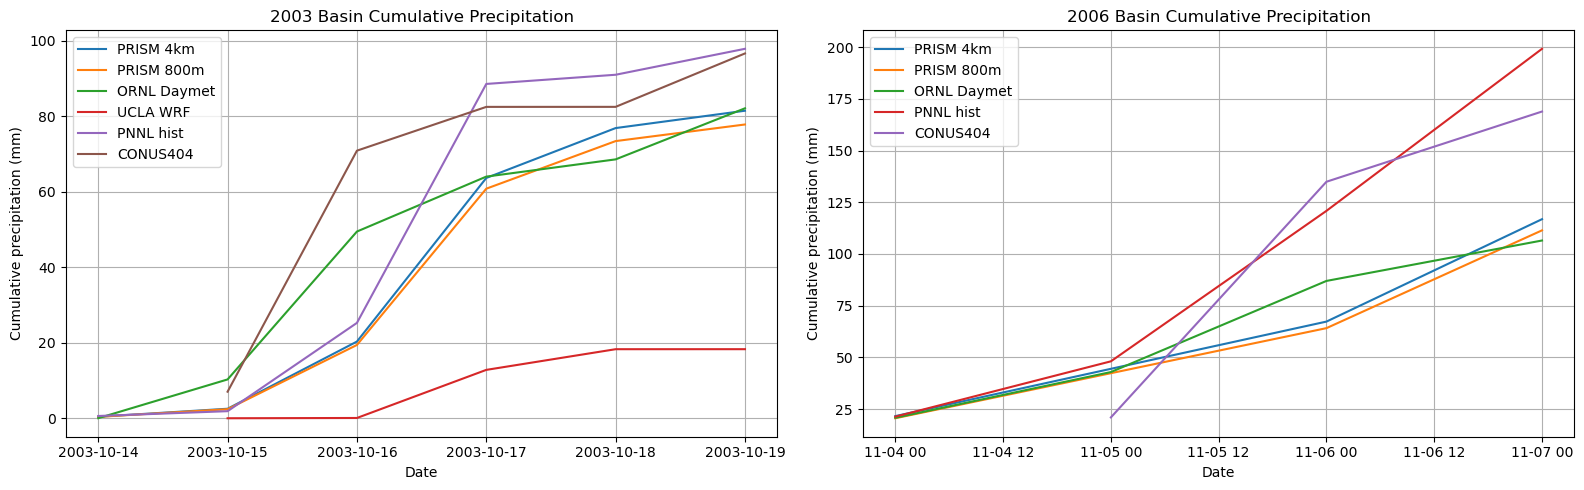


Saved MAE CSV → /data0/balaji24/data/derived/event_mae_vs_prism4km_mm_per_day.csv
   event_year       start         end  reference      dataset  mae_mm_per_day  \
0        2003  2003-10-14  2003-10-19  PRISM 4km     CONUS404       21.093761   
1        2003  2003-10-14  2003-10-19  PRISM 4km  ORNL Daymet       12.712756   
2        2003  2003-10-14  2003-10-19  PRISM 4km    PNNL hist        6.608201   
3        2003  2003-10-14  2003-10-19  PRISM 4km   PRISM 800m        0.607607   
4        2003  2003-10-14  2003-10-19  PRISM 4km     UCLA WRF       12.550916   
5        2006  2006-11-04  2006-11-07  PRISM 4km     CONUS404       36.229973   
6        2006  2006-11-04  2006-11-07  PRISM 4km  ORNL Daymet       13.197227   
7        2006  2006-11-04  2006-11-07  PRISM 4km    PNNL hist       20.735418   
8        2006  2006-11-04  2006-11-07  PRISM 4km   PRISM 800m        1.352044   

   n_days  
0       5  
1       6  
2       6  
3       6  
4       5  
5       3  
6       4  
7       4 

In [ ]:
# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison + VERIFICATION + MAE vs PRISM 4km
# PRISM (local zarr), ORNL Daymet (local zarr),
# UCLA WRF (event zarr OR auxhist hourly NetCDF), PNNL hist WRF (local netcdf),
# CONUS404 (external OSN), SNOTEL (external)
#
# Outputs: one subplot per event window, cumulative precip (mm)
# Prints: variable units + key diagnostics (accum handling)
# Adds: verification prints for daily series + mass-balance checks
# Adds: MAE(mm/day) vs PRISM 4km per event and saves CSV
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import requests
import shapely

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_PRISM_DIR  = BASE / "prism_nc"
P_ORNL_DIR   = BASE / "ornl_nc"
P_UCLA_DIR   = BASE / "ucla_wrf_outputs"

P_PNNL_DIR   = BASE / "PNNL" / "historical"
P_PNNL_GEO   = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"
BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
MAE_CSV = OUT / "event_mae_vs_prism4km_mm_per_day.csv"

CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

SNOTEL_STATIONS_GEOJSON = (
    "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
)

# ----------------------------
# EVENTS
# ----------------------------
events = [
    {"event_year": 2003, "start": "2003-10-14", "end": "2003-10-19"},
    {"event_year": 2006, "start": "2006-11-04", "end": "2006-11-07"},
]

# ----------------------------
# HELPERS
# ----------------------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    return gdf.geometry.union_all()

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    """Sum to daily totals (safe for both hourly and daily)."""
    if "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_increment(acc_like_1d):
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    """
    Convert accumulated precip (mm) -> increments (mm/step) -> daily totals (mm/day).
    If series is all-NaN, return None (DO NOT turn into zeros).
    """
    bm = acc_like_1d
    if bm is None or bm.size == 0:
        return None

    bm = bm.dropna("time")
    if bm.size == 0:
        print(f"    [{label}] basin-mean is all NaN (returning None)")
        return None

    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = float((d < 0).mean())
    mean_raw = float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean())
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)
    daily = ensure_daily_sum(inc)
    return daily

# ----------------------------
# VERIFICATION
# ----------------------------
def debug_daily(label, daily_da):
    if daily_da is None or "time" not in daily_da.dims or daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (empty)")
        return
    daily_da = daily_da.dropna("time")
    if daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (all NaN)")
        return
    print(f"\n[{label}] DAILY CHECK")
    print("  min:", float(daily_da.min()))
    print("  max:", float(daily_da.max()))
    print("  mean:", float(daily_da.mean()))
    print("  sum:", float(daily_da.sum()))

def _median_dt_hours_from_da(da):
    if da is None or "time" not in da.dims:
        return None
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return None
    dt_hours = pd.Series(t).diff().dt.total_seconds().dropna().median() / 3600.0
    return float(dt_hours) if pd.notnull(dt_hours) else None

def verify_daily_and_cumsum(label, daily_da, cum_da=None, top_n=5):
    if daily_da is None or daily_da.size == 0:
        print(f"\n===== VERIFY: {label} =====")
        print("  (no data)")
        return

    daily_da = daily_da.dropna("time").sortby("time")
    print(f"\n===== VERIFY: {label} =====")
    dt_hours = _median_dt_hours_from_da(daily_da)
    if dt_hours is not None:
        print(f"  median dt (hours): {dt_hours:.2f}")

    debug_daily(label, daily_da)

    if cum_da is not None and is_plottable_1d(cum_da):
        try:
            cum_last = float(cum_da.dropna("time").isel(time=-1))
            daily_sum = float(daily_da.sum())
            print("  CHECK: daily.sum vs cum[-1]:", daily_sum, cum_last, " | diff:", daily_sum - cum_last)
        except Exception as e:
            print("  CHECK: daily.sum vs cum[-1]: (failed)", repr(e))

    try:
        top = daily_da.sortby(daily_da, ascending=False).isel(time=slice(0, min(top_n, daily_da.size)))
        print(f"  TOP {min(top_n, daily_da.size)} daily values:")
        for tt, vv in zip(pd.to_datetime(top["time"].values), np.asarray(top.values)):
            print("   ", tt.date(), float(vv))
    except Exception as e:
        print("  TOP daily values: (failed)", repr(e))

# ----------------------------
# PRISM
# ----------------------------
_PRISM_NAME_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_daily_(?P<tag>4km|800m)_PRISM_data\.zarr$"
)

def find_prism_zarr_covering(start, end, tag):
    start = pd.Timestamp(start)
    end   = pd.Timestamp(end)
    candidates = []
    for p in P_PRISM_DIR.glob(f"*_daily_{tag}_PRISM_data.zarr"):
        m = _PRISM_NAME_RE.search(p.name)
        if not m:
            continue
        f0 = pd.Timestamp(m.group("s"))
        f1 = pd.Timestamp(m.group("e"))
        if f0 <= start and f1 >= end:
            span_days = (f1 - f0).days
            candidates.append((span_days, f0, p))
    if not candidates:
        return None
    candidates.sort(key=lambda t: (t[0], -t[1].value))
    return candidates[0][2]

def load_prism_daily(start, end, tag, do_verify=True):
    z = find_prism_zarr_covering(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag} [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")
    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm_daily = daily.mean(dim=spatial, skipna=True)

    if do_verify:
        verify_daily_and_cumsum(f"PRISM {tag}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ----------------------------
# ORNL
# ----------------------------
def load_ornl_daily(year, start, end, do_verify=True):
    z = next(P_ORNL_DIR.glob(f"{year}_{year}_ref_*ORNL_data.zarr"), None)
    if z is None:
        print("  - ORNL Daymet: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["prcp"])
    if var is None:
        print("  - ORNL Daymet: (no prcp var)")
        ds.close()
        return None

    print_units(ds, var, f"ORNL Daymet [{z.name}]")
    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm_daily = daily.mean(dim=spatial, skipna=True)

    if do_verify:
        verify_daily_and_cumsum("ORNL Daymet", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ----------------------------
# UCLA WRF 
# ----------------------------
_ZARR_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_wrf_.*_(?P<scen>historical|ssp245)_data\.zarr$"
)
_UCLA_NC_RE = re.compile(
    r"cesm2_r11i1p1f1_(?P<scen>historical|ssp245)_auxhist_d01_(?P<dt>\d{4}-\d{2}-\d{2})_(?P<hh>\d{2})-(?P<mm>\d{2})-(?P<ss>\d{2})\.nc$"
)

def find_ucla_zarr_overlapping(start, end, scenario="historical"):
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    best = None
    best_overlap_days = -1
    for p in P_UCLA_DIR.glob(f"*_wrf_*_{scenario}_data.zarr"):
        m = _ZARR_RE.match(p.name)
        if not m:
            continue
        z0 = pd.Timestamp(m.group("s"))
        z1 = pd.Timestamp(m.group("e"))
        overlap_start = max(start, z0)
        overlap_end = min(end, z1)
        if overlap_end < overlap_start:
            continue
        overlap_days = (overlap_end.normalize() - overlap_start.normalize()).days + 1
        if overlap_days > best_overlap_days:
            best_overlap_days = overlap_days
            best = p
    return best

def _list_ucla_nc_files(start, end, scenario="historical"):
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    files = []
    for p in P_UCLA_DIR.glob(f"cesm2_r11i1p1f1_{scenario}_auxhist_d01_*.nc"):
        m = _UCLA_NC_RE.match(p.name)
        if not m:
            continue
        dt = pd.Timestamp(f"{m.group('dt')} {m.group('hh')}:{m.group('mm')}:{m.group('ss')}")
        if (dt >= start) and (dt <= end + pd.Timedelta(days=1)):
            files.append((dt, p))
    files.sort(key=lambda t: t[0])
    return [p for _, p in files]

def _infer_lonlat_vars_ucla(ds, spatial_dims):
    sd0, sd1 = spatial_dims
    pairs = [
        ("XLONG_M", "XLAT_M"),
        ("XLONG",   "XLAT"),
        ("xlong_m", "xlat_m"),
        ("xlong",   "xlat"),
        ("lon",     "lat"),
        ("longitude","latitude"),
    ]

    def get_var(name):
        if name in ds.coords:
            return ds.coords[name]
        if name in ds.variables:
            return ds[name]
        return None

    for lon_name, lat_name in pairs:
        lon = get_var(lon_name)
        lat = get_var(lat_name)
        if lon is None or lat is None:
            continue

        for d in list(lon.dims):
            if d.lower() in ("time", "times") or d == "Time":
                lon = lon.isel({d: 0})
        for d in list(lat.dims):
            if d.lower() in ("time", "times") or d == "Time":
                lat = lat.isel({d: 0})

        if lon.dims == (sd0, sd1) and lat.dims == (sd0, sd1):
            try:
                lon_max = float(lon.max())
                lon_min = float(lon.min())
                if lon_max > 180.0 and lon_min >= 0.0:
                    lon = ((lon + 180.0) % 360.0) - 180.0
            except Exception:
                pass
            return lon, lat

    return None, None

def _ucla_basinmean_daily_from_ds(ds, start, end, geom, label_for_print):
    if "Time" in ds.dims and "time" not in ds.dims:
        ds = ds.rename({"Time": "time"})

    if "time" not in ds.dims:
        print(f"  - {label_for_print}: (no 'time' dim)")
        return None

    has_rainnc = "RAINNC" in ds
    has_rainc  = "RAINC"  in ds
    if has_rainnc and has_rainc:
        da = (ds["RAINNC"] + ds["RAINC"]).rename("RAINNC_PLUS_RAINC")
        print(f"  - {label_for_print}: using 'RAINNC+RAINC', units='{da.attrs.get('units','(missing)')}'")
    else:
        var = pick_var(ds, ["PREC_ACC_NC", "RAINNC", "RAINC", "RAIN", "prcp", "precip", "precipitation", "ppt"])
        if var is None:
            print(f"  - {label_for_print}: (no precip var found)")
            print(f"    data_vars (first 80): {list(ds.data_vars)[:80]}")
            return None
        print_units(ds, var, label_for_print)
        da = ds[var]

    da = da.sel(time=slice(start, end)).sortby("time")
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) != 2:
        print(f"  - {label_for_print}: unexpected spatial dims={spatial}")
        return None

    lon, lat = _infer_lonlat_vars_ucla(ds, tuple(spatial))
    if lon is None or lat is None:
        print(f"  - {label_for_print}: could not infer lon/lat matching precip dims {tuple(spatial)}")
        return None

    # Always print lon/lat range + mask fraction (no caching)
    try:
        print(f"    [{label_for_print}] lon range: {float(lon.min()):.3f} .. {float(lon.max()):.3f}")
        print(f"    [{label_for_print}] lat range: {float(lat.min()):.3f} .. {float(lat.max()):.3f}")
    except Exception:
        pass

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)
    mask_np = np.asarray(mask_geo.data).astype(bool)

    s0, s1 = da.sizes[spatial[0]], da.sizes[spatial[1]]
    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(f"[UCLA] Mask shape {mask_np.shape} != grid {(s0, s1)}")

    frac_true = float(mask_np.mean())
    print(f"    [{label_for_print}] mask fraction true: {frac_true:.6f} (if ~0, lon/lat mismatch)")

    mask = xr.DataArray(mask_np, dims=(spatial[0], spatial[1]))
    bm = da.where(mask).mean(dim=spatial, skipna=True)

    # If basin mean is all NaN, return None (do NOT become zeros)
    if bm.dropna("time").size == 0:
        print(f"  - {label_for_print}: basin-mean is all NaN (mask/time mismatch)")
        return None

    bm_daily = accumulated_to_daily_mm(bm, label=f"{label_for_print} accum")
    if bm_daily is None:
        return None
    return bm_daily.sortby("time")

def load_ucla_daily(start, end, geom, do_verify=True, scenario="historical"):
    z = find_ucla_zarr_overlapping(start, end, scenario=scenario)
    if z is not None:
        ds = safe_open_zarr(z)
        bm_daily = _ucla_basinmean_daily_from_ds(ds, start, end, geom, f"UCLA WRF ({scenario} zarr) [{z.name}]")
        if bm_daily is not None and do_verify:
            verify_daily_and_cumsum(f"UCLA WRF ({scenario})", bm_daily, bm_daily.cumsum("time"))
        ds.close()
        return bm_daily

    files = _list_ucla_nc_files(start, end, scenario=scenario)
    if not files:
        print(f"  - UCLA WRF ({scenario}): (no zarr overlap + no auxhist files in window)")
        return None

    ds = xr.open_mfdataset(
        files,
        combine="nested",
        concat_dim="time",
        parallel=True,
        chunks={"time": 24},
        engine="netcdf4",
        coords="minimal",
        data_vars="minimal",
        compat="override",
    )
    if "Time" in ds.dims and "time" not in ds.dims:
        ds = ds.rename({"Time": "time"})

    bm_daily = _ucla_basinmean_daily_from_ds(ds, start, end, geom, f"UCLA WRF ({scenario} auxhist)")
    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum(f"UCLA WRF ({scenario})", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ----------------------------
# PNNL hist
# ----------------------------
_PNNL_MASK_XY = None
_PNNL_MASK_KEY = None

def build_pnnl_mask_for_ds(ds_prec, geom):
    spatial = [d for d in ds_prec["PREC_ACC_NC"].dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = ds_prec.sizes[d0], ds_prec.sizes[d1]

    geo = xr.open_dataset(P_PNNL_GEO)
    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat = geo[lat_name]
    lon = geo[lon_name]
    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)
    mask_np = np.asarray(mask_geo.data).astype(bool)
    geo.close()

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[PNNL] Mask shape {mask_np.shape} does not match precip grid "
            f"({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_pnnl_daily(year, start, end, geom, do_verify=True):
    global _PNNL_MASK_XY, _PNNL_MASK_KEY

    f = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", "PNNL hist")
    spatial = [d for d in ds["PREC_ACC_NC"].dims if d != "time"]
    key = (tuple(spatial), ds.sizes[spatial[0]], ds.sizes[spatial[1]])
    if (_PNNL_MASK_XY is None) or (_PNNL_MASK_KEY != key):
        _PNNL_MASK_XY = build_pnnl_mask_for_ds(ds, geom)
        _PNNL_MASK_KEY = key

    da = ds["PREC_ACC_NC"].sel(time=slice(start, end)).sortby("time")
    bm_acc = da.where(_PNNL_MASK_XY).mean(dim=spatial, skipna=True)

    bm_daily = accumulated_to_daily_mm(bm_acc, label="PNNL hist")
    if bm_daily is None:
        ds.close()
        return None
    bm_daily = bm_daily.sortby("time")

    if do_verify:
        verify_daily_and_cumsum("PNNL hist", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ----------------------------
# CONUS404
# ----------------------------
_conus_ds = None
_conus_mask = None

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus_daily(start, end, geom, do_verify=True):
    global _conus_mask
    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()
    var = pick_var(ds, ["PREC_ACC_NC", "prcp", "precip", "precipitation"])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    if _conus_mask is None:
        lon = ds["lon"]
        lat = ds["lat"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)
        _conus_mask = xr.DataArray(mask_np, dims=("y", "x"))

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    bm = da.where(_conus_mask).mean(dim=("y", "x"), skipna=True)

    bm_daily = accumulated_to_daily_mm(bm, label="CONUS404 accum")
    if bm_daily is None:
        return None
    bm_daily = bm_daily.sortby("time")

    if do_verify:
        verify_daily_and_cumsum("CONUS404", bm_daily, bm_daily.cumsum("time"))

    return bm_daily

# ----------------------------
# SNOTEL 
# ----------------------------
def load_snotel_daily(start, end, geom, do_verify=True):
    stations = gpd.read_file(SNOTEL_STATIONS_GEOJSON).to_crs("EPSG:4326")
    basin = gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")
    sel = gpd.sjoin(stations, basin, predicate="intersects", how="inner")
    if sel.empty:
        print("  - SNOTEL: no stations in basin")
        return None
    if "code" not in sel.columns:
        print("  - SNOTEL: expected 'code' column not found")
        print("    Available columns:", list(sel.columns))
        return None

    triplets = sorted(set(sel["code"].dropna().astype(str).tolist()))
    if not triplets:
        print("  - SNOTEL: no valid station triplets")
        return None

    url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data/getDaily"
    params = {
        "stationTriplets": ",".join(triplets),
        "elements": "PRCPSA",
        "beginDate": start,
        "endDate": end,
        "format": "json",
    }

    try:
        rr = requests.get(url, params=params, timeout=120)
        if rr.status_code != 200:
            print("  - SNOTEL: AWDB request failed")
            print("    status:", rr.status_code)
            print("    url:", rr.url)
            return None
        js = rr.json()
    except Exception as e:
        print("  - SNOTEL: AWDB request error:", repr(e))
        return None

    data = {}
    for st in js:
        trip = st.get("stationTriplet")
        vals = st.get("values", [])
        if not trip or not vals:
            continue
        s = {pd.to_datetime(v["date"]): (np.nan if v["value"] is None else float(v["value"])) for v in vals}
        data[trip] = pd.Series(s)

    if not data:
        print("  - SNOTEL: AWDB returned no data")
        return None

    df_in = pd.DataFrame(data).sort_index()
    print(f"  - SNOTEL: var='PRCPSA', units='inches → mm', stations={df_in.shape[1]}")
    df_mm = df_in * 25.4
    daily_mean = df_mm.mean(axis=1, skipna=True).loc[pd.to_datetime(start):pd.to_datetime(end)].asfreq("D")
    bm_daily = xr.DataArray(daily_mean.values, coords={"time": daily_mean.index}, dims=("time",), name="SNOTEL").sortby("time")

    if do_verify:
        verify_daily_and_cumsum("SNOTEL", bm_daily, bm_daily.cumsum("time"))

    return bm_daily

# ----------------------------
# MAE util
# ----------------------------
def mae_vs_reference_mm_per_day(ref_daily, other_daily):
    if ref_daily is None or other_daily is None:
        return np.nan, 0
    a = ref_daily.dropna("time").sortby("time")
    b = other_daily.dropna("time").sortby("time")
    a2, b2 = xr.align(a, b, join="inner")
    if a2.size == 0:
        return np.nan, 0
    diff = np.abs(a2 - b2)
    return float(diff.mean().values), int(diff.sizes.get("time", diff.size))

# ----------------------------
# MAIN
# ----------------------------
def main():
    geom = load_basin_geom()

    n = len(events)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axs = np.array(axs).reshape(-1)

    mae_rows = []

    for i, ev in enumerate(events):
        yr = int(ev["event_year"])
        start = ev["start"]
        end = ev["end"]

        ax = axs[i]
        print(f"\n================ {yr} ({start} → {end}) ================")

        ref_daily = load_prism_daily(start, end, "4km", do_verify=True)

        daily_series = [
            ("PRISM 4km",   ref_daily),
            ("PRISM 800m",  load_prism_daily(start, end, "800m", do_verify=True)),
            ("ORNL Daymet", load_ornl_daily(yr, start, end, do_verify=True)),
            ("UCLA WRF",    load_ucla_daily(start, end, geom, do_verify=True, scenario="historical")),
            ("PNNL hist",   load_pnnl_daily(yr, start, end, geom, do_verify=True)),
            ("CONUS404",    load_conus_daily(start, end, geom, do_verify=True)),
            ("SNOTEL",      load_snotel_daily(start, end, geom, do_verify=True)),
        ]

        plotted_any = False
        for label, dly in daily_series:
            if is_plottable_1d(dly):
                cum = dly.cumsum("time")
                ax.plot(pd.to_datetime(cum["time"].values), cum.values, label=label)
                plotted_any = True

        ax.set_title(f"{yr} Basin Cumulative Precipitation")
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative precipitation (mm)")
        ax.grid(True)
        if plotted_any:
            ax.legend()

        for label, dly in daily_series:
            if label == "PRISM 4km":
                continue
            mae, n_days = mae_vs_reference_mm_per_day(ref_daily, dly)
            if n_days > 0 and np.isfinite(mae):
                mae_rows.append({
                    "event_year": yr,
                    "start": start,
                    "end": end,
                    "reference": "PRISM 4km",
                    "dataset": label,
                    "mae_mm_per_day": mae,
                    "n_days": n_days,
                })

    for j in range(len(events), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

    mae_df = pd.DataFrame(mae_rows).sort_values(["event_year", "dataset"]).reset_index(drop=True)
    mae_df.to_csv(MAE_CSV, index=False)
    print("\nSaved MAE CSV →", MAE_CSV)
    print(mae_df)

if __name__ == "__main__":
    main()



================ 2016 (2016-10-30 → 2016-11-05) ================
  - PRISM 4km [2016-01-01_2016-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km =====
  median dt (hours): 24.00

[PRISM 4km] DAILY CHECK
  min: 0.2900978922843933
  max: 11.447493553161621
  mean: 4.948406219482422
  sum: 34.63884353637695
  CHECK: daily.sum vs cum[-1]: 34.63884353637695 34.63884353637695  | diff: 0.0
  TOP 5 daily values:
    2016-11-03 11.447493553161621
    2016-11-02 9.193361282348633
    2016-11-01 8.141079902648926
    2016-10-30 2.5826666355133057
    2016-10-31 2.2681734561920166
  - ORNL [2016_2016_CNRM-ESM2-1_ssp245_DBCCA_ORNL_data.zarr]: var='prcp', units='mm/day'

===== VERIFY: ORNL =====
  median dt (hours): 24.00

[ORNL] DAILY CHECK
  min: 0.0
  max: 7.387190818786621
  mean: 3.1320343017578125
  sum: 21.924240112304688
  CHECK: daily.sum vs cum[-1]: 21.924240112304688 21.924240112304688  | diff: 0.0
  TOP 5 daily values:
    2016-11-05 7.387190818786

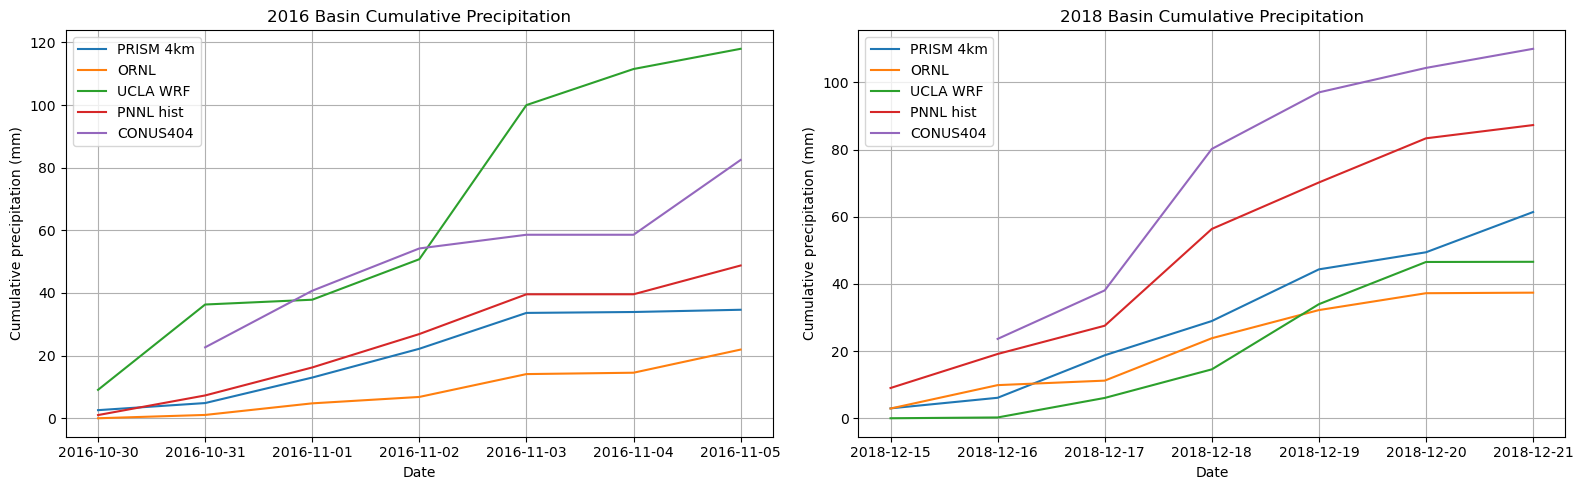


Saved MAE CSV → /data0/balaji24/data/derived/event_mae_vs_prism4km_mm_per_day.csv
   event_year       start         end  reference    dataset  mae_mm_per_day  \
0        2016  2016-10-30  2016-11-05  PRISM 4km   CONUS404       10.857438   
1        2016  2016-10-30  2016-11-05  PRISM 4km       ORNL        3.764479   
2        2016  2016-10-30  2016-11-05  PRISM 4km  PNNL hist        2.547879   
3        2016  2016-10-30  2016-11-05  PRISM 4km   UCLA WRF       13.790998   
4        2018  2018-12-15  2018-12-21  PRISM 4km   CONUS404       10.687327   
5        2018  2018-12-15  2018-12-21  PRISM 4km       ORNL        5.212632   
6        2018  2018-12-15  2018-12-21  PRISM 4km  PNNL hist        7.647211   
7        2018  2018-12-15  2018-12-21  PRISM 4km   UCLA WRF        5.402084   

   n_days  
0       6  
1       7  
2       7  
3       7  
4       6  
5       7  
6       7  
7       7  


In [ ]:
# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison + VERIFICATION + MAE vs PRISM 4km
# PRISM (local zarr), ORNL (ref Daymet OR modeled DBCCA/RegCM),
# UCLA WRF auxhist hourly NetCDF OR event zarr,
# PNNL hist WRF (local netcdf),
# CONUS404 (external OSN), SNOTEL (external)
#
# Outputs: one subplot per event window, cumulative precip (mm)
# Prints: variable units + key diagnostics (accum handling)
# Adds: verification prints for daily series + mass-balance checks
# Adds: MAE(mm/day) vs PRISM 4km per event and saves CSV
#
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import requests
import shapely

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_PRISM_DIR  = BASE / "prism_ppt"
P_ORNL_DIR   = BASE / "ornl_nc"
P_UCLA_DIR   = BASE / "ucla_wrf_outputs"

P_PNNL_DIR   = BASE / "PNNL" / "historical"
P_PNNL_GEO   = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"

BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
MAE_CSV = OUT / "event_mae_vs_prism4km_mm_per_day.csv"

# External
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

SNOTEL_STATIONS_GEOJSON = (
    "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
)

# ----------------------------
# EVENTS 
# ----------------------------
events = [
    {"event_year": 2016, "start": "2016-10-30", "end": "2016-11-05"},
    {"event_year": 2018, "start": "2018-12-15", "end": "2018-12-21"},
]

# ============================================================
# HELPERS
# ============================================================

def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    return gdf.geometry.union_all()

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    """Sum to daily totals (safe for both hourly and daily)."""
    if "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    # If it's already daily, resample sum is fine; if hourly, it aggregates.
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_increment(acc_like_1d):
    """
    Reset-safe increments for an accumulated series (1D time):
      inc[t] = diff if diff>=0 else current_value (reset)
    Output aligns to time[1:].
    """
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    """
    Convert accumulated precip (mm) -> increments (mm/step) -> daily totals (mm/day).
    acc_like_1d MUST be 1D (time).
    """
    bm = acc_like_1d
    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = float((d < 0).mean())
    mean_raw = float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean())
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)
    daily = ensure_daily_sum(inc)
    return daily

# ============================================================
# VERIFICATION PRINTS
# ============================================================

def debug_daily(label, daily_da):
    """Print distribution stats for a DAILY (mm/day) 1D time series."""
    if daily_da is None or "time" not in daily_da.dims or daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (empty)")
        return
    daily_da = daily_da.dropna("time")
    if daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (all NaN)")
        return
    print(f"\n[{label}] DAILY CHECK")
    print("  min:", float(daily_da.min()))
    print("  max:", float(daily_da.max()))
    print("  mean:", float(daily_da.mean()))
    print("  sum:", float(daily_da.sum()))

def _median_dt_hours_from_da(da):
    if da is None or "time" not in da.dims:
        return None
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return None
    dt_hours = pd.Series(t).diff().dt.total_seconds().dropna().median() / 3600.0
    return float(dt_hours) if pd.notnull(dt_hours) else None

def verify_daily_and_cumsum(label, daily_da, cum_da=None, top_n=5):
    """
    Verifies:
      - dt sanity
      - daily stats
      - sum(daily) == last(cumsum) (if cum passed)
      - top-N daily increments (helps spot unit/var issues)
    """
    if daily_da is None or daily_da.size == 0:
        print(f"\n===== VERIFY: {label} =====")
        print("  (no data)")
        return

    daily_da = daily_da.dropna("time").sortby("time")
    print(f"\n===== VERIFY: {label} =====")
    dt_hours = _median_dt_hours_from_da(daily_da)
    if dt_hours is not None:
        print(f"  median dt (hours): {dt_hours:.2f}")

    debug_daily(label, daily_da)

    if cum_da is not None and is_plottable_1d(cum_da):
        try:
            cum_last = float(cum_da.dropna("time").isel(time=-1))
            daily_sum = float(daily_da.sum())
            print("  CHECK: daily.sum vs cum[-1]:", daily_sum, cum_last, " | diff:", daily_sum - cum_last)
        except Exception as e:
            print("  CHECK: daily.sum vs cum[-1]: (failed)", repr(e))

    try:
        top = daily_da.sortby(daily_da, ascending=False).isel(time=slice(0, min(top_n, daily_da.size)))
        print(f"  TOP {min(top_n, daily_da.size)} daily values:")
        for tt, vv in zip(pd.to_datetime(top["time"].values), np.asarray(top.values)):
            print("   ", tt.date(), float(vv))
    except Exception as e:
        print("  TOP daily values: (failed)", repr(e))

# ============================================================
# PRISM (covers-window match)
# ============================================================

_PRISM_NAME_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_daily_(?P<tag>4km|800m)_PRISM_data\.zarr$"
)

def find_prism_zarr_covering(start, end, tag):
    start = pd.Timestamp(start)
    end   = pd.Timestamp(end)

    candidates = []
    for p in P_PRISM_DIR.glob(f"*_daily_{tag}_PRISM_data.zarr"):
        m = _PRISM_NAME_RE.search(p.name)
        if not m:
            continue
        f0 = pd.Timestamp(m.group("s"))
        f1 = pd.Timestamp(m.group("e"))
        if f0 <= start and f1 >= end:
            span_days = (f1 - f0).days
            candidates.append((span_days, f0, p))

    if not candidates:
        return None

    candidates.sort(key=lambda t: (t[0], -t[1].value))
    return candidates[0][2]

def load_prism_daily(start, end, tag, do_verify=True):
    """Return DAILY basin-mean (mm/day), not cumulative."""
    z = find_prism_zarr_covering(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag} [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm_daily = daily.mean(dim=spatial, skipna=True)

    if do_verify:
        verify_daily_and_cumsum(f"PRISM {tag}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ============================================================
# ORNL (FIXED): supports BOTH
#   - ref files: YYYY_YYYY_ref_*_ORNL_data.zarr
#   - modeled:   YYYY_YYYY_<GCM>_<sspXXX>_<DBCCA/RegCM>_ORNL_data.zarr
# ============================================================

def _pick_ornl_zarr(year, scenario=None, gcm=None, method=None):
    # 1) Try reference first
    z = next(P_ORNL_DIR.glob(f"{year}_{year}_ref_*ORNL_data.zarr"), None)
    if z is not None:
        return z

    # 2) Try modeled candidates
    candidates = sorted(P_ORNL_DIR.glob(f"{year}_{year}_*ORNL_data.zarr"))
    candidates = [p for p in candidates if "_ref_" not in p.name]

    if scenario:
        candidates = [p for p in candidates if f"_{scenario}_" in p.name]
    if gcm:
        candidates = [p for p in candidates if f"_{gcm}_" in p.name]
    if method:
        candidates = [p for p in candidates if f"_{method}_" in p.name]

    return candidates[0] if candidates else None

def load_ornl_daily(year, start, end, do_verify=True, scenario=None, gcm=None, method=None):
    z = _pick_ornl_zarr(year, scenario=scenario, gcm=gcm, method=method)
    if z is None:
        print("  - ORNL: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["prcp"])
    if var is None:
        print(f"  - ORNL [{z.name}]: (no prcp var)")
        ds.close()
        return None

    print_units(ds, var, f"ORNL [{z.name}]")

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    daily = ensure_daily_sum(da)

    spatial = [d for d in daily.dims if d != "time"]
    bm_daily = daily.mean(dim=spatial, skipna=True)

    if do_verify:
        verify_daily_and_cumsum("ORNL", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ============================================================
# UCLA WRF (supports BOTH formats):
#   1) event zarr:  YYYY-MM-DD_YYYY-MM-DD_wrf_*_(historical|ssp245)_data.zarr
#   2) hourly auxhist netcdf: cesm2_r11i1p1f1_(historical|ssp245)_auxhist_d01_YYYY-MM-DD_HH-MM-SS.nc
# ============================================================

_UCLA_MASK = None
_UCLA_MASK_KEY = None

def _infer_lonlat_vars(ds):
    candidates = list(ds.variables)

    lon_candidates = [
        "lon", "longitude", "xlon", "long", "lon_wrf", "xlong", "xlong_m",
        "XLONG", "XLONG_M", "LON", "LONGITUDE"
    ]
    lat_candidates = [
        "lat", "latitude", "xlat", "lati", "lat_wrf", "xlat", "xlat_m",
        "XLAT", "XLAT_M", "LAT", "LATITUDE"
    ]

    def _get(name):
        if name in ds.coords:
            return ds.coords[name]
        if name in ds.data_vars:
            return ds.data_vars[name]
        if name in ds.variables:
            return ds[name]
        return None

    lon = None
    lat = None

    for n in lon_candidates:
        lon = _get(n)
        if lon is not None:
            break
    for n in lat_candidates:
        lat = _get(n)
        if lat is not None:
            break

    if lon is None:
        for v in candidates:
            if "lon" in v.lower() and ds[v].ndim >= 2:
                lon = ds[v]
                break
    if lat is None:
        for v in candidates:
            if "lat" in v.lower() and ds[v].ndim >= 2:
                lat = ds[v]
                break

    if lon is None or lat is None:
        return None, None

    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})
    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})

    return lon, lat

_ZARR_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_wrf_.*_(?P<scen>historical|ssp245)_data\.zarr$"
)

def find_ucla_zarr_overlapping(start, end, scenario="historical"):
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)

    best = None
    best_overlap_days = -1

    for p in P_UCLA_DIR.glob(f"*_wrf_*_{scenario}_data.zarr"):
        m = _ZARR_RE.match(p.name)
        if not m:
            continue
        z0 = pd.Timestamp(m.group("s"))
        z1 = pd.Timestamp(m.group("e"))

        overlap_start = max(start, z0)
        overlap_end = min(end, z1)
        if overlap_end < overlap_start:
            continue

        overlap_days = (overlap_end.normalize() - overlap_start.normalize()).days + 1
        if overlap_days > best_overlap_days:
            best_overlap_days = overlap_days
            best = p

    return best

_UCLA_NC_RE = re.compile(
    r"cesm2_r11i1p1f1_(?P<scen>historical|ssp245)_auxhist_d01_(?P<dt>\d{4}-\d{2}-\d{2})_(?P<hh>\d{2})-(?P<mm>\d{2})-(?P<ss>\d{2})\.nc$"
)

def _list_ucla_nc_files(start, end, scenario="historical"):
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    files = []

    for p in P_UCLA_DIR.glob(f"cesm2_r11i1p1f1_{scenario}_auxhist_d01_*.nc"):
        m = _UCLA_NC_RE.match(p.name)
        if not m:
            continue
        dt = pd.Timestamp(f"{m.group('dt')} {m.group('hh')}:{m.group('mm')}:{m.group('ss')}")
        if (dt >= start) and (dt <= end + pd.Timedelta(days=1)):
            files.append((dt, p))

    files.sort(key=lambda t: t[0])
    return [p for _, p in files]

def _ucla_basinmean_daily_from_ds(ds, var, start, end, geom, label_for_print):
    global _UCLA_MASK, _UCLA_MASK_KEY

    if "Time" in ds.dims and "time" not in ds.dims:
        ds = ds.rename({"Time": "time"})

    if "time" not in ds.dims:
        print(f"  - {label_for_print}: (no 'time' dim)")
        return None

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) != 2:
        print(f"  - {label_for_print}: unexpected spatial dims={spatial}")
        return None

    key = (var, tuple(spatial), da.sizes[spatial[0]], da.sizes[spatial[1]])
    if (_UCLA_MASK is None) or (_UCLA_MASK_KEY != key):
        lon, lat = _infer_lonlat_vars(ds)
        if lon is None or lat is None:
            print(f"  - {label_for_print}: could not infer lon/lat")
            return None

        region = regionmask.Regions([geom])
        m = region.mask(lon, lat)
        mask_geo = ~xr.ufuncs.isnan(m)
        mask_np = np.asarray(mask_geo.data).astype(bool)

        s0, s1 = da.sizes[spatial[0]], da.sizes[spatial[1]]
        if mask_np.shape == (s0, s1):
            pass
        elif mask_np.shape == (s1, s0):
            mask_np = mask_np.T
        else:
            raise RuntimeError(f"[UCLA] Mask shape {mask_np.shape} != grid {(s0, s1)}")

        _UCLA_MASK = xr.DataArray(mask_np, dims=(spatial[0], spatial[1]))
        _UCLA_MASK_KEY = key

    bm = da.where(_UCLA_MASK).mean(dim=spatial, skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = (
        ("accum" in var.lower()) or ("accumul" in desc) or
        (var.upper() in ("RAINNC", "RAINC", "RAIN", "PREC_ACC_NC"))
    )
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label=f"{label_for_print} accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    return bm_daily.sortby("time")

def load_ucla_daily(start, end, geom, do_verify=True, scenario="historical"):
    # 1) event zarr overlap
    z = find_ucla_zarr_overlapping(start, end, scenario=scenario)
    if z is not None:
        ds = safe_open_zarr(z)
        var = pick_var(ds, ["PREC_ACC_NC", "RAINNC", "RAINC", "RAIN", "prcp", "precip", "precipitation", "ppt"])
        if var is None:
            print(f"  - UCLA WRF ({scenario} zarr) [{z.name}]: (no precip var)")
            ds.close()
            return None

        print_units(ds, var, f"UCLA WRF ({scenario} zarr) [{z.name}]")
        bm_daily = _ucla_basinmean_daily_from_ds(ds, var, start, end, geom, f"UCLA WRF ({scenario} zarr)")
        if bm_daily is not None and do_verify:
            verify_daily_and_cumsum(f"UCLA WRF ({scenario})", bm_daily, bm_daily.cumsum("time"))
        ds.close()
        return bm_daily

    # 2) auxhist hourly netcdf
    files = _list_ucla_nc_files(start, end, scenario=scenario)
    if not files:
        print(f"  - UCLA WRF ({scenario}): (no zarr overlap + no auxhist files in window)")
        return None

    ds = xr.open_mfdataset(
        files,
        combine="nested",
        concat_dim="time",
        parallel=True,
        chunks={"time": 24},
        engine="netcdf4",
        coords="minimal",
        data_vars="minimal",
        compat="override",
    )

    if "Time" in ds.dims and "time" not in ds.dims:
        ds = ds.rename({"Time": "time"})

    var = pick_var(ds, ["PREC_ACC_NC", "RAINNC", "RAINC", "RAIN", "prcp", "precip", "precipitation", "ppt"])
    if var is None:
        print("  - UCLA WRF auxhist: (no precip var found)")
        print(f"    data_vars (first 80): {list(ds.data_vars)[:80]}")
        ds.close()
        return None

    print_units(ds, var, f"UCLA WRF ({scenario} auxhist)")
    bm_daily = _ucla_basinmean_daily_from_ds(ds, var, start, end, geom, f"UCLA WRF ({scenario} auxhist)")
    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum(f"UCLA WRF ({scenario})", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ============================================================
# PNNL hist (local)
# ============================================================

_PNNL_MASK_XY = None
_PNNL_MASK_KEY = None

def build_pnnl_mask_for_ds(ds_prec, geom):
    spatial = [d for d in ds_prec["PREC_ACC_NC"].dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = ds_prec.sizes[d0], ds_prec.sizes[d1]

    geo = xr.open_dataset(P_PNNL_GEO)

    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat = geo[lat_name]
    lon = geo[lon_name]

    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)

    mask_np = np.asarray(mask_geo.data).astype(bool)
    geo.close()

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[PNNL] Mask shape {mask_np.shape} does not match precip grid "
            f"({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_pnnl_daily(year, start, end, geom, do_verify=True):
    global _PNNL_MASK_XY, _PNNL_MASK_KEY

    f = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", "PNNL hist")

    spatial = [d for d in ds["PREC_ACC_NC"].dims if d != "time"]
    key = (tuple(spatial), ds.sizes[spatial[0]], ds.sizes[spatial[1]])
    if (_PNNL_MASK_XY is None) or (_PNNL_MASK_KEY != key):
        _PNNL_MASK_XY = build_pnnl_mask_for_ds(ds, geom)
        _PNNL_MASK_KEY = key

    da = ds["PREC_ACC_NC"].sel(time=slice(start, end)).sortby("time")
    bm_acc = da.where(_PNNL_MASK_XY).mean(dim=spatial, skipna=True)

    bm_daily = accumulated_to_daily_mm(bm_acc, label="PNNL hist").sortby("time")

    if do_verify:
        verify_daily_and_cumsum("PNNL hist", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ============================================================
# CONUS404 (external)
# ============================================================

_conus_ds = None
_conus_mask = None  # cached xr.DataArray boolean mask on (y,x)

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus_daily(start, end, geom, do_verify=True):
    global _conus_mask

    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()

    var = pick_var(ds, [
        "prcp", "precip", "precipitation", "PREC", "PRECIP",
        "RAIN", "RAINNC", "RAINC",
        "PREC_ACC_NC"
    ])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    # NOTE: materializes full lon/lat in RAM once (cached)
    if _conus_mask is None:
        lon = ds["lon"]
        lat = ds["lat"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)  # (y,x) boolean numpy
        _conus_mask = xr.DataArray(mask_np, dims=("y", "x"))

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    bm = da.where(_conus_mask).mean(dim=("y", "x"), skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = ("accum" in var.lower()) or ("accumul" in desc) or (var.upper() in ("RAINNC", "RAINC", "PREC_ACC_NC"))
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label="CONUS404 accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    bm_daily = bm_daily.sortby("time")

    if do_verify:
        verify_daily_and_cumsum("CONUS404", bm_daily, bm_daily.cumsum("time"))

    return bm_daily

# ============================================================
# SNOTEL (external)
# ============================================================

def load_snotel_daily(start, end, geom, do_verify=True):
    stations = gpd.read_file(SNOTEL_STATIONS_GEOJSON).to_crs("EPSG:4326")
    basin = gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")
    sel = gpd.sjoin(stations, basin, predicate="intersects", how="inner")

    if sel.empty:
        print("  - SNOTEL: no stations in basin")
        return None

    if "code" not in sel.columns:
        print("  - SNOTEL: expected 'code' column not found")
        print("    Available columns:", list(sel.columns))
        return None

    triplets = sorted(set(sel["code"].dropna().astype(str).tolist()))
    if not triplets:
        print("  - SNOTEL: no valid station triplets")
        return None

    url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data/getDaily"
    params = {
        "stationTriplets": ",".join(triplets),
        "elements": "PRCPSA",
        "beginDate": start,
        "endDate": end,
        "format": "json",
    }

    try:
        rr = requests.get(url, params=params, timeout=120)
        if rr.status_code != 200:
            print("  - SNOTEL: AWDB request failed")
            print("    status:", rr.status_code)
            print("    url:", rr.url)
            return None
        js = rr.json()
    except Exception as e:
        print("  - SNOTEL: AWDB request error:", repr(e))
        return None

    data = {}
    for st in js:
        trip = st.get("stationTriplet")
        vals = st.get("values", [])
        if not trip or not vals:
            continue
        s = {pd.to_datetime(v["date"]): (np.nan if v["value"] is None else float(v["value"])) for v in vals}
        data[trip] = pd.Series(s)

    if not data:
        print("  - SNOTEL: AWDB returned no data")
        return None

    df_in = pd.DataFrame(data).sort_index()
    print(f"  - SNOTEL: var='PRCPSA', units='inches → mm', stations={df_in.shape[1]}")

    df_mm = df_in * 25.4
    daily_mean = df_mm.mean(axis=1, skipna=True).loc[pd.to_datetime(start):pd.to_datetime(end)].asfreq("D")

    bm_daily = xr.DataArray(
        daily_mean.values,
        coords={"time": daily_mean.index},
        dims=("time",),
        name="SNOTEL",
    ).sortby("time")

    if do_verify:
        verify_daily_and_cumsum("SNOTEL", bm_daily, bm_daily.cumsum("time"))

    return bm_daily

# ============================================================
# MAE util
# ============================================================

def mae_vs_reference_mm_per_day(ref_daily, other_daily):
    """MAE on overlapping days between two DAILY (time) series."""
    if ref_daily is None or other_daily is None:
        return np.nan, 0
    if ("time" not in ref_daily.dims) or ("time" not in other_daily.dims):
        return np.nan, 0

    a = ref_daily.dropna("time").sortby("time")
    b = other_daily.dropna("time").sortby("time")

    a2, b2 = xr.align(a, b, join="inner")
    if a2.size == 0 or b2.size == 0:
        return np.nan, 0

    diff = np.abs(a2 - b2)
    mae = float(diff.mean().values)
    n = int(diff.sizes.get("time", diff.size))
    return mae, n

# ============================================================
# MAIN
# ============================================================

def main():
    geom = load_basin_geom()

    n = len(events)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axs = np.array(axs).reshape(-1)

    mae_rows = []

    for i, ev in enumerate(events):
        yr = int(ev["event_year"])
        start = ev["start"]
        end = ev["end"]

        ax = axs[i]
        print(f"\n================ {yr} ({start} → {end}) ================")

        # Reference: PRISM 4km DAILY
        ref_daily = load_prism_daily(start, end, "4km", do_verify=True)

        # ORNL: auto-picks ref if it exists, else modeled.
        # For your 2016/2018 files, use ssp245 + CNRM-ESM2-1 + DBCCA.
        ornl_daily = load_ornl_daily(
            yr, start, end,
            do_verify=True,
            scenario="ssp245",
            gcm="CNRM-ESM2-1",
            method="DBCCA",
        )

        daily_series = [
            ("PRISM 4km",   ref_daily),
            ("PRISM 800m",  load_prism_daily(start, end, "800m", do_verify=True)),
            ("ORNL",        ornl_daily),
            ("UCLA WRF",    load_ucla_daily(start, end, geom, do_verify=True, scenario="ssp245")),
            ("PNNL hist",   load_pnnl_daily(yr, start, end, geom, do_verify=True)),
            ("CONUS404",    load_conus_daily(start, end, geom, do_verify=True)),
            ("SNOTEL",      load_snotel_daily(start, end, geom, do_verify=True)),
        ]

        # Plot cumulative (for visual)
        plotted_any = False
        for label, dly in daily_series:
            if is_plottable_1d(dly):
                cum = dly.cumsum("time")
                ax.plot(pd.to_datetime(cum["time"].values), cum.values, label=label)
                plotted_any = True

        ax.set_title(f"{yr} Basin Cumulative Precipitation")
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative precipitation (mm)")
        ax.grid(True)
        if plotted_any:
            ax.legend()

        # MAE vs PRISM 4km
        for label, dly in daily_series:
            if label == "PRISM 4km":
                continue
            mae, n_days = mae_vs_reference_mm_per_day(ref_daily, dly)
            if n_days > 0 and np.isfinite(mae):
                mae_rows.append({
                    "event_year": yr,
                    "start": start,
                    "end": end,
                    "reference": "PRISM 4km",
                    "dataset": label,
                    "mae_mm_per_day": mae,
                    "n_days": n_days,
                })

    for j in range(len(events), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

    mae_df = pd.DataFrame(mae_rows).sort_values(["event_year", "dataset"]).reset_index(drop=True)
    mae_df.to_csv(MAE_CSV, index=False)
    print("\nSaved MAE CSV →", MAE_CSV)
    print(mae_df)

if __name__ == "__main__":
    main()


In [3]:
import geopandas as gpd

skagit = gpd.read_file("../data/GIS/SkagitBoundary.json")
huc8   = gpd.read_file("../data/GIS/SkagitSubBasin_HUC8.geojson")

# ensure same CRS
huc8 = huc8.to_crs(skagit.crs)

# intersecting HUC8s
huc8_skagit = huc8[huc8.intersects(skagit.geometry.iloc[0])]

len(huc8_skagit), huc8_skagit[["HUC8", "Name"]]

(12,
         HUC8               Name
 6   17110002  Strait of Georgia
 9   17020011          Wenatchee
 29  17110005       Upper Skagit
 42  17020008             Methow
 43  17020009        Lake Chelan
 54  17020007        Similkameen
 61  17110009          Skykomish
 62  17110001        Sumas River
 64  17110004           Nooksack
 65  17110006               Sauk
 66  17110007       Lower Skagit
 67  17110008      Stillaguamish)